In [ ]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls




Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 741, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 741 (delta 110), reused 83 (delta 44), pack-reused 586 (from 1)
Receiving objects: 100% (741/741), 808.67 KiB | 4.39 MiB/s, done.
Resolving deltas: 100% (388/388), done.
/content/NuOscProbExact/src
globaldefs.py       hamiltonians3nu.py  oscprob3nu.py
hamiltonians2nu.py  oscprob2nu.py


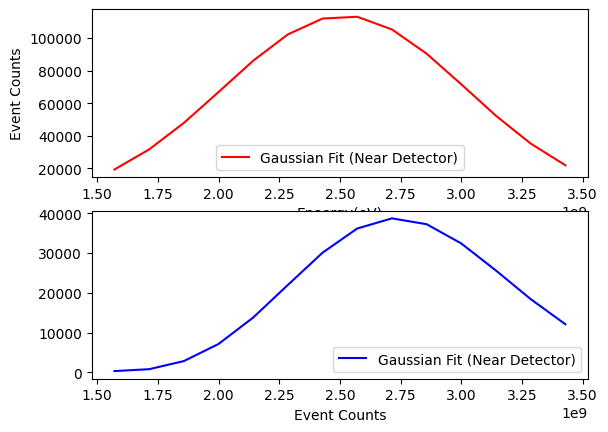

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from NuOscProbExact.src.oscprob3nu import probabilities_3nu
from NuOscProbExact.src.hamiltonians3nu import hamiltonian_3nu_vacuum_energy_independent, hamiltonian_3nu_matter
from NuOscProbExact.src.globaldefs import *

# Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Define a Gaussian energy distribution
mean_energy = 2.5e9  # Mean energy in eV (corresponds to 2.5 GeV)
sigma_energy = 0.5e9  # Standard deviation in eV
energies = np.random.normal(mean_energy, sigma_energy, 1000)

# Initialize the vacuum Hamiltonian (energy-independent part)
h_vacuum_energy_indep = hamiltonian_3nu_vacuum_energy_independent(
    S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
)

# Function to compute probabilities with matter effects for a given baseline
def compute_probabilities_matter(baseline, energy_values):
    Prob_mu = []

    for E in energy_values:
        # Define matter Hamiltonian for each energy
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)

        # Calculate muon neutrino survival probability (Pmm)
        _, _, _, _, Pmm, _, _, _, _ = probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_mu.append(Pmm)

    return np.array(Prob_mu)

# Total number of events for near and far detectors
total_events_near = 1000

# Generate Poisson-distributed event counts based on the probabilities at the near detector
Prob_mu_near = compute_probabilities_matter(Length_near, energies)
counts_mu_near = np.random.poisson(lam=Prob_mu_near * total_events_near)

# Define bin edges and centers for plotting
bin_edges = np.linspace(1.5e9, 3.5e9, 15)  # Fine energy bins
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# Compute histogram for near detector using the predefined bin edges
hist_near, _ = np.histogram(energies, bins=bin_edges, weights=counts_mu_near)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Fit near detector histogram with a Gaussian
popt_near, _ = curve_fit(gaussian, bin_centers, hist_near, p0=[np.max(hist_near), mean_energy, sigma_energy])

# Oscillate near detector Gaussian to compute far detector spectrum
oscillated_far = gaussian(bin_centers, *popt_near) * compute_probabilities_matter(Length_far, bin_centers)

plt.subplot(2, 1, 1)
plt.plot(bin_centers, gaussian(bin_centers, *popt_near), 'r-', label = 'Gaussian Fit (Near Detector)')
plt.xlabel('Energy')
plt.xlabel('Eneergy(eV)')
plt.ylabel('Event Counts')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(bin_centers, oscillated_far, 'b-', label = 'Gaussian Fit (Near Detector)')
plt.xlabel('Energy (eV)')
plt.xlabel('Event Counts')
plt.legend()



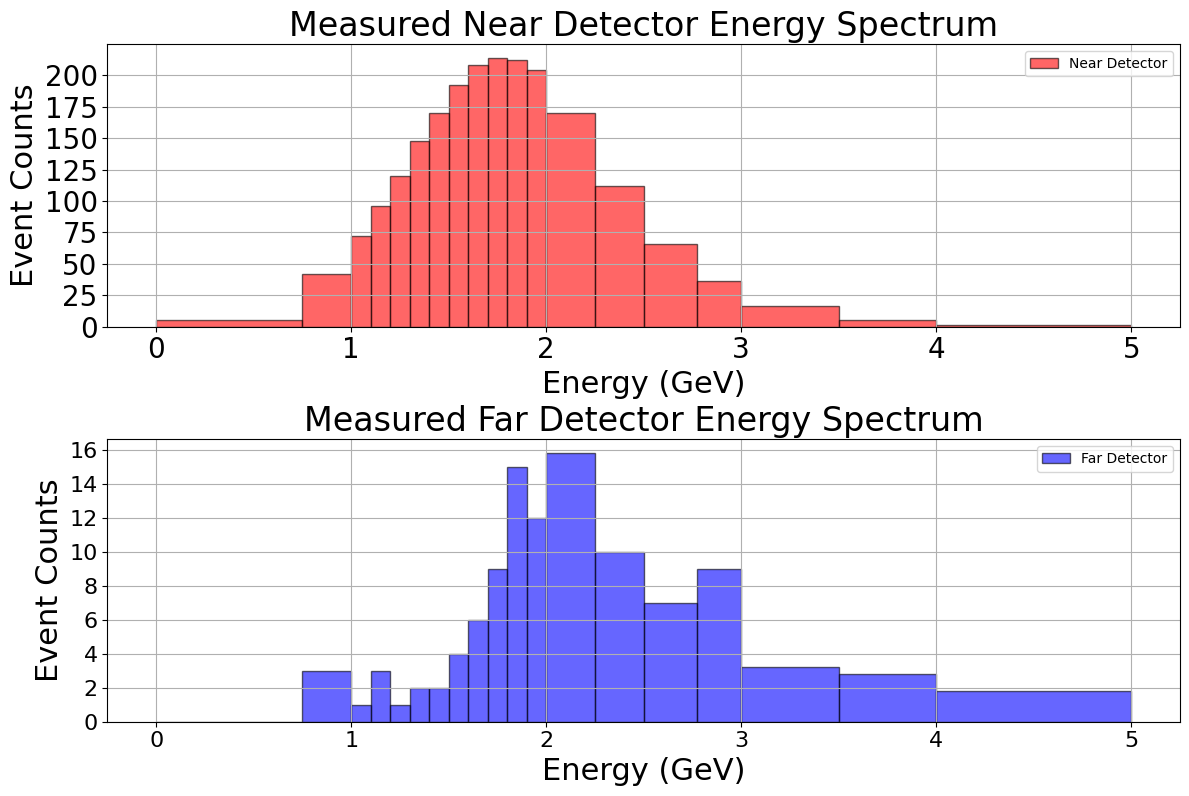

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from NuOscProbExact.src.oscprob3nu import probabilities_3nu
from NuOscProbExact.src.hamiltonians3nu import hamiltonian_3nu_vacuum_energy_independent, hamiltonian_3nu_matter
from NuOscProbExact.src.globaldefs import *

# Given Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9  # eV
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # eV
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

# Detector Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Initialize the vacuum Hamiltonian
h_vacuum_energy_indep = hamiltonian_3nu_vacuum_energy_independent(
    S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
)

# Function to compute oscillation probabilities for muon neutrinos
def compute_probabilities_matter(baseline, energy_values):
    Prob_mu = []
    for E in energy_values:
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt= probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_mu.append(Pmm)
    return np.array(Prob_mu)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Fit the near detector data with a Gaussian
popt_nd, _ = curve_fit(
    gaussian,
    bin_centers,
    counts_nd,
    p0=[np.max(counts_nd), 2.5e9, 0.5e9]
)

# Compute oscillation probabilities for the far detector
Prob_mu_far = compute_probabilities_matter(Length_far, bin_centers)

# Oscillated far detector spectrum (apply oscillation to fitted Gaussian)
oscillated_fd = gaussian(bin_centers, *popt_nd) * Prob_mu_far / np.max(Prob_mu_far)

plt.figure(figsize=(12, 8))


# Plotting Near Detector Histogram
plt.subplot(2,1,1)
plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, align='center', alpha=0.6,color = 'red', edgecolor='black',label='Near Detector')
plt.xlabel("Energy (GeV)", fontsize = 22)
plt.ylabel("Event Counts",fontsize = 22)
plt.title("Measured Near Detector Energy Spectrum", fontsize = 24)
plt.grid()
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend()



# Plotting Far Detector Histogram
plt.subplot(2, 1, 2)
plt.bar(bin_centers/ 1e9, counts_fd, width=np.diff(bin_edges)/ 1e9, align='center', alpha=0.6, label='Far Detector', color='blue', edgecolor = 'black')
plt.xlabel("Energy (GeV)", fontsize = 22)
plt.ylabel("Event Counts", fontsize = 22)
plt.title("Measured Far Detector Energy Spectrum", fontsize = 24)
plt.grid()
plt.legend()
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig("measured_count_spectra.png", dpi=300, bbox_inches='tight')
plt.show()



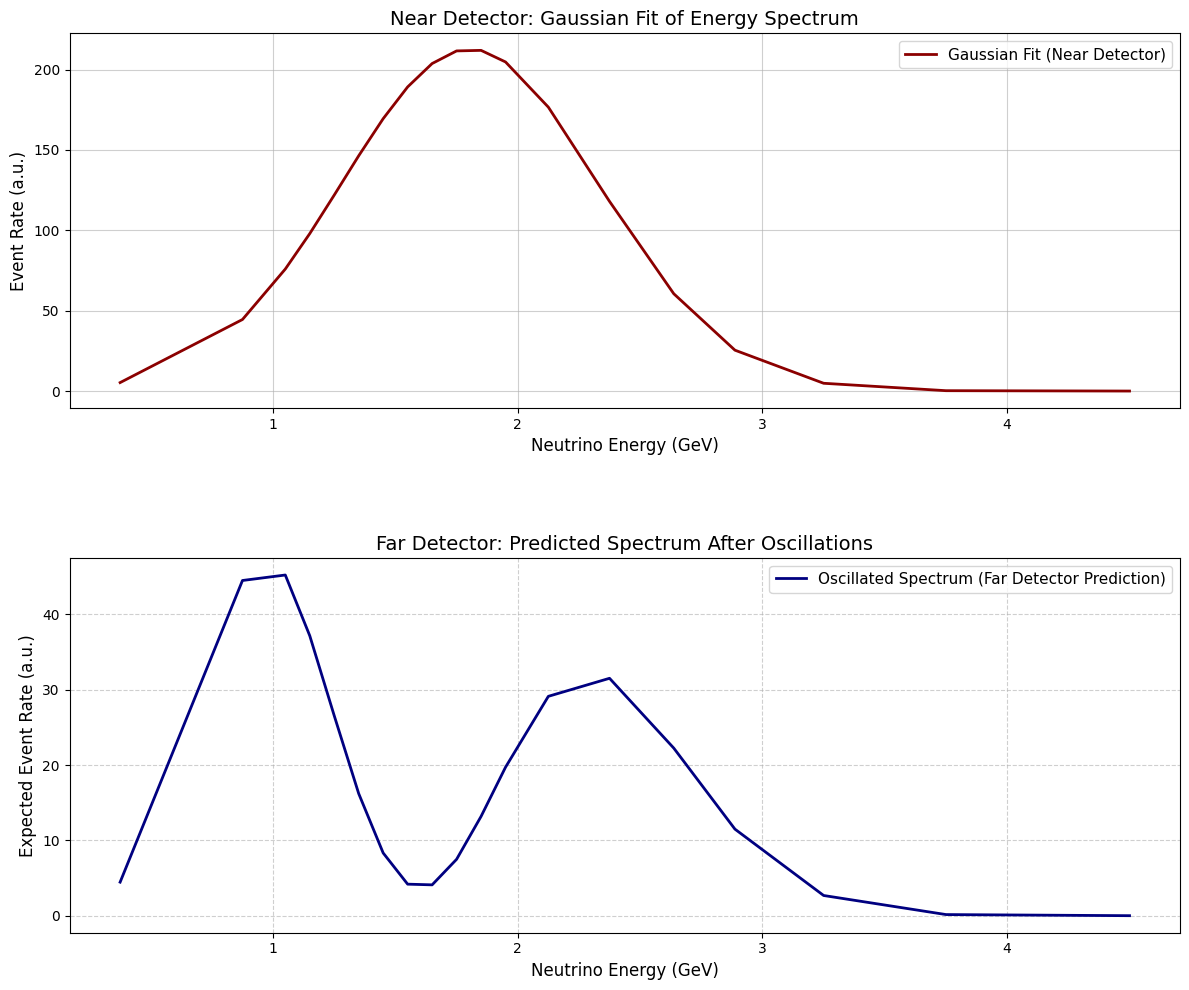

In [ ]:
plt.figure(figsize=(12,10))

plt.subplot(2,1,1)
plt.plot(
    bin_centers / 1e9,
    gaussian(bin_centers, *popt_nd),
    color='darkred',
    linestyle='-',
    linewidth=2,
    label='Gaussian Fit (Near Detector)'
)
plt.xlabel("Neutrino Energy (GeV)", fontsize=12)
plt.ylabel("Event Rate (a.u.)", fontsize=12)
plt.title("Near Detector: Gaussian Fit of Energy Spectrum", fontsize=14)
plt.grid(True, linestyle='-', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)

plt.subplot(2, 1, 2)
plt.plot(
    bin_centers / 1e9,
    oscillated_fd,
    color='navy',
    linestyle='-',
    linewidth=2,
    label='Oscillated Spectrum (Far Detector Prediction)'
)
plt.xlabel("Neutrino Energy (GeV)", fontsize=12)
plt.ylabel("Expected Event Rate (a.u.)", fontsize=12)
plt.title("Far Detector: Predicted Spectrum After Oscillations", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.savefig("gaussian_vs_oscillated_spectrum.png", dpi=300, bbox_inches='tight')
plt.show()

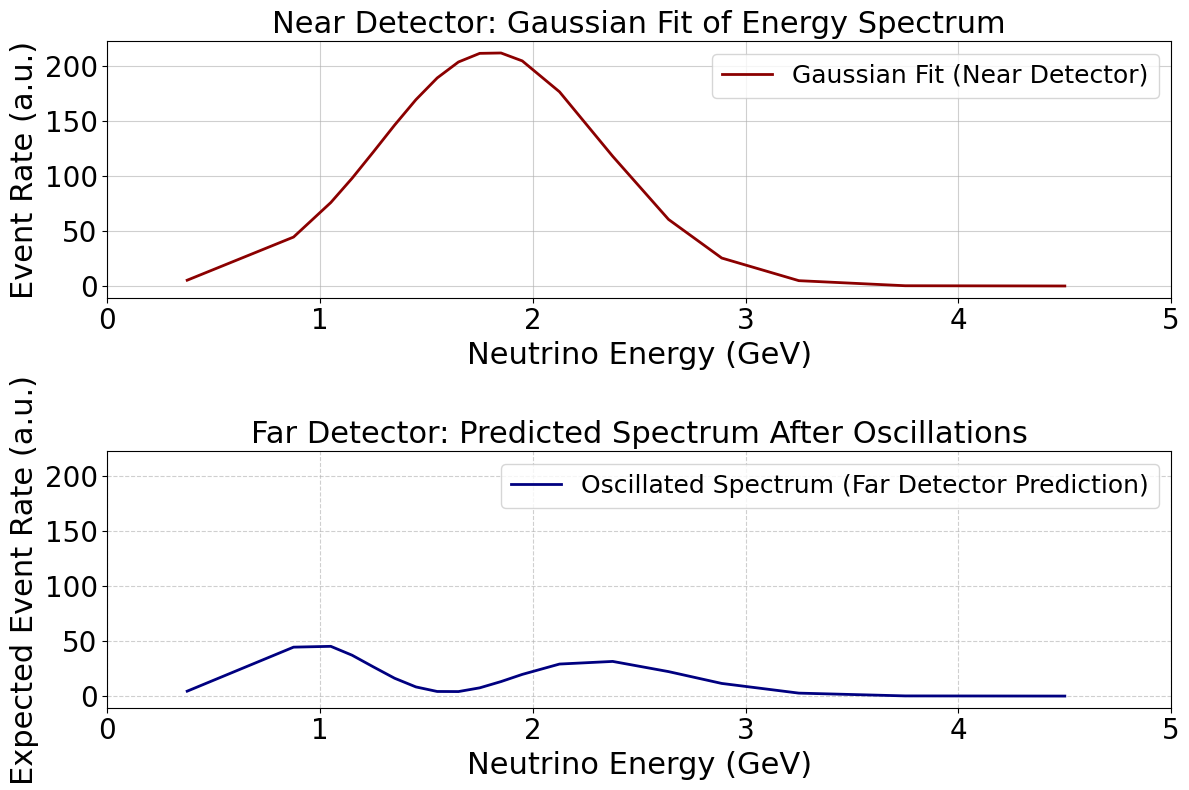

In [ ]:
plt.figure(figsize=(12, 8))

# --- First subplot: Gaussian Fit ---
plt.subplot(2, 1, 1)
plt.plot(
    bin_centers / 1e9,
    gaussian(bin_centers, *popt_nd),
    color='darkred',
    linestyle='-',
    linewidth=2,
    label='Gaussian Fit (Near Detector)'
)
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Event Rate (a.u.)", fontsize=22)
plt.title("Near Detector: Gaussian Fit of Energy Spectrum", fontsize=22)
plt.grid(True, linestyle='-', alpha=0.6)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(loc='upper right', fontsize=18)
plt.xlim(0, 5)

# Get y-axis limits from first plot
ymin, ymax = plt.gca().get_ylim()

# --- Second subplot: Oscillated Spectrum ---
plt.subplot(2, 1, 2)
plt.plot(
    bin_centers / 1e9,
    oscillated_fd,
    color='navy',
    linestyle='-',
    linewidth=2,
    label='Oscillated Spectrum (Far Detector Prediction)'
)
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Expected Event Rate (a.u.)", fontsize=22)
plt.title("Far Detector: Predicted Spectrum After Oscillations", fontsize=22)
plt.ylim(ymin, ymax)
plt.xlim(0, 5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(loc='upper right', fontsize=18)

plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.savefig("gaussian_vs_oscillated_spectrum.png", dpi=300, bbox_inches='tight')
plt.show()


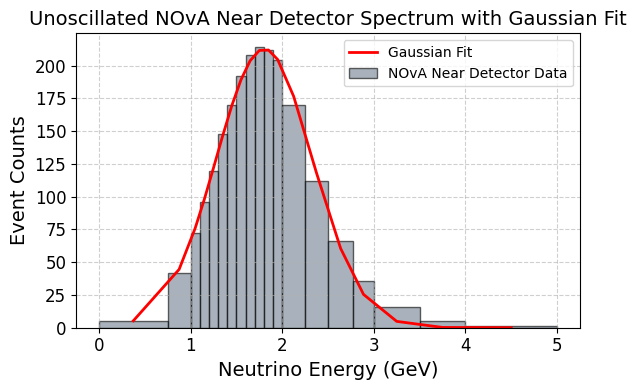

In [ ]:
plt.figure(figsize=(6, 4))

plt.bar(
    bin_centers / 1e9,
    counts_nd,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.6,
    label="NOvA Near Detector Data",
    color="slategray",
    edgecolor="black"
)

plt.plot(
    bin_centers / 1e9,
    gaussian(bin_centers, *popt_nd),
    'r-',
    linewidth=2,
    label="Gaussian Fit"
)

plt.xlabel("Neutrino Energy (GeV)", fontsize=14)
plt.ylabel("Event Counts", fontsize=14)
plt.title("Unoscillated NOvA Near Detector Spectrum with Gaussian Fit", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("nd_gaussian_fit_2.png", dpi=300, bbox_inches='tight')
plt.show()

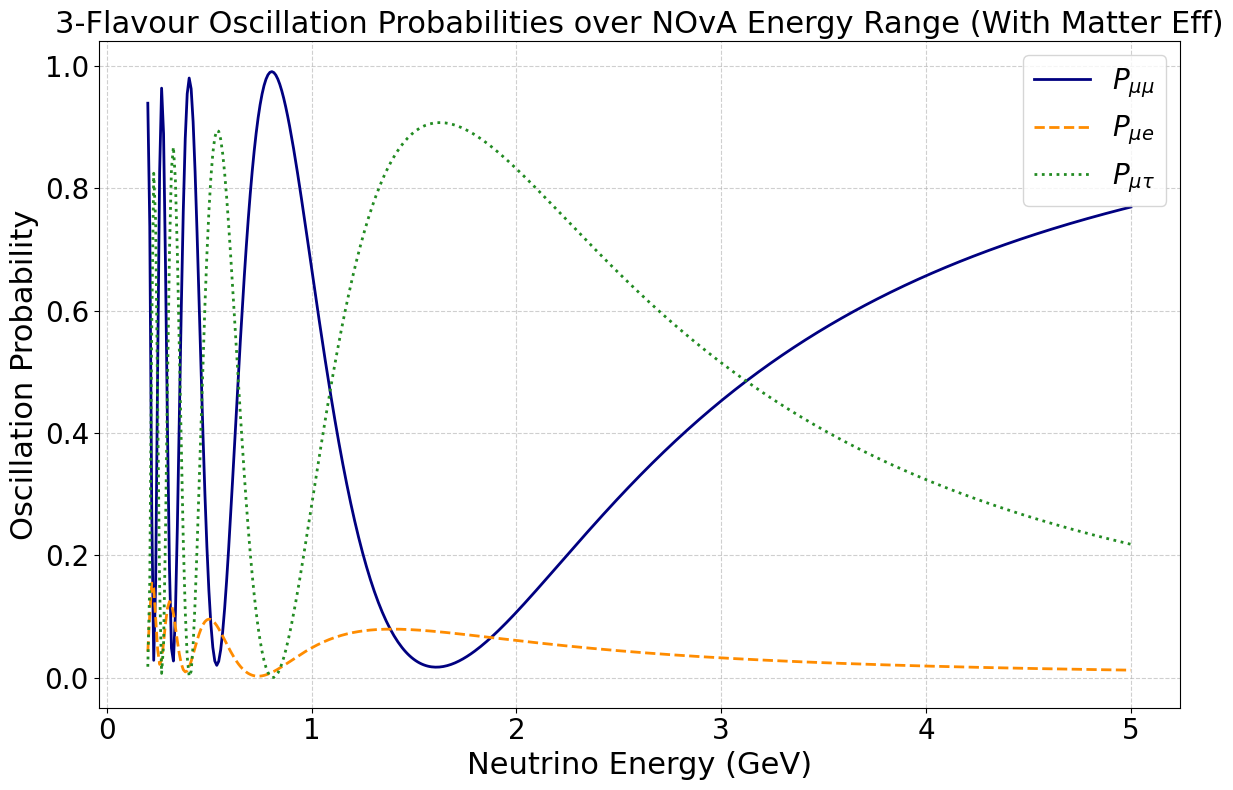

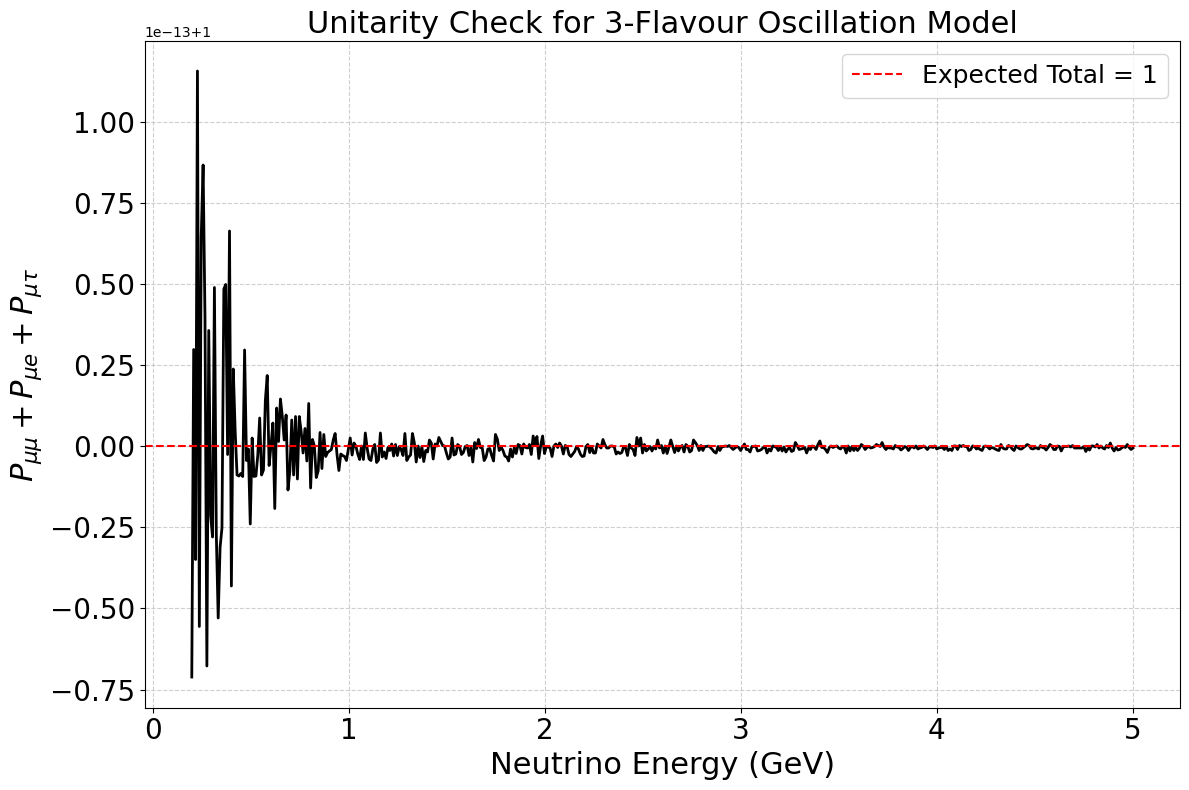

In [ ]:
# Define energy range
energy_range = np.linspace(0.2e9, 5e9, 500)  # in eV

# Initialize arrays
prob_mm = []
prob_me = []
prob_mt = []
prob_sum = []

# Loop through energy values
for E in energy_range:
    h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
    Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(h_matter, Length_far * CONV_KM_TO_INV_EV)

    # Store individual probabilities
    prob_mm.append(Pmm)
    prob_me.append(Pme)
    prob_mt.append(Pmt)

    # Unitarity check (should be ~1)
    prob_sum.append(Pmm + Pme + Pmt)

# Convert to arrays
prob_mm = np.array(prob_mm)
prob_me = np.array(prob_me)
prob_mt = np.array(prob_mt)
prob_sum = np.array(prob_sum)

# Plot all three oscillation channels
plt.figure(figsize=(12, 8))

plt.plot(energy_range / 1e9, prob_mm, label=r"$P_{\mu\mu}$", color='navy', linewidth=2)
plt.plot(energy_range / 1e9, prob_me, label=r"$P_{\mu e}$", color='darkorange', linestyle='--', linewidth=2)
plt.plot(energy_range / 1e9, prob_mt, label=r"$P_{\mu\tau}$", color='forestgreen', linestyle=':', linewidth=2)

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Oscillation Probability", fontsize=22)
plt.title("3-Flavour Oscillation Probabilities over NOvA Energy Range (With Matter Eff)", fontsize=22)
plt.legend(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig("oscillation_validation_3flavour_allchannels.png", dpi=300, bbox_inches='tight')
plt.show()

# Unitarity Check Plot
plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, prob_sum, color='black', linewidth=2)
plt.axhline(1.0, color='red', linestyle='--', label="Expected Total = 1")
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel(r"$P_{\mu\mu} + P_{\mu e} + P_{\mu\tau}$", fontsize=22)
plt.title("Unitarity Check for 3-Flavour Oscillation Model", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("unitarity_check.png", dpi=300, bbox_inches='tight')
plt.show()


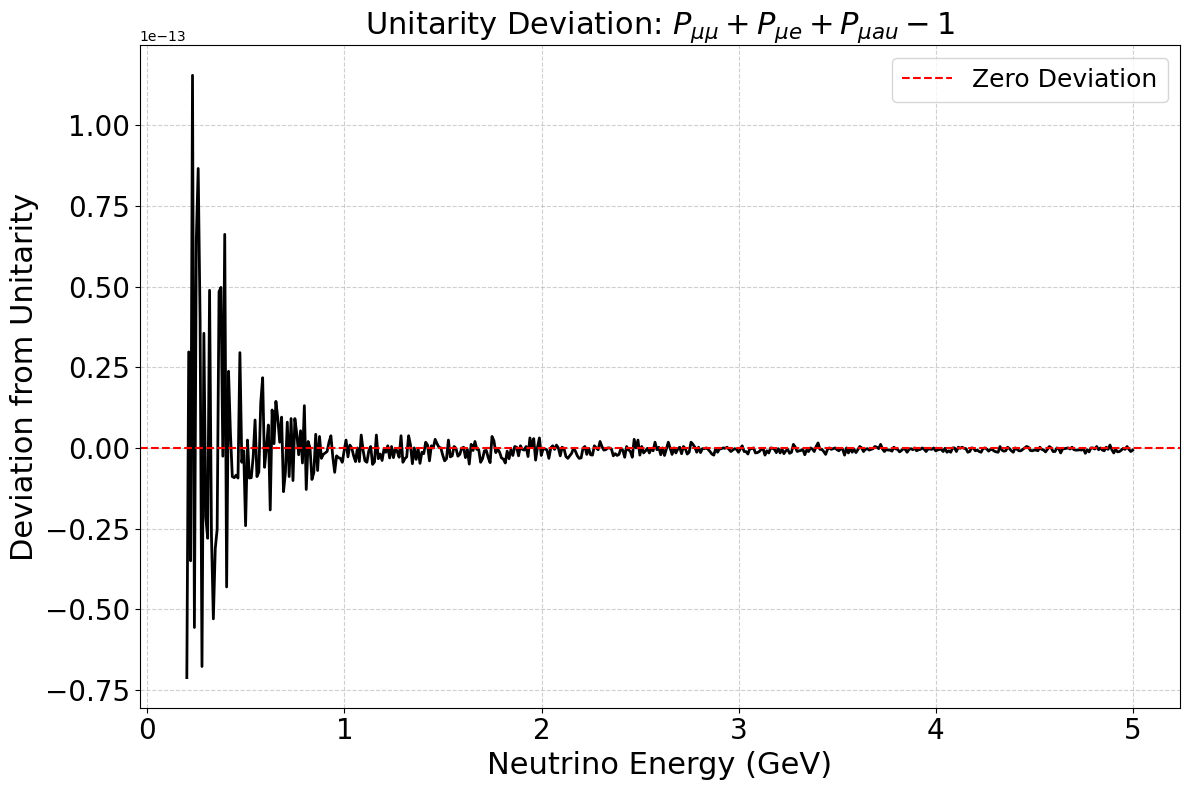

In [ ]:
# Deviation from unitarity
deviation = prob_sum - 1

plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, deviation, color='black', linewidth=2)
plt.axhline(0, color='red', linestyle='--', label="Zero Deviation")
plt.xlabel("Neutrino Energy (GeV)",fontsize=22)
plt.ylabel(r"Deviation from Unitarity", fontsize=22)
plt.title("Unitarity Deviation: $P_{\mu\mu} + P_{\mu e} + P_{\mu\tau} - 1$", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("unitarity_deviation.png", dpi=300, bbox_inches='tight')
plt.show()


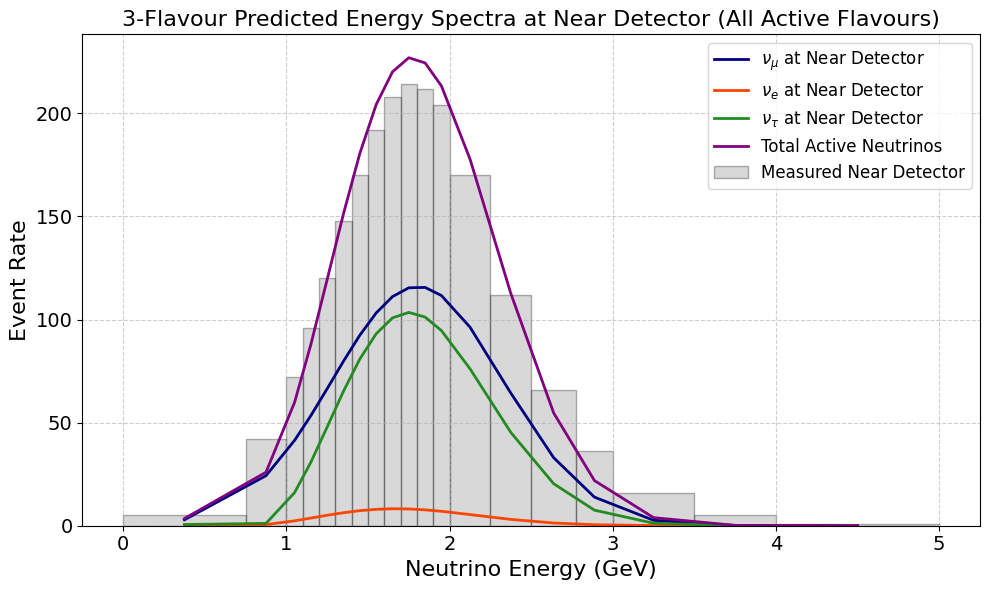

In [ ]:
# Compute oscillation probabilities at the Near Detector ---
prob_mm_near = compute_probabilities_matter(Length_near, energy_range)

# Interpolate probabilities to bin_centers
interp_mm_near = interp1d(energy_range, prob_mm_near, kind='linear')
interp_me_near = interp1d(energy_range, prob_me, kind='linear')  # You can reuse prob_me and prob_mt for a rough estimate
interp_mt_near = interp1d(energy_range, prob_mt, kind='linear')

prob_mm_bins_near = interp_mm_near(bin_centers)
prob_me_bins_near = interp_me_near(bin_centers)
prob_mt_bins_near = interp_mt_near(bin_centers)

# Gaussian flux from ND fit
gaussian_flux_nd = gaussian(bin_centers, *popt_nd)

# Predicted energy spectra at Near Detector
spectrum_mu_nd = gaussian_flux_nd * prob_mm_bins_near
spectrum_e_nd  = gaussian_flux_nd * prob_me_bins_near
spectrum_tau_nd = gaussian_flux_nd * prob_mt_bins_near
spectrum_all_nd = spectrum_mu_nd + spectrum_e_nd + spectrum_tau_nd

# Scaling to match total ND counts
scaling_factor_nd = np.sum(counts_nd) / np.sum(spectrum_all_nd)
spectrum_mu_nd_scaled = spectrum_mu_nd * scaling_factor_nd
spectrum_e_nd_scaled  = spectrum_e_nd * scaling_factor_nd
spectrum_tau_nd_scaled = spectrum_tau_nd * scaling_factor_nd
spectrum_all_nd_scaled = spectrum_mu_nd_scaled + spectrum_e_nd_scaled + spectrum_tau_nd_scaled

# Plot
plt.figure(figsize=(10, 6))
plt.plot(bin_centers / 1e9, spectrum_mu_nd_scaled, color='navy', label=r"$\nu_\mu$ at Near Detector", linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_e_nd_scaled, color='orangered', label=r"$\nu_e$ at Near Detector", linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_tau_nd_scaled, color='forestgreen', label=r"$\nu_\tau$ at Near Detector", linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_all_nd_scaled, color='purple', linestyle='-', linewidth=2, label='Total Active Neutrinos')

plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, alpha=0.3, label='Measured Near Detector', color='gray', edgecolor='black')

plt.xlabel("Neutrino Energy (GeV)", fontsize=16)
plt.ylabel("Event Rate", fontsize=16)
plt.title("3-Flavour Predicted Energy Spectra at Near Detector (All Active Flavours)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("3flavour_active_energy_spectra_near_detector.png", dpi=300, bbox_inches='tight')
plt.show()


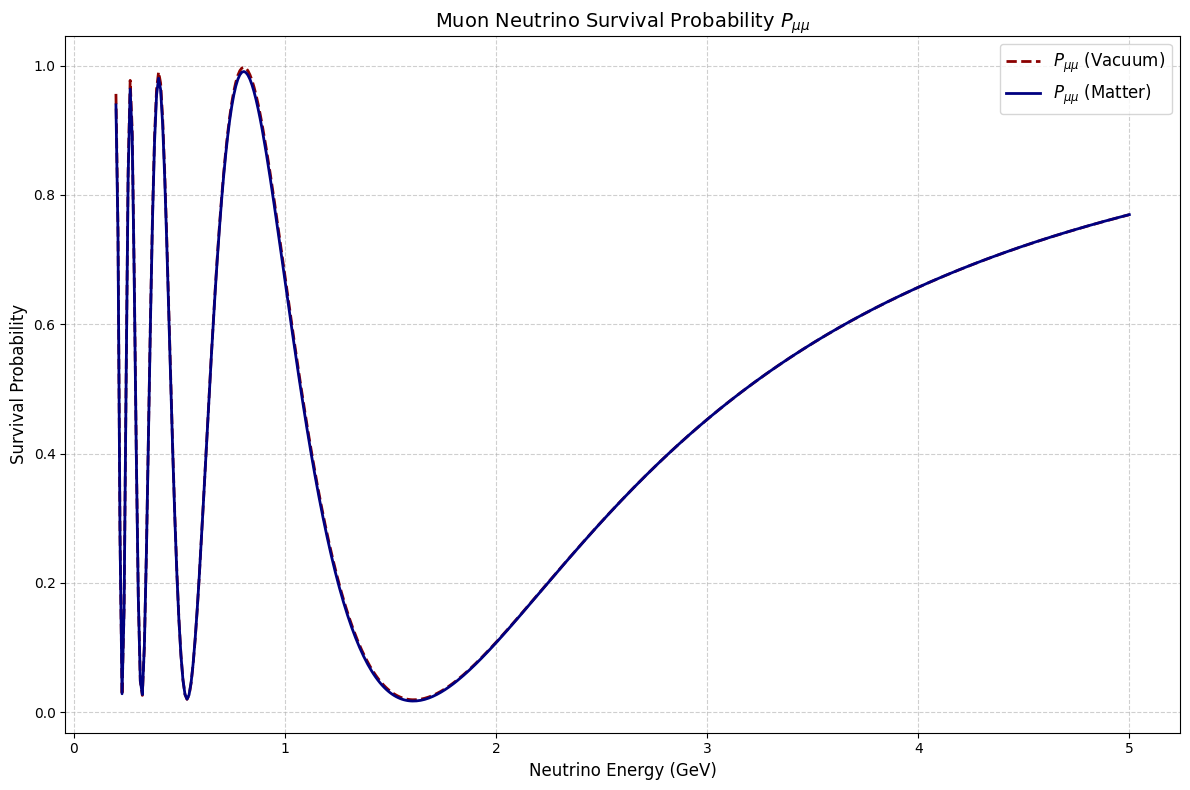

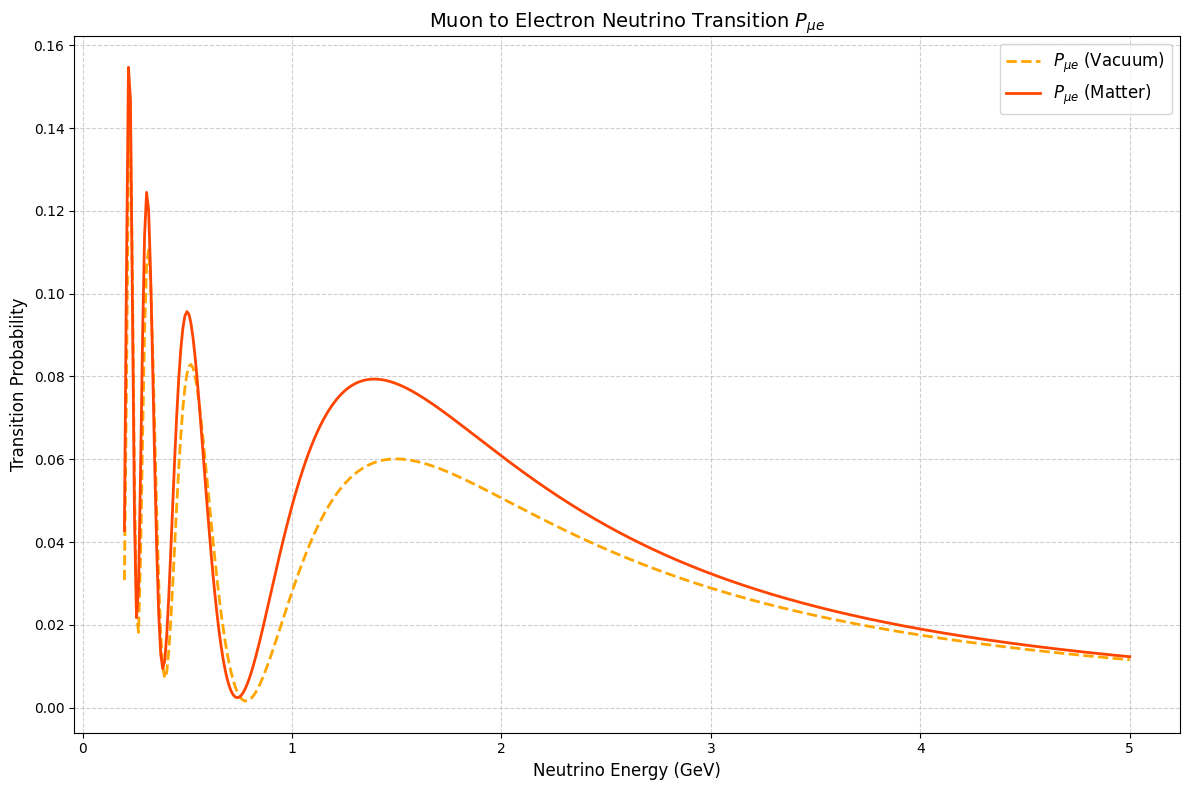

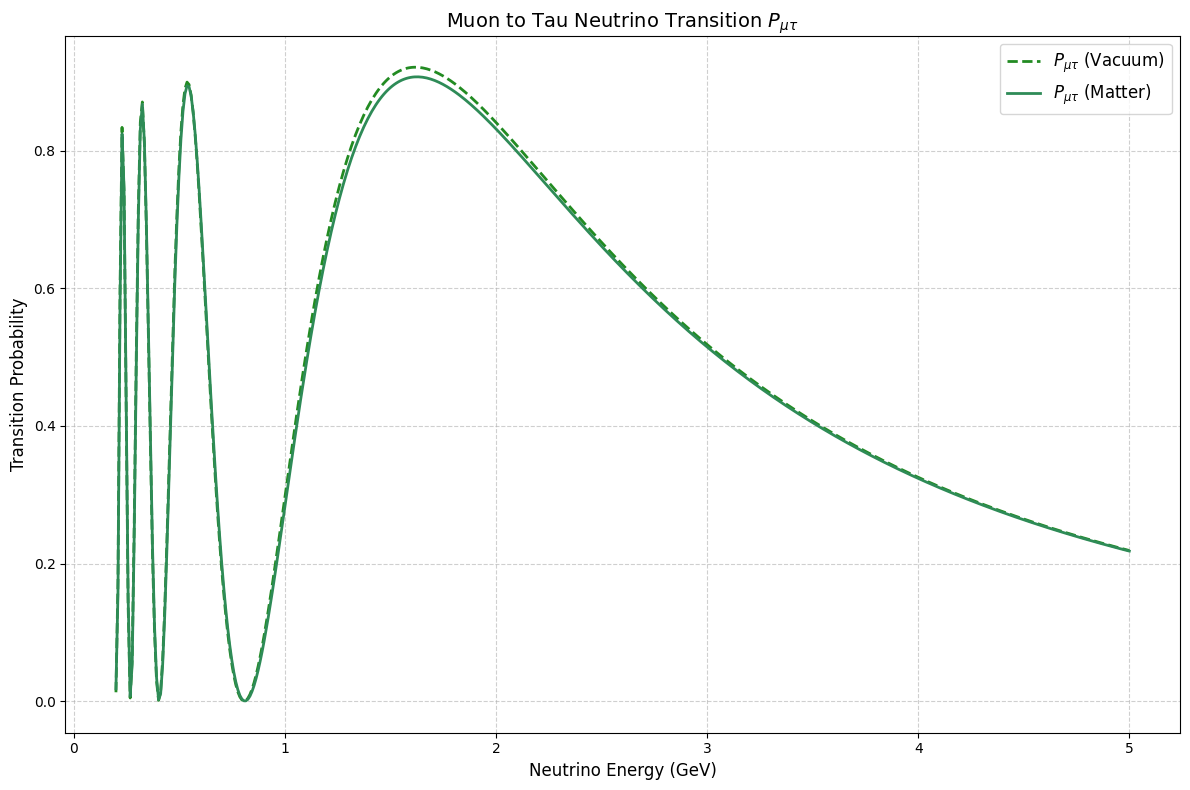

In [ ]:
# Initialize arrays
prob_mm_vac = []
prob_mm_mat = []

prob_me_vac = []
prob_me_mat = []

prob_mt_vac = []
prob_mt_mat = []

# Calculate probabilities for both vacuum and matter
for E in energy_range:
    h_vac = h_vacuum_energy_indep / E
    _, _, _, Pme_v, Pmm_v, Pmt_v, _, _, _ = probabilities_3nu(h_vac, Length_far * CONV_KM_TO_INV_EV)

    prob_mm_vac.append(Pmm_v)
    prob_me_vac.append(Pme_v)
    prob_mt_vac.append(Pmt_v)

    h_mat = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
    _, _, _, Pme_m, Pmm_m, Pmt_m, _, _, _ = probabilities_3nu(h_mat, Length_far * CONV_KM_TO_INV_EV)

    prob_mm_mat.append(Pmm_m)
    prob_me_mat.append(Pme_m)
    prob_mt_mat.append(Pmt_m)

# Convert to arrays
prob_mm_vac = np.array(prob_mm_vac)
prob_mm_mat = np.array(prob_mm_mat)
prob_me_vac = np.array(prob_me_vac)
prob_me_mat = np.array(prob_me_mat)
prob_mt_vac = np.array(prob_mt_vac)
prob_mt_mat = np.array(prob_mt_mat)

# Figure 1: Muon Neutrino Survival
plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, prob_mm_vac, '--', color='darkred', linewidth=2, label=r"$P_{\mu\mu}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mm_mat, '-', color='navy', linewidth=2, label=r"$P_{\mu\mu}$ (Matter)")
plt.xlabel("Neutrino Energy (GeV)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.title(r"Muon Neutrino Survival Probability $P_{\mu\mu}$", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("pmm_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Muon to Electron Neutrino Transition
plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, prob_me_vac, '--', color='orange', linewidth=2, label=r"$P_{\mu e}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_me_mat, '-', color='orangered', linewidth=2, label=r"$P_{\mu e}$ (Matter)")
plt.xlabel("Neutrino Energy (GeV)", fontsize=12)
plt.ylabel("Transition Probability", fontsize=12)
plt.title(r"Muon to Electron Neutrino Transition $P_{\mu e}$", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("pme_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Muon to Tau Neutrino Transition
plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, prob_mt_vac, '--', color='forestgreen', linewidth=2, label=r"$P_{\mu\tau}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mt_mat, '-', color='seagreen', linewidth=2, label=r"$P_{\mu\tau}$ (Matter)")
plt.xlabel("Neutrino Energy (GeV)", fontsize=12)
plt.ylabel("Transition Probability", fontsize=12)
plt.title(r"Muon to Tau Neutrino Transition $P_{\mu\tau}$", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("pmt_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()



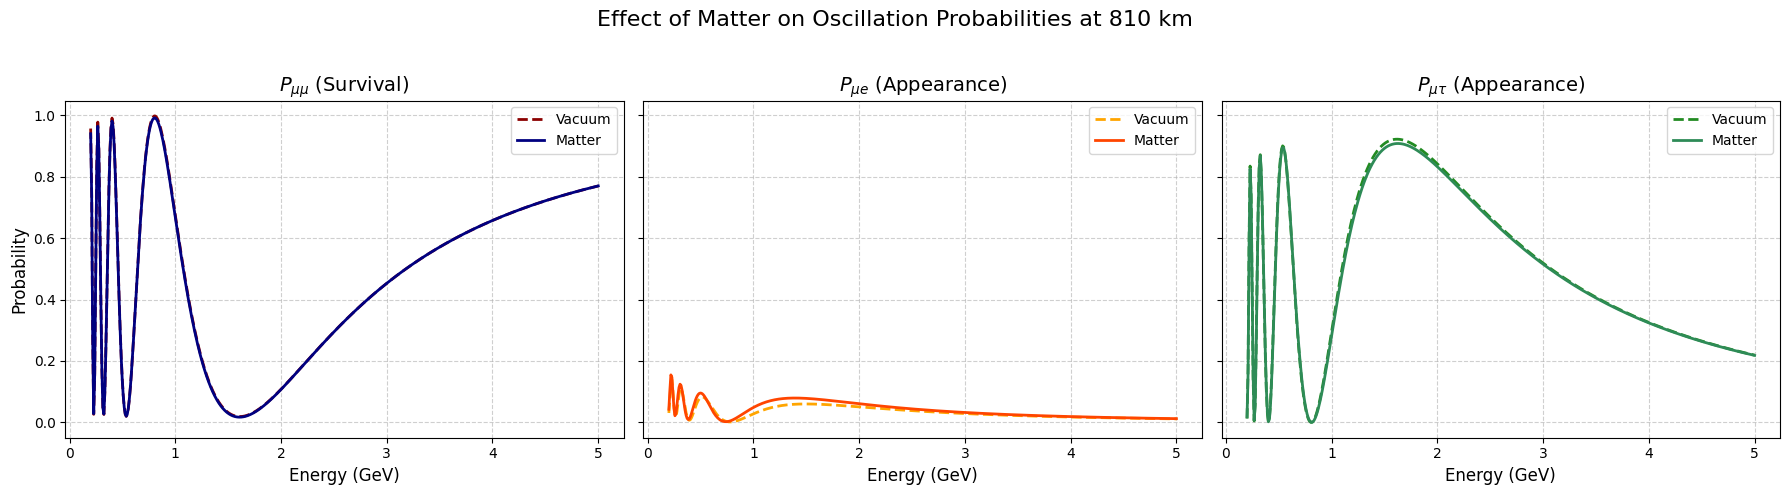

In [ ]:
# Create figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Plot Pμμ
axes[0].plot(energy_range / 1e9, prob_mm_vac, '--', color='darkred', linewidth=2, label=r"Vacuum")
axes[0].plot(energy_range / 1e9, prob_mm_mat, '-', color='navy', linewidth=2, label=r"Matter")
axes[0].set_title(r"$P_{\mu\mu}$ (Survival)", fontsize=14)
axes[0].set_xlabel("Energy (GeV)", fontsize=12)
axes[0].set_ylabel("Probability", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=10)

# Plot Pμe
axes[1].plot(energy_range / 1e9, prob_me_vac, '--', color='orange', linewidth=2, label=r"Vacuum")
axes[1].plot(energy_range / 1e9, prob_me_mat, '-', color='orangered', linewidth=2, label=r"Matter")
axes[1].set_title(r"$P_{\mu e}$ (Appearance)", fontsize=14)
axes[1].set_xlabel("Energy (GeV)", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=10)

# Plot Pμτ
axes[2].plot(energy_range / 1e9, prob_mt_vac, '--', color='forestgreen', linewidth=2, label=r"Vacuum")
axes[2].plot(energy_range / 1e9, prob_mt_mat, '-', color='seagreen', linewidth=2, label=r"Matter")
axes[2].set_title(r"$P_{\mu\tau}$ (Appearance)", fontsize=14)
axes[2].set_xlabel("Energy (GeV)", fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(fontsize=10)

# Layout settings
plt.suptitle("Effect of Matter on Oscillation Probabilities at 810 km", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("oscillation_matter_vs_vacuum_subplots.png", dpi=300, bbox_inches='tight')
plt.show()


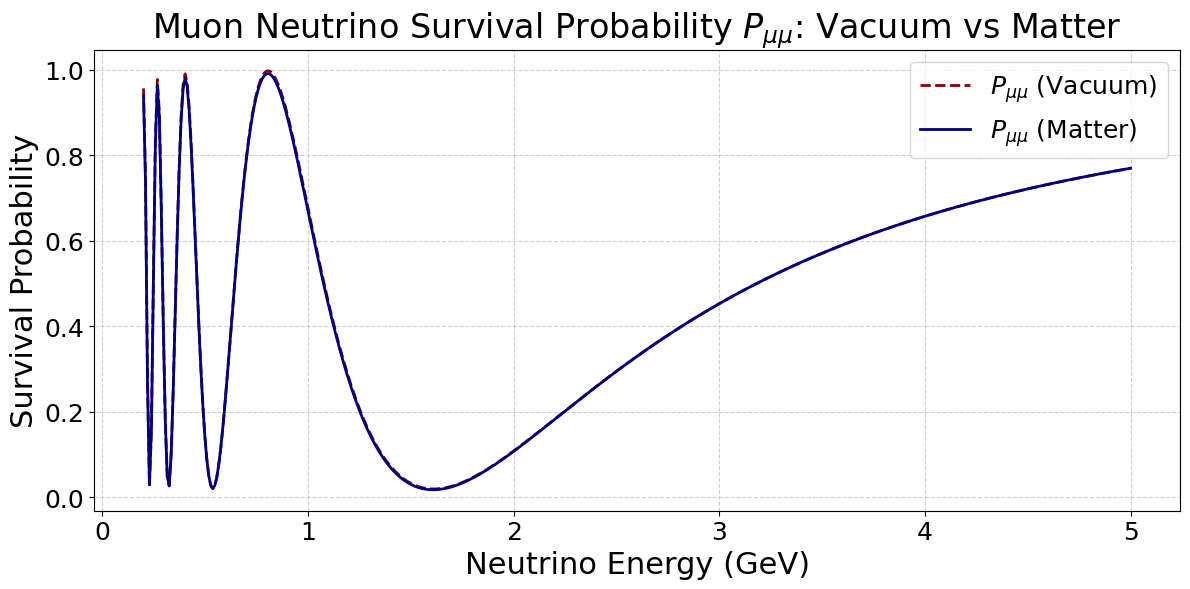

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(energy_range / 1e9, prob_mm_vac, '--', color='darkred', linewidth=2, label=r"$P_{\mu\mu}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mm_mat, '-', color='navy', linewidth=2, label=r"$P_{\mu\mu}$ (Matter)")

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Survival Probability", fontsize=22)
plt.title(r"Muon Neutrino Survival Probability $P_{\mu\mu}$: Vacuum vs Matter", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("pmm_survival_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()



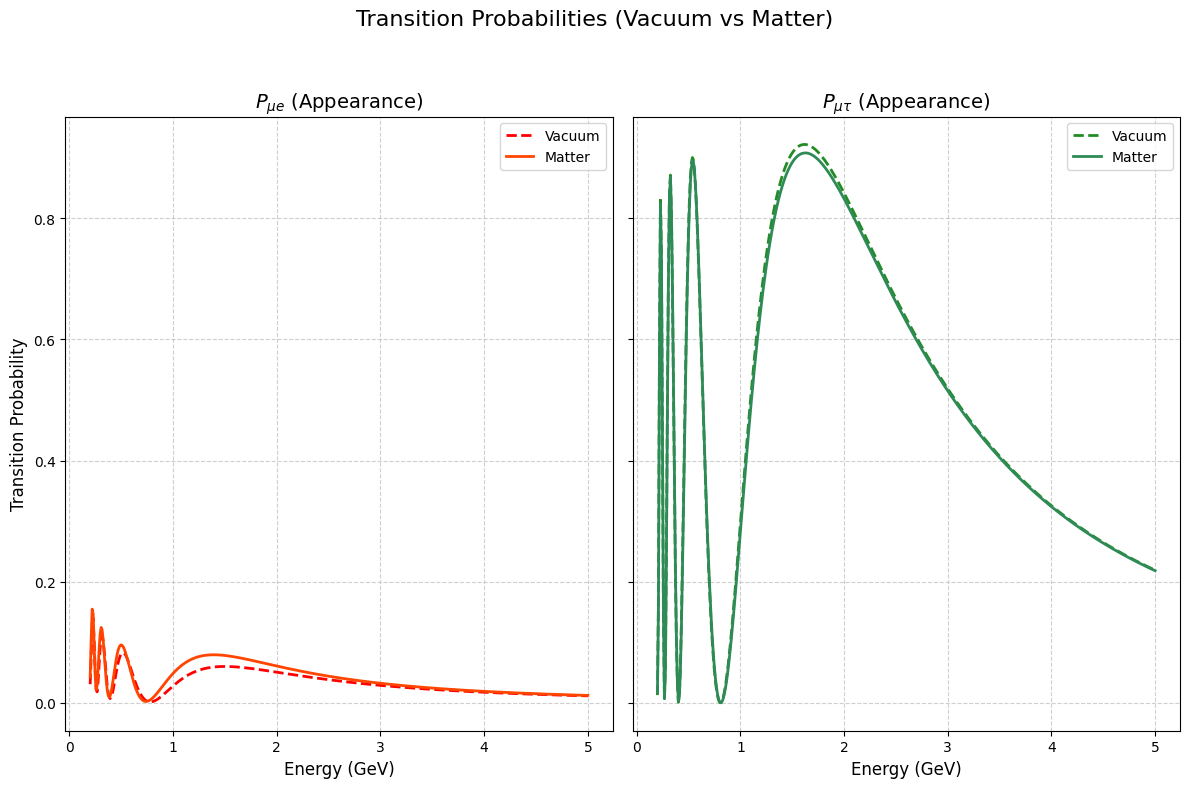

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex=True, sharey=True)

# Pμe
axes[0].plot(energy_range / 1e9, prob_me_vac, '--', color='red', linewidth=2, label="Vacuum")
axes[0].plot(energy_range / 1e9, prob_me_mat, '-', color='orangered', linewidth=2, label="Matter")
axes[0].set_title(r"$P_{\mu e}$ (Appearance)", fontsize=14)
axes[0].set_xlabel("Energy (GeV)", fontsize=12)
axes[0].set_ylabel("Transition Probability", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=10)

# Pμτ
axes[1].plot(energy_range / 1e9, prob_mt_vac, '--', color='forestgreen', linewidth=2, label="Vacuum")
axes[1].plot(energy_range / 1e9, prob_mt_mat, '-', color='seagreen', linewidth=2, label="Matter")
axes[1].set_title(r"$P_{\mu\tau}$ (Appearance)", fontsize=14)
axes[1].set_xlabel("Energy (GeV)", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=10)

plt.suptitle("Transition Probabilities (Vacuum vs Matter)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("transition_probabilities_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
from google.colab import files
files.download("transition_probabilities_vacuum_vs_matter.png")

In [ ]:
from google.colab import files
files.download("pmm_survival_vacuum_vs_matter.png")
files.download("transition_probabilities_vacuum_vs_matter.png")

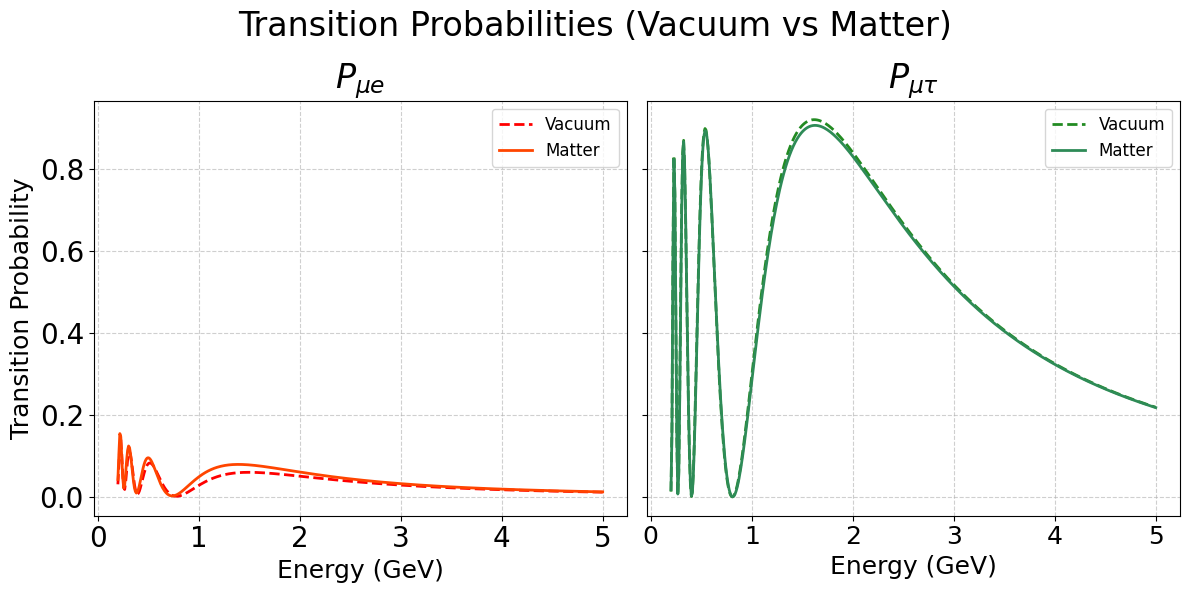

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# Pμe
axes[0].plot(energy_range / 1e9, prob_me_vac, '--', color='red', linewidth=2, label="Vacuum")
axes[0].plot(energy_range / 1e9, prob_me_mat, '-', color='orangered', linewidth=2, label="Matter")
axes[0].set_title(r"$P_{\mu e}$", fontsize=24)
axes[0].set_xlabel("Energy (GeV)", fontsize=18)
axes[0].set_ylabel("Transition Probability", fontsize=18)
axes[0].tick_params(axis='both', labelsize=20)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=12)

# Pμτ
axes[1].plot(energy_range / 1e9, prob_mt_vac, '--', color='forestgreen', linewidth=2, label="Vacuum")
axes[1].plot(energy_range / 1e9, prob_mt_mat, '-', color='seagreen', linewidth=2, label="Matter")
axes[1].set_title(r"$P_{\mu\tau}$", fontsize=24)
axes[1].set_xlabel("Energy (GeV)", fontsize=18)
axes[1].tick_params(axis='both', labelsize=18)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=12)

plt.suptitle("Transition Probabilities (Vacuum vs Matter)", fontsize=24)
plt.tight_layout()
plt.savefig("transition_probabilities_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()



Near Detector three flavour oscillation probability plot.

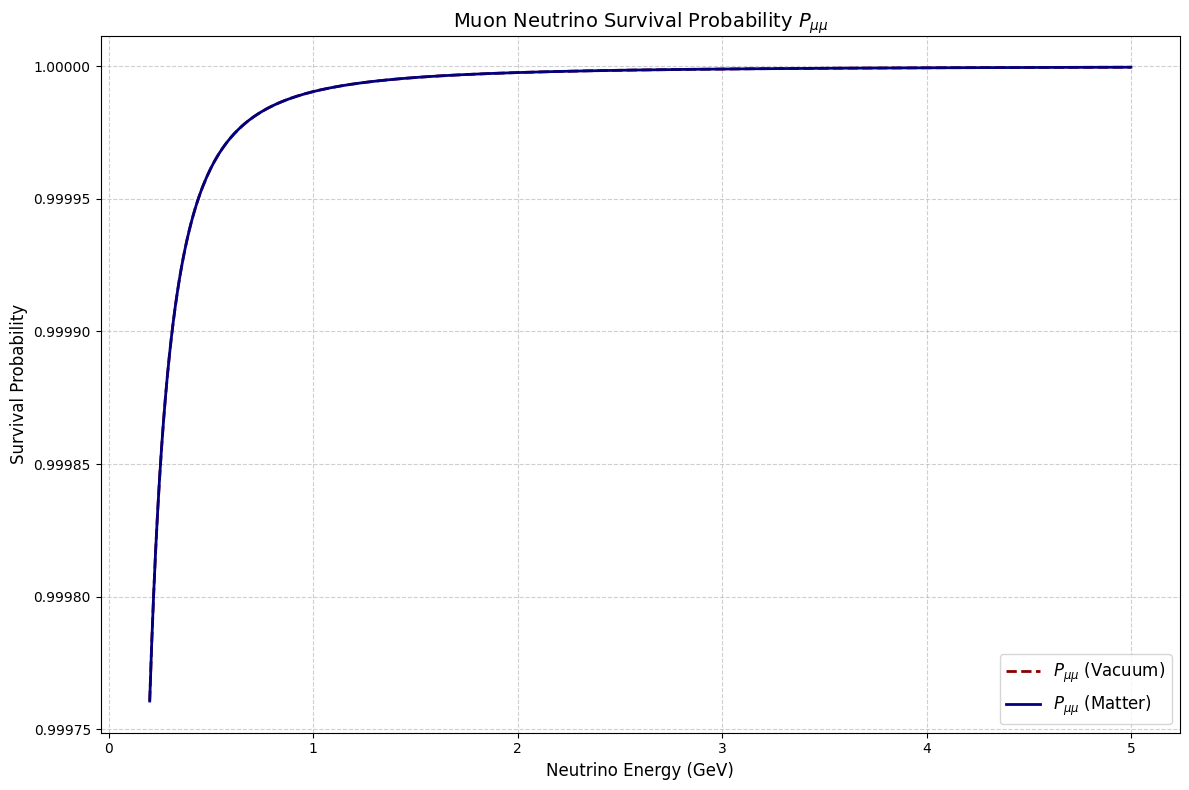

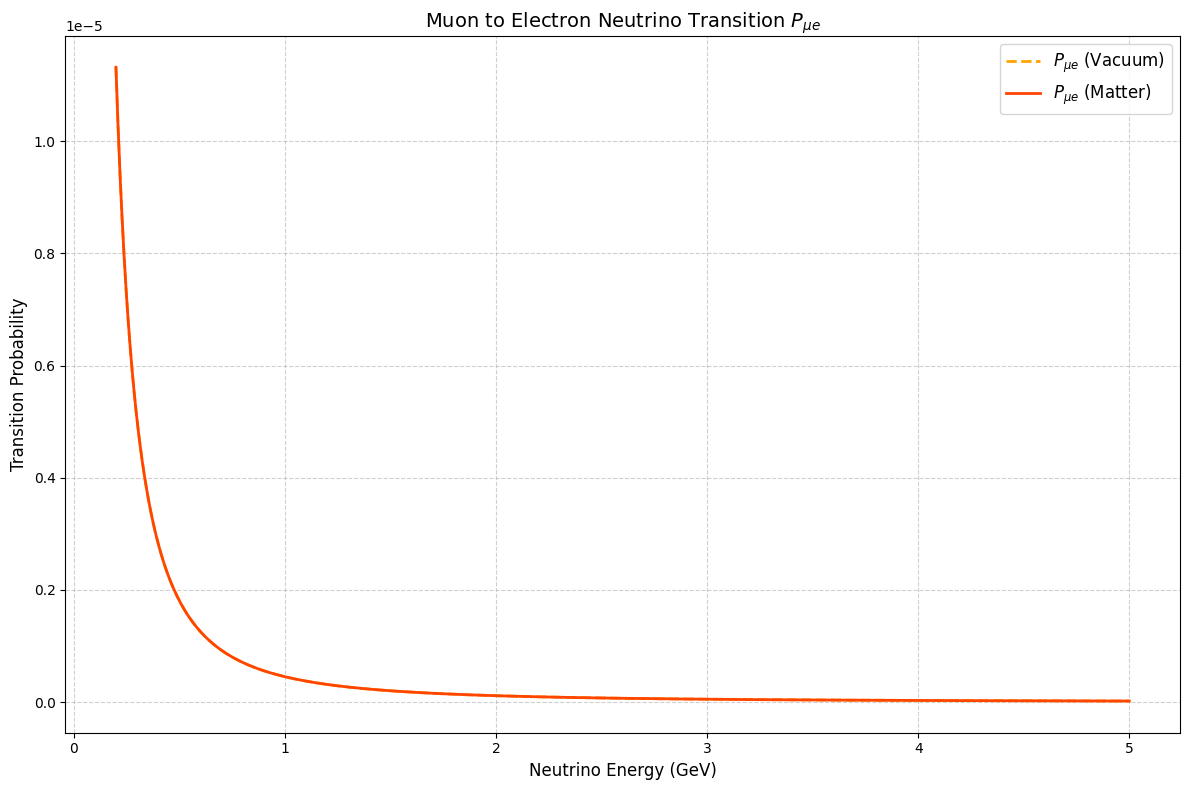

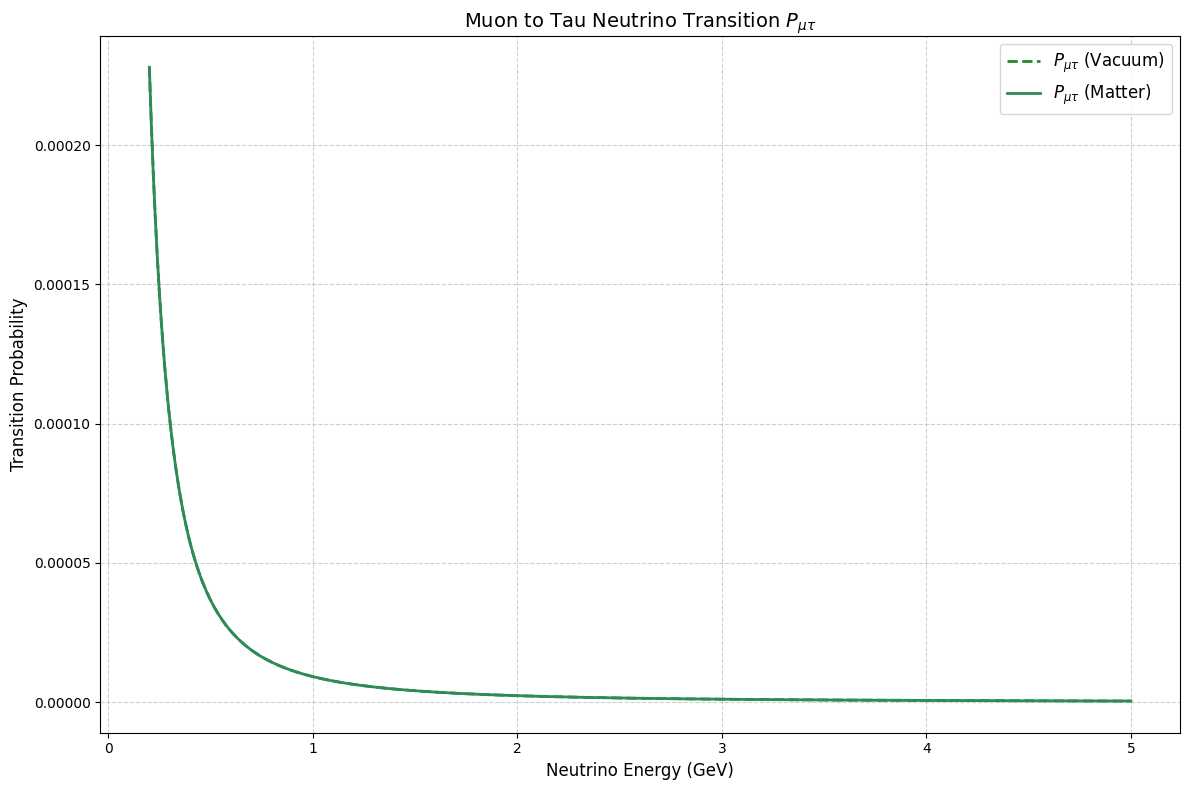

In [ ]:
# Initialize arrays
prob_mm_vac = []
prob_mm_mat = []

prob_me_vac = []
prob_me_mat = []

prob_mt_vac = []
prob_mt_mat = []

# Calculate probabilities for both vacuum and matter
for E in energy_range:
    h_vac = h_vacuum_energy_indep / E
    _, _, _, Pme_v, Pmm_v, Pmt_v, _, _, _ = probabilities_3nu(h_vac, Length_near* CONV_KM_TO_INV_EV)

    prob_mm_vac.append(Pmm_v)
    prob_me_vac.append(Pme_v)
    prob_mt_vac.append(Pmt_v)

    h_mat = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
    _, _, _, Pme_m, Pmm_m, Pmt_m, _, _, _ = probabilities_3nu(h_mat, Length_near * CONV_KM_TO_INV_EV)

    prob_mm_mat.append(Pmm_m)
    prob_me_mat.append(Pme_m)
    prob_mt_mat.append(Pmt_m)

# Convert to arrays
prob_mm_vac = np.array(prob_mm_vac)
prob_mm_mat = np.array(prob_mm_mat)
prob_me_vac = np.array(prob_me_vac)
prob_me_mat = np.array(prob_me_mat)
prob_mt_vac = np.array(prob_mt_vac)
prob_mt_mat = np.array(prob_mt_mat)

# Figure 1: Muon Neutrino Survival
plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, prob_mm_vac, '--', color='darkred', linewidth=2, label=r"$P_{\mu\mu}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mm_mat, '-', color='navy', linewidth=2, label=r"$P_{\mu\mu}$ (Matter)")
plt.xlabel("Neutrino Energy (GeV)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.title(r"Muon Neutrino Survival Probability $P_{\mu\mu}$", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("pmm_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Muon to Electron Neutrino Transition
plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, prob_me_vac, '--', color='orange', linewidth=2, label=r"$P_{\mu e}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_me_mat, '-', color='orangered', linewidth=2, label=r"$P_{\mu e}$ (Matter)")
plt.xlabel("Neutrino Energy (GeV)", fontsize=12)
plt.ylabel("Transition Probability", fontsize=12)
plt.title(r"Muon to Electron Neutrino Transition $P_{\mu e}$", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("pme_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Muon to Tau Neutrino Transition
plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, prob_mt_vac, '--', color='forestgreen', linewidth=2, label=r"$P_{\mu\tau}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mt_mat, '-', color='seagreen', linewidth=2, label=r"$P_{\mu\tau}$ (Matter)")
plt.xlabel("Neutrino Energy (GeV)", fontsize=12)
plt.ylabel("Transition Probability", fontsize=12)
plt.title(r"Muon to Tau Neutrino Transition $P_{\mu\tau}$", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("pmt_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()





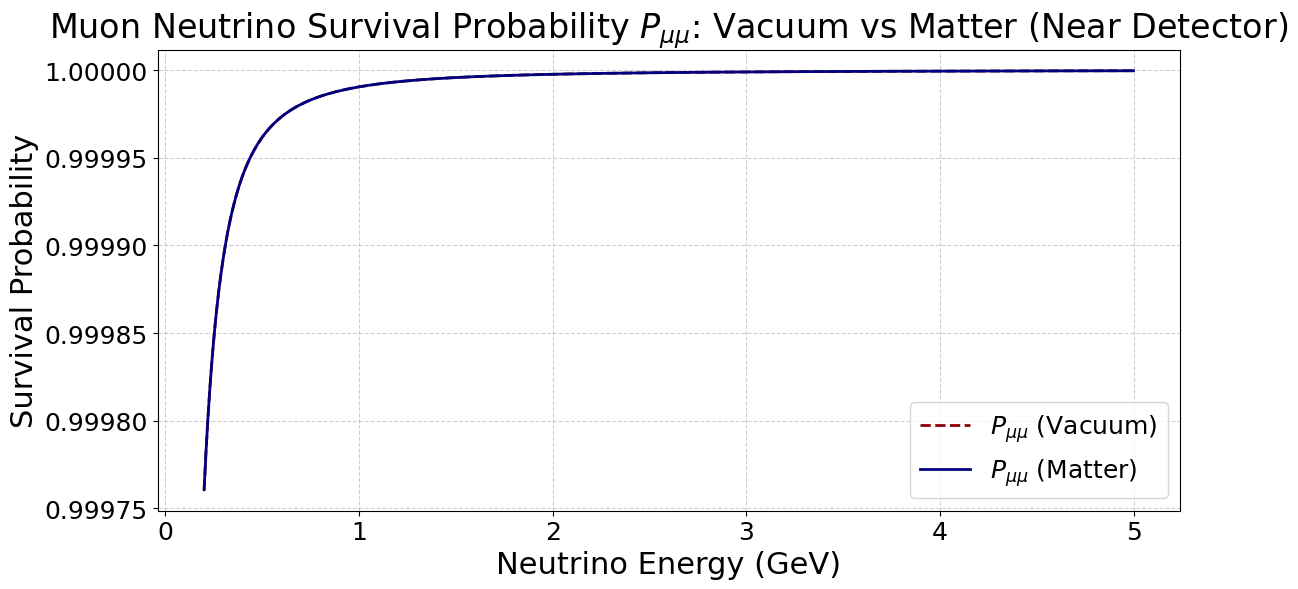

In [ ]:
# Figure 1: Muon Neutrino Survival Probability
plt.figure(figsize=(12, 6))
plt.plot(energy_range / 1e9, prob_mm_vac, '--', color='darkred', linewidth=2, label=r"$P_{\mu\mu}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mm_mat, '-', color='navy', linewidth=2, label=r"$P_{\mu\mu}$ (Matter)")
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Survival Probability", fontsize=22)
plt.title(r"Muon Neutrino Survival Probability $P_{\mu\mu}$: Vacuum vs Matter (Near Detector)", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("pmm_survival_near_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()


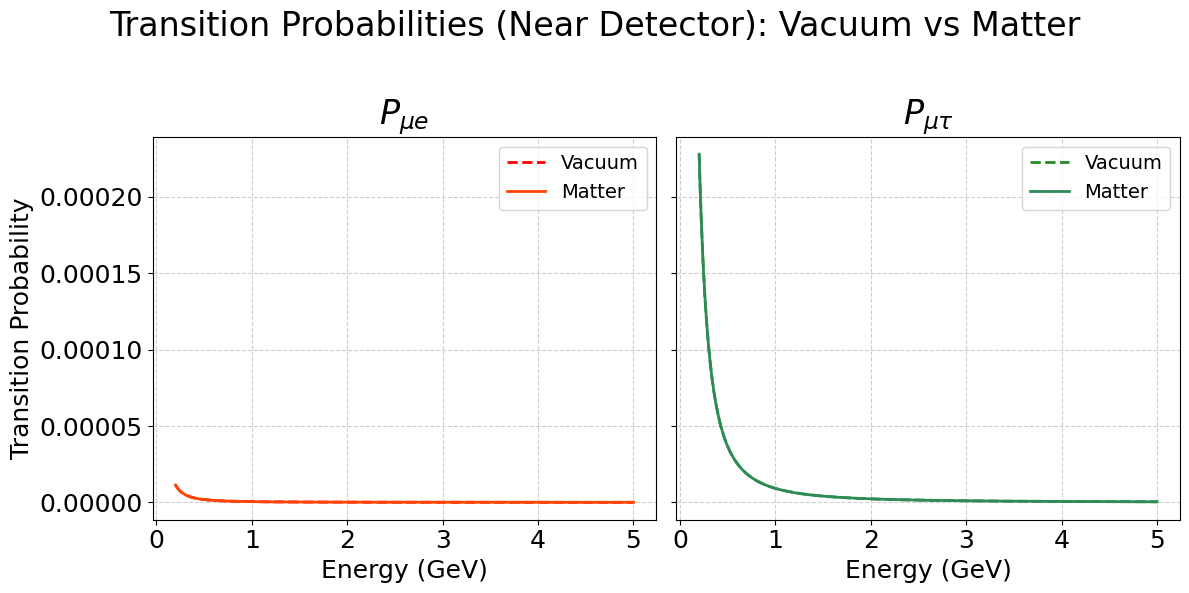

In [ ]:
# Figure 2 & 3: Appearance Probabilities in Subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# Pμe (Muon to Electron)
axes[0].plot(energy_range / 1e9, prob_me_vac, '--', color='red', linewidth=2, label="Vacuum")
axes[0].plot(energy_range / 1e9, prob_me_mat, '-', color='orangered', linewidth=2, label="Matter")
axes[0].set_title(r"$P_{\mu e}$", fontsize=24)
axes[0].set_xlabel("Energy (GeV)", fontsize=18)
axes[0].set_ylabel("Transition Probability", fontsize=18)
axes[0].tick_params(axis='both', labelsize=18)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=14)

# Pμτ (Muon to Tau)
axes[1].plot(energy_range / 1e9, prob_mt_vac, '--', color='forestgreen', linewidth=2, label="Vacuum")
axes[1].plot(energy_range / 1e9, prob_mt_mat, '-', color='seagreen', linewidth=2, label="Matter")
axes[1].set_title(r"$P_{\mu\tau}$", fontsize=24)
axes[1].set_xlabel("Energy (GeV)", fontsize=18)
axes[1].tick_params(axis='both', labelsize=18)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=14)

plt.suptitle("Transition Probabilities (Near Detector): Vacuum vs Matter", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("transition_near_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
from google.colab import files
files.download("transition_near_vacuum_vs_matter.png")

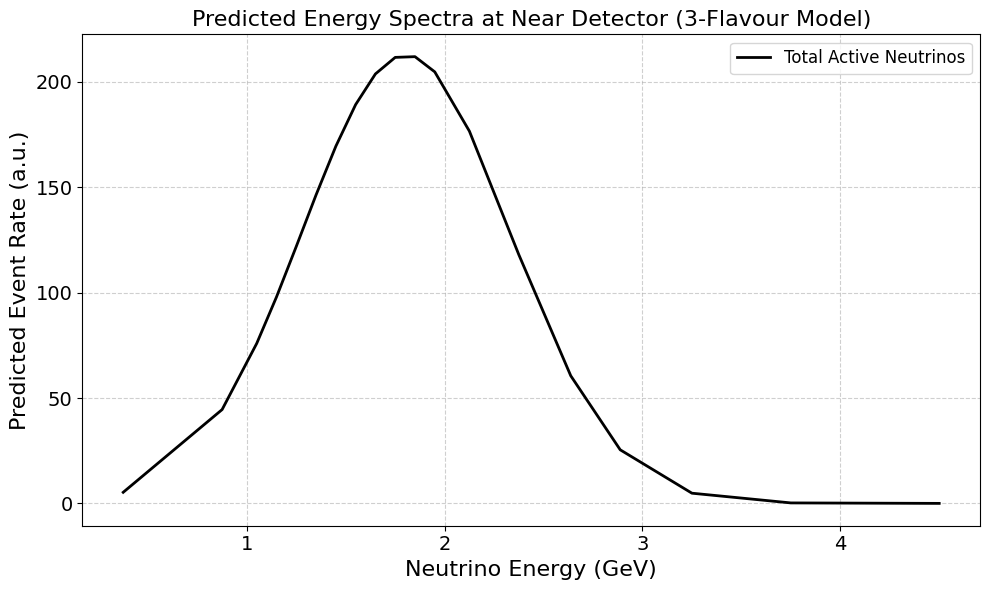

In [ ]:
from scipy.interpolate import interp1d

# Interpolate each probability to the bin centers of the Gaussian flux
interp_mm = interp1d(energy_range, prob_mm_mat, kind='linear')  # use matter or vacuum as needed
interp_me = interp1d(energy_range, prob_me_mat, kind='linear')
interp_mt = interp1d(energy_range, prob_mt_mat, kind='linear')

# Evaluate at bin centers
prob_mm_bins = interp_mm(bin_centers)
prob_me_bins = interp_me(bin_centers)
prob_mt_bins = interp_mt(bin_centers)

# Compute predicted spectra using the Gaussian flux
gaussian_flux = gaussian(bin_centers, *popt_nd)

spectrum_mu = gaussian_flux * prob_mm_bins
spectrum_e  = gaussian_flux * prob_me_bins
spectrum_tau = gaussian_flux * prob_mt_bins
spectrum_all = spectrum_mu + spectrum_e + spectrum_tau  # total active

# Plot
plt.figure(figsize=(10, 6))
#plt.plot(bin_centers / 1e9, spectrum_mu, color='navy', label=r"$\nu_\mu$", linewidth=2)
#plt.plot(bin_centers / 1e9, spectrum_tau, color='forestgreen', label=r"$\nu_\tau$", linewidth=2)
#plt.plot(bin_centers / 1e9, spectrum_e, color='orangered', label=r"$\nu_e$", linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_all, color='black', linestyle='-', linewidth=2, label='Total Active Neutrinos')
#plt.plot(bin_centers / 1e9, gaussian_flux, 'k--', linewidth=2, label='Unoscillated Spectrum')

plt.xlabel("Neutrino Energy (GeV)", fontsize=16)
plt.ylabel("Predicted Event Rate (a.u.)", fontsize=16)
plt.title("Predicted Energy Spectra at Near Detector (3-Flavour Model)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("3flavour_near_detector_energy_spectra.png", dpi=300, bbox_inches='tight')
plt.show()


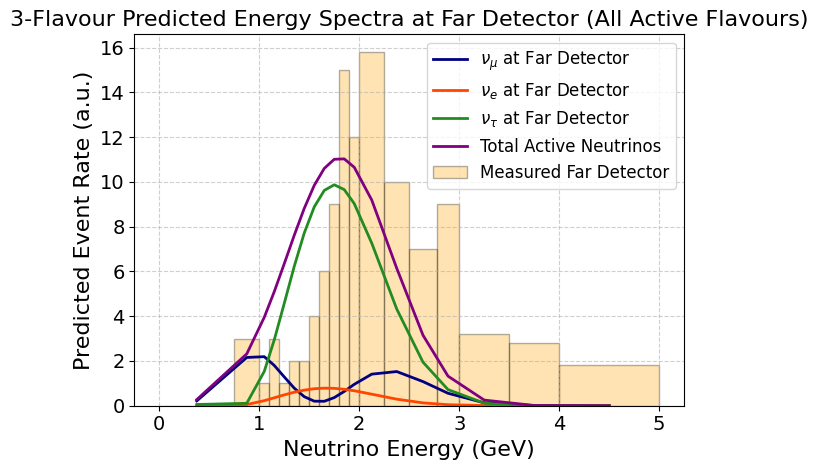

In [ ]:
from scipy.interpolate import interp1d
# Total predicted (unnormalized) active flux
predicted_total = np.sum(spectrum_all)

# Total observed counts at Far Detector
measured_total = np.sum(counts_fd)

# Compute normalization factor
scaling_factor = measured_total / predicted_total


# Create interpolation functions
interp_mm = interp1d(energy_range, prob_mm, kind='linear')
interp_me = interp1d(energy_range, prob_me, kind='linear')
interp_mt = interp1d(energy_range, prob_mt, kind='linear')

# Interpolate to match bin_centers
prob_mm_bins = interp_mm(bin_centers)
prob_me_bins = interp_me(bin_centers)
prob_mt_bins = interp_mt(bin_centers)

gaussian_flux = gaussian(bin_centers, *popt_nd)

spectrum_mu = gaussian_flux * prob_mm_bins
spectrum_e  = gaussian_flux * prob_me_bins
spectrum_tau = gaussian_flux * prob_mt_bins
spectrum_all = spectrum_mu + spectrum_e + spectrum_tau

spectrum_mu_scaled = spectrum_mu * scaling_factor
spectrum_e_scaled  = spectrum_e  * scaling_factor
spectrum_tau_scaled = spectrum_tau * scaling_factor
spectrum_all_scaled = spectrum_mu_scaled + spectrum_e_scaled + spectrum_tau_scaled


plt.plot(bin_centers / 1e9, spectrum_mu_scaled, color='navy', label=r"$\nu_\mu$ at Far Detector", linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_e_scaled, color='orangered', label=r"$\nu_e$ at Far Detector", linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_tau_scaled, color='forestgreen', label=r"$\nu_\tau$ at Far Detector", linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_all_scaled, color='purple', linestyle='-', linewidth=2, label='Total Active Neutrinos')
plt.bar(bin_centers / 1e9, counts_fd, width=np.diff(bin_edges) / 1e9, alpha=0.3, label='Measured Far Detector', color='orange', edgecolor='black')


plt.xlabel("Neutrino Energy (GeV)", fontsize=16)
plt.ylabel("Predicted Event Rate (a.u.)", fontsize=16)
plt.title("3-Flavour Predicted Energy Spectra at Far Detector (All Active Flavours)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("3flavour_active_energy_spectra.png", dpi=300, bbox_inches='tight')
plt.show()


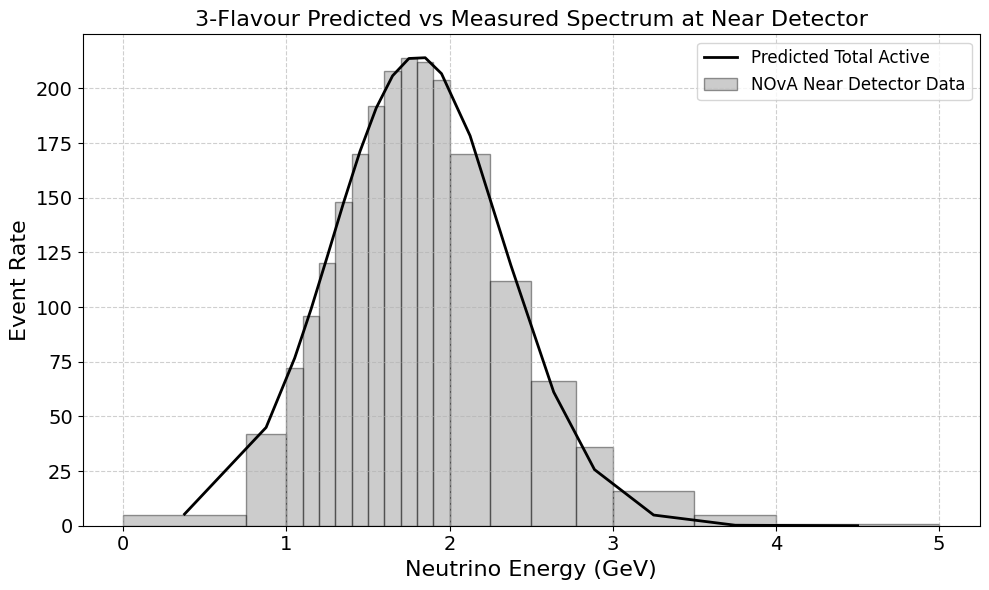

In [ ]:
from scipy.interpolate import interp1d

# Interpolate each probability to the bin centers of the Gaussian flux
interp_mm = interp1d(energy_range, prob_mm_mat, kind='linear')  # use matter or vacuum as needed
interp_me = interp1d(energy_range, prob_me_mat, kind='linear')
interp_mt = interp1d(energy_range, prob_mt_mat, kind='linear')

# Evaluate at bin centers
prob_mm_bins = interp_mm(bin_centers)
prob_me_bins = interp_me(bin_centers)
prob_mt_bins = interp_mt(bin_centers)

# Compute predicted spectra using the Gaussian flux
gaussian_flux = gaussian(bin_centers, *popt_nd)

spectrum_mu = gaussian_flux * prob_mm_bins
spectrum_e  = gaussian_flux * prob_me_bins
spectrum_tau = gaussian_flux * prob_mt_bins
spectrum_all = spectrum_mu + spectrum_e + spectrum_tau  # total active

total_measured = np.sum(counts_nd)  # Total observed at Near Detector
total_predicted = np.sum(spectrum_all)

scaling_factor = total_measured / total_predicted
spectrum_all_normalized = spectrum_all * scaling_factor

# Plot overlayed with ND data
plt.figure(figsize=(10, 6))

plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9,
        alpha=0.4, label='NOvA Near Detector Data', color='gray', edgecolor='black')

plt.plot(bin_centers / 1e9, spectrum_all_normalized, color='black', linestyle='-', linewidth=2, label='Predicted Total Active')

plt.xlabel("Neutrino Energy (GeV)", fontsize=16)
plt.ylabel("Event Rate", fontsize=16)
plt.title("3-Flavour Predicted vs Measured Spectrum at Near Detector", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("3flavour_vs_data_near_detector.png", dpi=300, bbox_inches='tight')
plt.show()


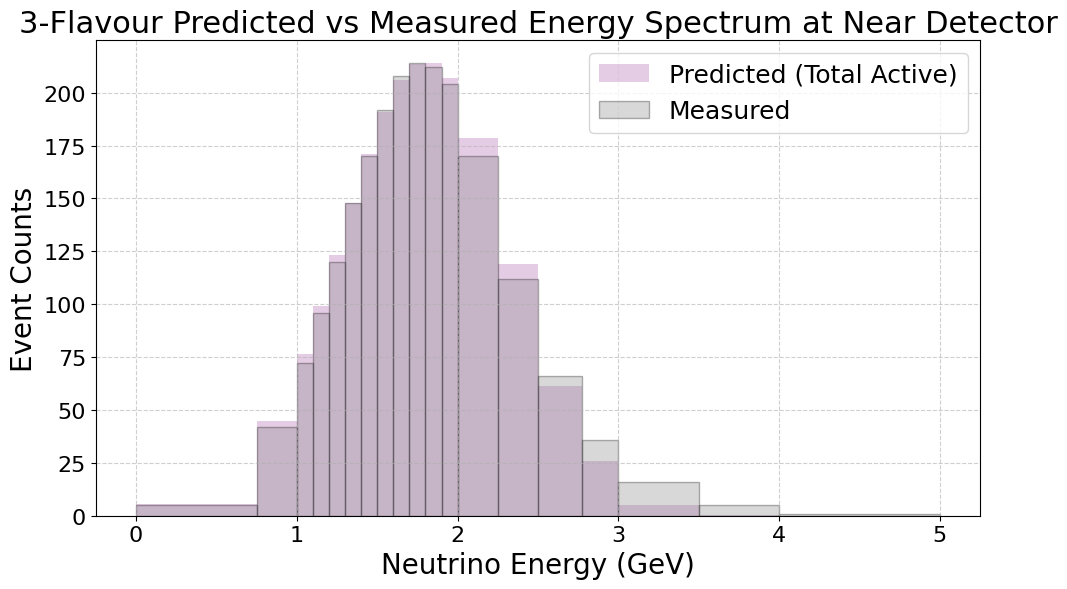

In [ ]:
#Plot histograms (bar overlay)
plt.figure(figsize=(10, 6))

# Predicted (3-flavour) total active
plt.bar(
    bin_centers / 1e9,
    spectrum_all_normalized,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.2,
    color='purple',
    label='Predicted (Total Active)'
)

# Measured ND data
plt.bar(
    bin_centers / 1e9,
    counts_nd,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.3,
    color='gray',
    edgecolor='black',
    label='Measured'
)

# Labels & formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Event Counts", fontsize=20)
plt.title("3-Flavour Predicted vs Measured Energy Spectrum at Near Detector", fontsize=22)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("3flavour_predicted_vs_measured_ND_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

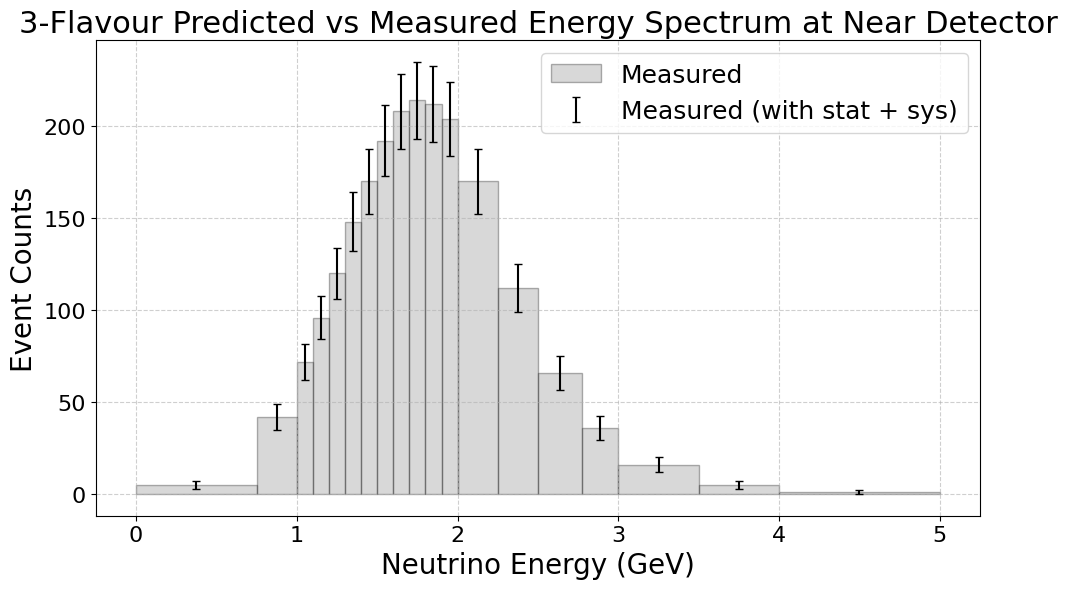

In [ ]:
f_sys = 0.07  # 7% systematic uncertainty

stat_unc = np.sqrt(counts_nd)
sys_unc = f_sys * counts_nd
total_unc = np.sqrt(stat_unc**2 + sys_unc**2)


# Plot histograms (bar overlay)
plt.figure(figsize=(10, 6))



# Measured ND data
plt.bar(
    bin_centers / 1e9,
    counts_nd,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.3,
    color='gray',
    edgecolor='black',
    label='Measured'
)

plt.errorbar(
    bin_centers / 1e9,
    counts_nd,
    yerr=total_unc,
    fmt=' ',
    color='black',
    label='Measured (with stat + sys)',
    capsize=3
)


# Labels & formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Event Counts", fontsize=20)
plt.title("3-Flavour Predicted vs Measured Energy Spectrum at Near Detector", fontsize=22)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("3flavour_measured_ND_histogram_with_uncertainty.png", dpi=300, bbox_inches='tight')
plt.show()

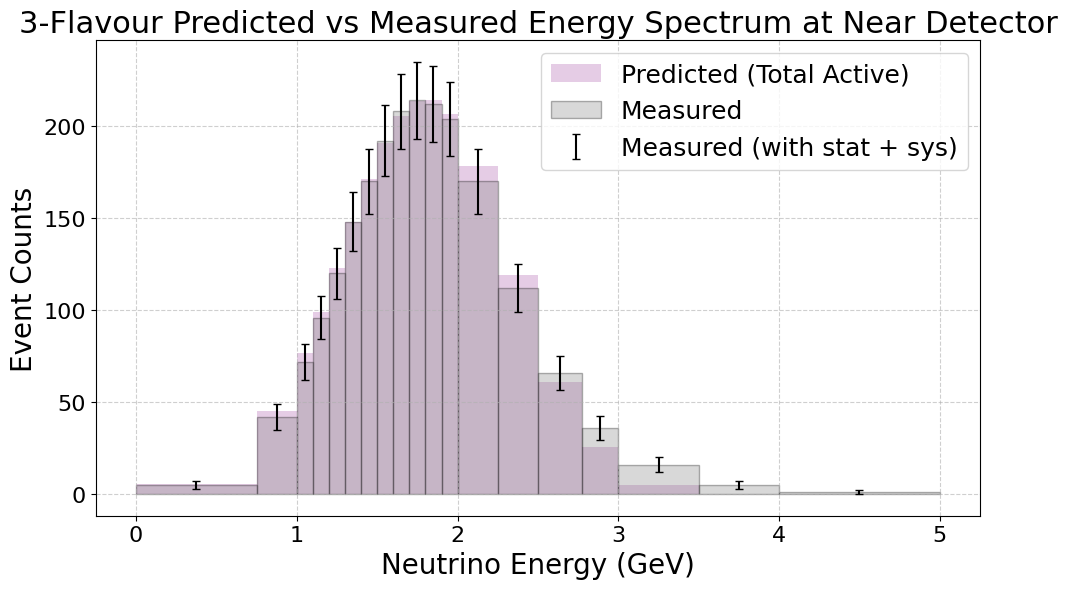

In [ ]:
f_sys = 0.07  # 7% systematic uncertainty

stat_unc = np.sqrt(counts_nd)
sys_unc = f_sys * counts_nd
total_unc = np.sqrt(stat_unc**2 + sys_unc**2)


# Plot histograms (bar overlay)
plt.figure(figsize=(10, 6))

# Predicted (3-flavour) total active
plt.bar(
    bin_centers / 1e9,
    spectrum_all_normalized,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.2,
    color='purple',
    label='Predicted (Total Active)'
)

# Measured ND data
plt.bar(
    bin_centers / 1e9,
    counts_nd,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.3,
    color='gray',
    edgecolor='black',
    label='Measured'
)

plt.errorbar(
    bin_centers / 1e9,
    counts_nd,
    yerr=total_unc,
    fmt=' ',
    color='black',
    label='Measured (with stat + sys)',
    capsize=3
)


# Labels & formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Event Counts", fontsize=20)
plt.title("3-Flavour Predicted vs Measured Energy Spectrum at Near Detector", fontsize=22)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("3flavour_predicted_vs_measured_ND_histogram_with_uncertainty.png", dpi=300, bbox_inches='tight')
plt.show()

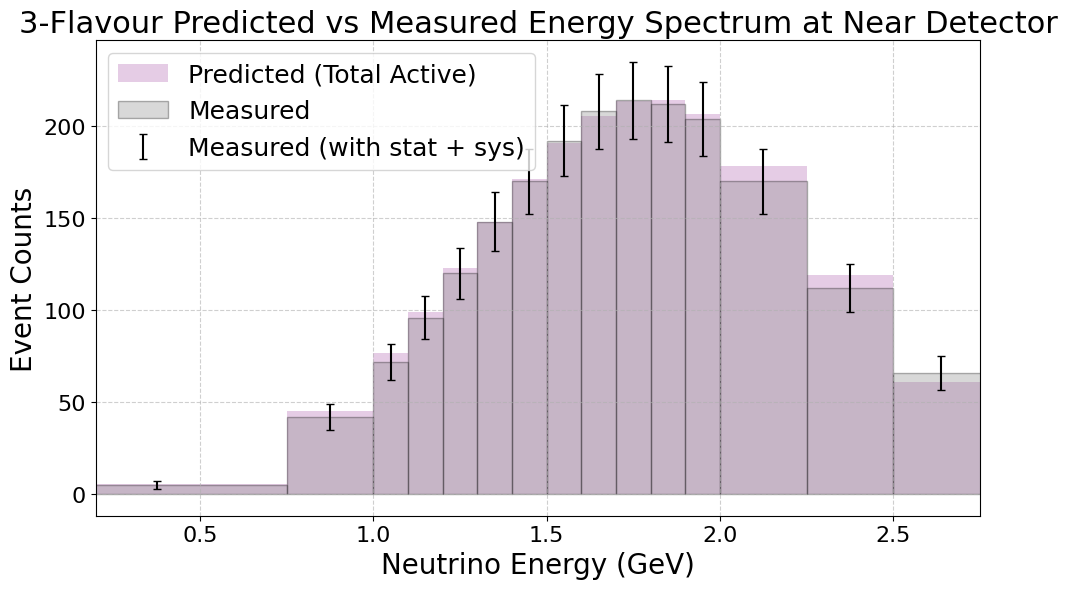

In [ ]:
f_sys = 0.07  # 7% systematic uncertainty

stat_unc = np.sqrt(counts_nd)
sys_unc = f_sys * counts_nd
total_unc = np.sqrt(stat_unc**2 + sys_unc**2)


# Plot histograms (bar overlay)
plt.figure(figsize=(10, 6))

# Predicted (3-flavour) total active
plt.bar(
    bin_centers / 1e9,
    spectrum_all_normalized,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.2,
    color='purple',
    label='Predicted (Total Active)'
)

# Measured ND data
plt.bar(
    bin_centers / 1e9,
    counts_nd,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.3,
    color='gray',
    edgecolor='black',
    label='Measured'
)

plt.errorbar(
    bin_centers / 1e9,
    counts_nd,
    yerr=total_unc,
    fmt=' ',
    color='black',
    label='Measured (with stat + sys)',
    capsize=3
)


# Labels & formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Event Counts", fontsize=20)
plt.title("3-Flavour Predicted vs Measured Energy Spectrum at Near Detector", fontsize=22)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=18)
plt.xlim(0.2,2.75)
plt.tight_layout()
plt.savefig("3flavour_predicted_vs_measured_ND_histogram_with_uncertainty.png", dpi=300, bbox_inches='tight')
plt.show()

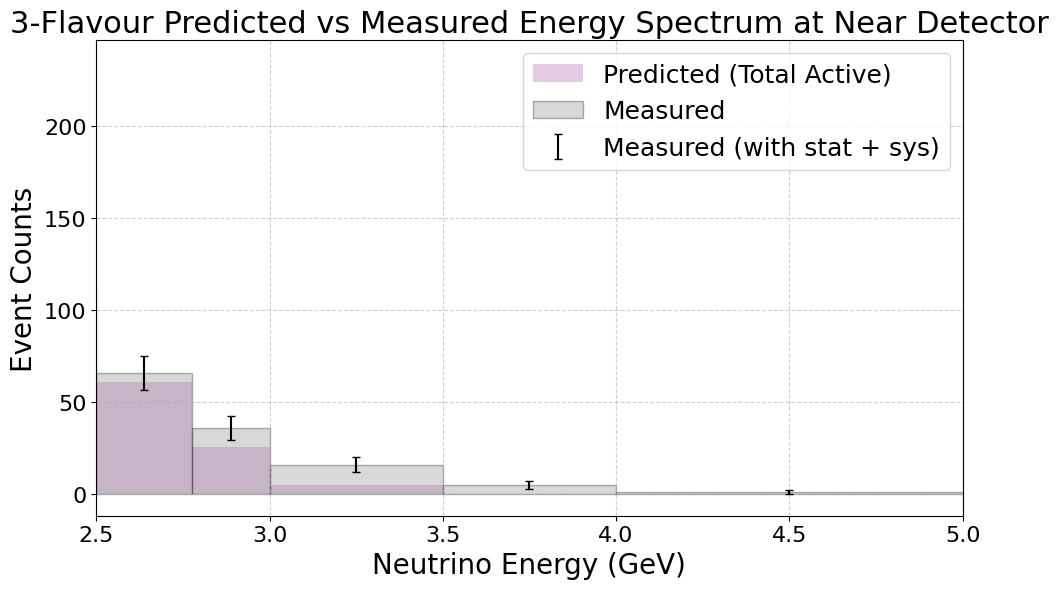

In [ ]:
f_sys = 0.07  # 7% systematic uncertainty

stat_unc = np.sqrt(counts_nd)
sys_unc = f_sys * counts_nd
total_unc = np.sqrt(stat_unc**2 + sys_unc**2)


# Plot histograms (bar overlay)
plt.figure(figsize=(10, 6))

# Predicted (3-flavour) total active
plt.bar(
    bin_centers / 1e9,
    spectrum_all_normalized,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.2,
    color='purple',
    label='Predicted (Total Active)'
)

# Measured ND data
plt.bar(
    bin_centers / 1e9,
    counts_nd,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.3,
    color='gray',
    edgecolor='black',
    label='Measured'
)

plt.errorbar(
    bin_centers / 1e9,
    counts_nd,
    yerr=total_unc,
    fmt=' ',
    color='black',
    label='Measured (with stat + sys)',
    capsize=3
)


# Labels & formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Event Counts", fontsize=20)
plt.title("3-Flavour Predicted vs Measured Energy Spectrum at Near Detector", fontsize=22)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=18)
plt.xlim(2.5,5.0)
plt.tight_layout()
plt.savefig("3flavour_predicted_vs_measured_ND_histogram_with_uncertainty.png", dpi=300, bbox_inches='tight')
plt.show()

[-0.31133486 -2.95804303 -4.6592022  -2.93917142 -3.15226298  0.16179595
 -1.15954108  0.88899229  2.20233379  0.27007063 -2.07225943 -2.78812592
 -8.38764113 -7.16305256  4.85660822 10.32043105 11.11733134  4.77348572
  0.9995856 ]


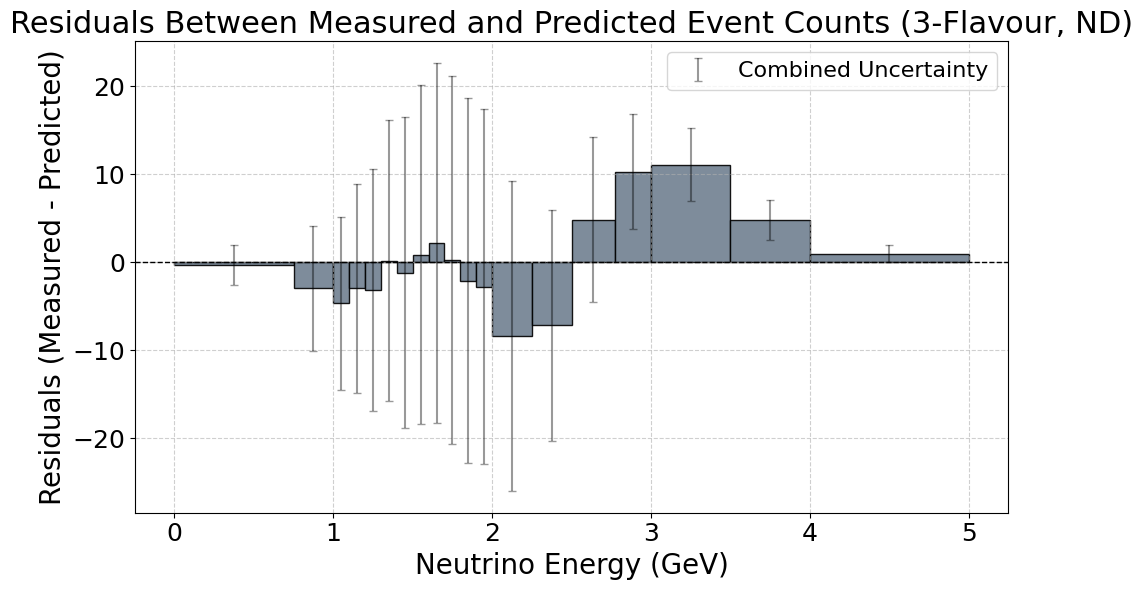

Scaling factor applied: 1.0099


In [ ]:
residuals = counts_nd - spectrum_all_normalized
print(residuals)

# Plot residuals
plt.figure(figsize=(10, 6))
plt.bar(bin_centers / 1e9, residuals, width=np.diff(bin_edges) / 1e9, color='slategrey', alpha=0.9, edgecolor='black')
plt.errorbar(bin_centers / 1e9, residuals, yerr=total_unc, fmt=' ', color='black', capsize=3, alpha = 0.4, label = 'Combined Uncertainty')

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Residuals (Measured - Predicted)", fontsize=20)
plt.title("Residuals Between Measured and Predicted Event Counts (3-Flavour, ND)", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize = 16)
plt.tight_layout()
plt.savefig("3flavour_residuals_ND.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Scaling factor applied: {scaling_factor:.4f}")


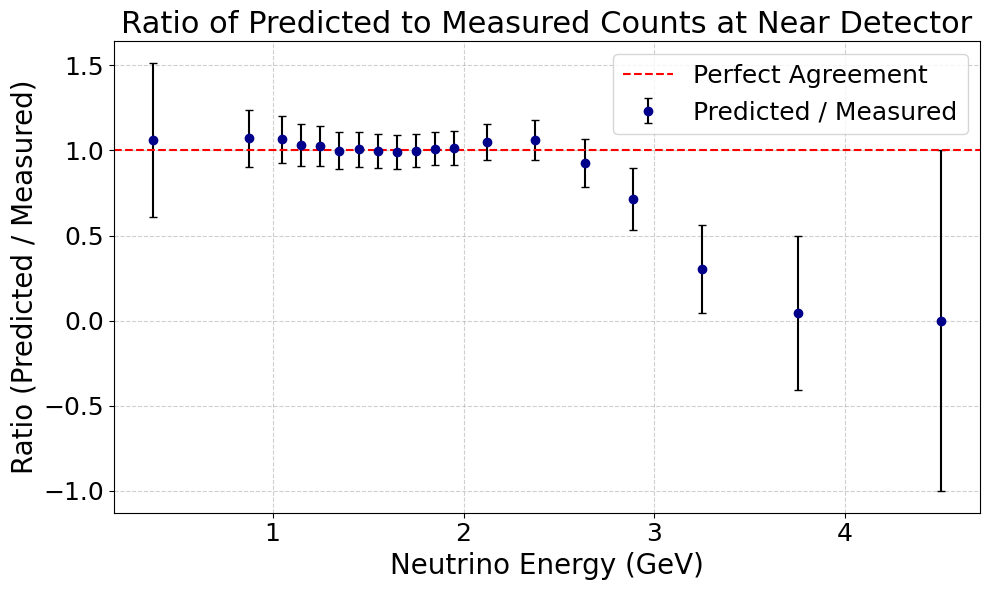

In [ ]:
# Avoid division by zero
mask = counts_nd > 0

# Compute ratios and ratio uncertainties
ratios = np.full_like(counts_nd, np.nan, dtype=float)
ratio_unc = np.full_like(counts_nd, np.nan, dtype=float)

ratios[mask] = spectrum_all_normalized[mask] / counts_nd[mask]
ratio_unc[mask] = total_unc[mask] / counts_nd[mask]  # Relative uncertainty in ratio


plt.figure(figsize=(10, 6))

# Plot ratio with vertical error bars only
plt.errorbar(
    bin_centers / 1e9,
    ratios,
    yerr=ratio_unc,
    fmt='o',
    color='darkblue',
    ecolor='black',
    capsize=3,
    elinewidth=1.5,
    label='Predicted / Measured'
)

plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Perfect Agreement')

plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Ratio (Predicted / Measured)", fontsize=20)
plt.title("Ratio of Predicted to Measured Counts at Near Detector", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("ratio_predicted_measured_ND_errorbars.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
from scipy.stats import pearsonr

# Avoid zero divisions
mask = counts_nd > 0

# Corrected chi-squared using uncertainties
chi_squared = np.sum(((spectrum_all_normalized[mask] - counts_nd[mask])**2) / total_unc[mask]**2)
ndf = np.sum(mask) - 1
chi_squared_ndf = chi_squared / ndf

print(f"Chi-squared: {chi_squared:.2f}")
print(f"Chi-squared / NDF: {chi_squared_ndf:.2f}")

# MAE and RMSE are still fine as-is
mae = np.mean(np.abs(spectrum_all_normalized - counts_nd))
print(f"Mean Absolute Error (MAE): {mae:.2f}")

rmse = np.sqrt(np.mean((spectrum_all_normalized - counts_nd)**2))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Pearson correlation coefficient (still valid)
r_value, _ = pearsonr(spectrum_all_normalized, counts_nd)
print(f"Pearson Correlation Coefficient: {r_value:.3f}")



Chi-squared: 16.49
Chi-squared / NDF: 0.92
Mean Absolute Error (MAE): 3.75
Root Mean Squared Error (RMSE): 4.96
Pearson Correlation Coefficient: 0.998


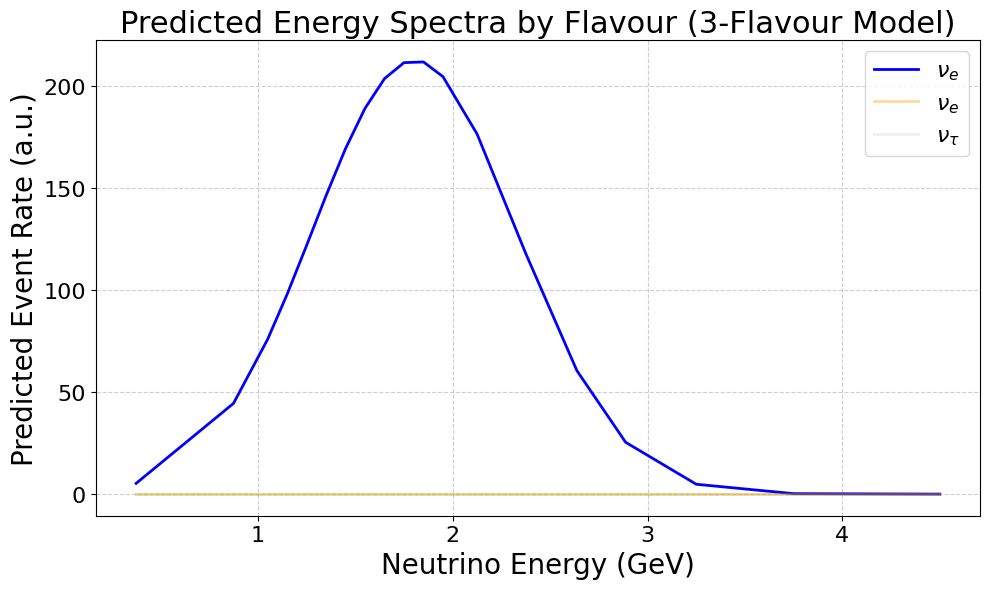

In [ ]:
# Plot the individual spectra
plt.figure(figsize=(10, 6))
plt.plot(bin_centers / 1e9, spectrum_mu, label=r"$\nu_e$", color='blue', linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_e, label=r"$\nu_e$", color='orange', linewidth=2, alpha = 0.4)
plt.plot(bin_centers / 1e9, spectrum_tau, label=r"$\nu_\tau$", color='forestgreen',alpha = 0.1, linewidth=2)

plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Predicted Event Rate (a.u.)", fontsize=20)
plt.title("Predicted Energy Spectra by Flavour (3-Flavour Model)", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("3flavour_predicted_spectra_by_flavour_all.png", dpi=300, bbox_inches='tight')
plt.show()

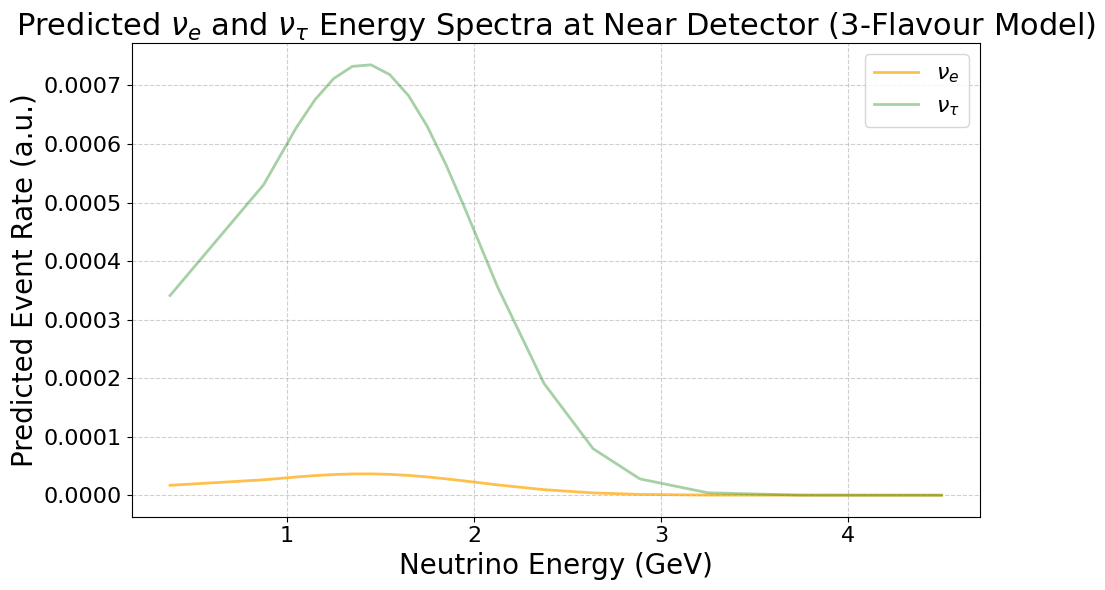

In [ ]:
# Compute individual spectra
spectrum_mu = gaussian_flux * prob_mm_bins
spectrum_e  = gaussian_flux * prob_me_bins
spectrum_tau = gaussian_flux * prob_mt_bins

# Plot the individual spectra
plt.figure(figsize=(10, 6))

plt.plot(bin_centers / 1e9, spectrum_e, label=r"$\nu_e$", color='orange', linewidth=2, alpha = 0.7)
plt.plot(bin_centers / 1e9, spectrum_tau, label=r"$\nu_\tau$", color='forestgreen',alpha = 0.4, linewidth=2)

plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Predicted Event Rate (a.u.)", fontsize=20)
plt.title(r"Predicted $\nu_e$ and $\nu_\tau$ Energy Spectra at Near Detector (3-Flavour Model)", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("3flavour_predicted_spectra_by_flavour_e_and_tau.png", dpi=300, bbox_inches='tight')
plt.show()


Four Flavour Model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

# Constants
CONV_KM_TO_INV_EV = 5.067731e9  # Conversion factor from km to inverse eV
VCC_EARTH_CRUST = 7.6e-14  # Matter potential in eV

# Define mixing matrix elements
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12 * c13 * c14, s12 * c13 * c14, s13 * c14 * np.exp(-1j * delta13), s14 * np.exp(-1j * delta14)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta13),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta13),
         c13 * s23,
         s24 * c13],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta13),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta13),
         c13 * c23,
         c24 * s34],
        [0, 0, 0, c34]
    ])
    return U

# Define Hamiltonians
def hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E):
    m2_diag = np.diag([0, D21, D31, D41])  # Mass squared differences
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    H_vacuum = U @ m2_diag @ np.conj(U.T) / (2 * E)
    return H_vacuum

def hamiltonian_4nu_matter(H_vacuum, E, VCC):
    H_matter = H_vacuum + np.diag([VCC, 0, 0, 0])
    return H_matter

# Compute probabilities
def probabilities_4nu_vacuum(H_vacuum, baseline):
    H_t = -1j * H_vacuum * baseline
    S = expm(H_t)  # Evolution operator
    Pmm = np.abs(S[1, 1])**2  # Muon neutrino survival probability
    Pme = np.abs(S[1, 0])**2  # Muon to electron
    Pmt = np.abs(S[1, 2])**2  # Muon to tau
    Pms = np.abs(S[1, 3])**2  # Muon to sterile
    return Pmm, Pme, Pmt, Pms

def probabilities_4nu_matter(H_matter, baseline):
    H_t = -1j * H_matter * baseline
    S = expm(H_t)  # Evolution operator
    Pmm = np.abs(S[1, 1])**2  # Muon neutrino survival probability
    Pme = np.abs(S[1, 0])**2  # Muon to electron
    Pmt = np.abs(S[1, 2])**2  # Muon to tau
    Pms = np.abs(S[1, 3])**2  # Muon to sterile
    return Pmm, Pme, Pmt, Pms

# Compute oscillation probabilities
def compute_probabilities(baseline, energy_values, matter = False):
    Prob_mm, Prob_me, Prob_mt, Prob_ms = [], [], [], []
    for E in energy_values:
        #Compute vacuum hamiltonian
        H_vacuum = hamiltonian_4nu_vacuum(
            theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E
        )

        if matter:
          #Compute matter hamiltonian if matter effects included
          H_matter = hamiltonian_4nu_matter(H_vacuum, E, VCC_EARTH_CRUST)
          Pmm, Pme, Pmt, Pms = probabilities_4nu_matter(H_matter, baseline * CONV_KM_TO_INV_EV)


        else:
          #Vacuum oscillations if no matter effects
          Pmm, Pme, Pmt, Pms = probabilities_4nu_vacuum(H_vacuum, baseline * CONV_KM_TO_INV_EV)



        Prob_mm.append(Pmm)
        Prob_me.append(Pme)
        Prob_mt.append(Pmt)
        Prob_ms.append(Pms)
    return np.array(Prob_mm), np.array(Prob_me), np.array(Prob_mt), np.array(Prob_ms)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9  # eV
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # eV
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])

# Detector Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Oscillation Parameters (Updated to best-fit values from global sterile neutrino fits)
theta12, theta13, theta23 = np.radians([33.82, 8.61, 48.3])       # Standard PMNS angles
theta14, theta24, theta34 = np.radians([7.2, 9.2, 0.0])           # Best-fit sterile angles
delta13, delta14 = np.radians([0, 0])                             # CP-violating phases (neglected here)
D21, D31, D41 = [7.39e-5, 2.525e-3, 1.3]                           # Mass squared differences in eV^2


# Fit the near detector data with a Gaussian
popt_nd, _ = curve_fit(
    gaussian,
    bin_centers,
    counts_nd,
    p0=[np.max(counts_nd), 2.5e9, 0.5e9]
)

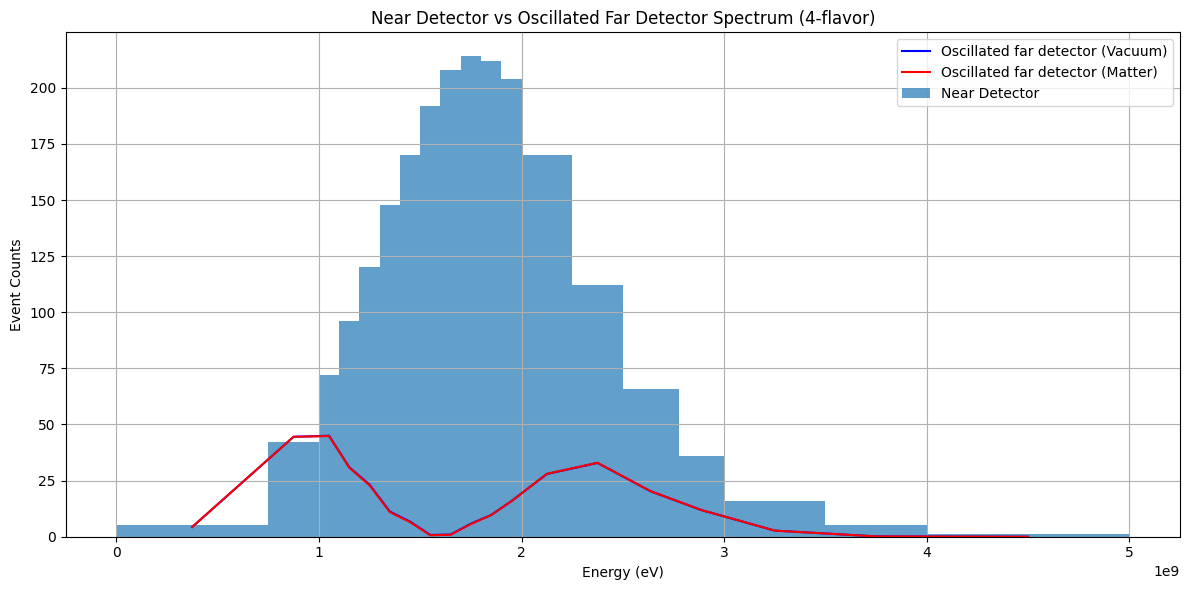

In [ ]:
#Compute oscillation probabilities at the far detector
prob_mm_far_vac, prob_me_far_vac, prob_mt_far_vac, prob_ms_far_vac = compute_probabilities(Length_far, bin_centers, matter = False)
prob_mm_far_matter, prob_me_far_matter, prob_mt_far_matter, prob_ms_far_matter = compute_probabilities(Length_far, bin_centers, matter = True)

# Oscillated far detector spectrum (apply oscillation to fitted Gaussian)
oscillated_fd_vac = gaussian(bin_centers, *popt_nd) * prob_mm_far_vac / np.max(prob_mm_far_vac)
oscillated_fd_matter = gaussian(bin_centers, *popt_nd) * prob_mm_far_matter / np.max(prob_mm_far_matter)

plt.figure(figsize = (12, 6))
plt.bar(bin_centers, counts_nd, width=np.diff(bin_edges), align='center', alpha=0.7, label='Near Detector')
plt.plot(bin_centers, oscillated_fd_vac, 'b-', label = 'Oscillated far detector (Vacuum)')
plt.plot(bin_centers, oscillated_fd_matter, 'r-', label = 'Oscillated far detector (Matter)')

#Labels and Titles
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum (4-flavor)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

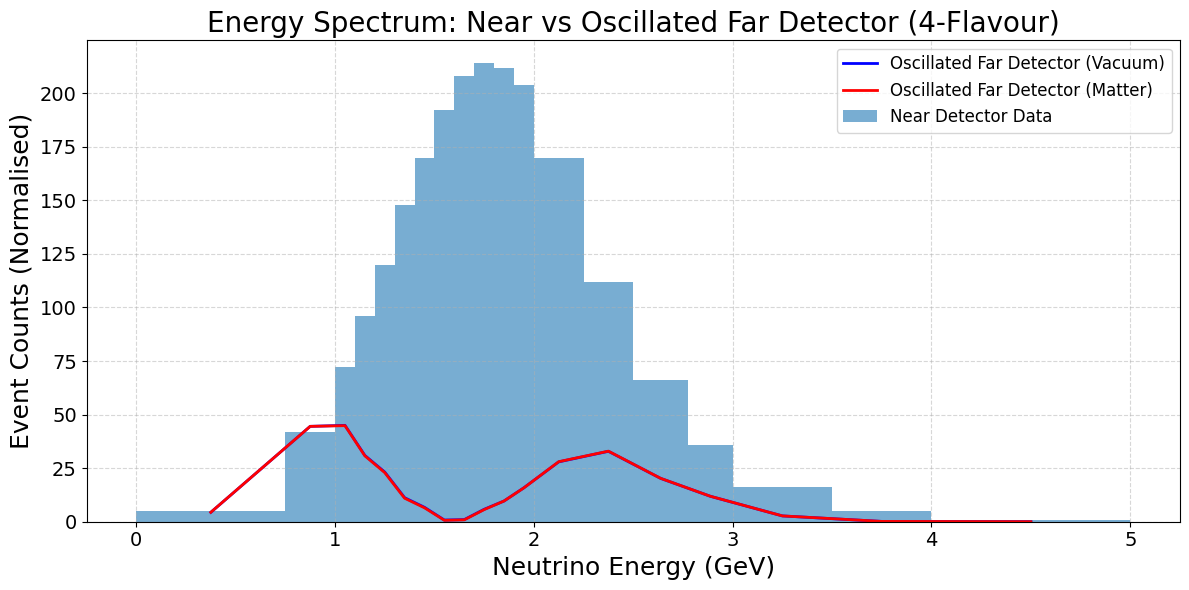

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, align='center',
        alpha=0.6, label='Near Detector Data')

plt.plot(bin_centers / 1e9, oscillated_fd_vac, 'b-', linewidth=2, label='Oscillated Far Detector (Vacuum)')
plt.plot(bin_centers / 1e9, oscillated_fd_matter, 'r-', linewidth=2, label='Oscillated Far Detector (Matter)')

plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Event Counts (Normalised)", fontsize=18)
plt.title("Energy Spectrum: Near vs Oscillated Far Detector (4-Flavour)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("4flavour_far_spectrum_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


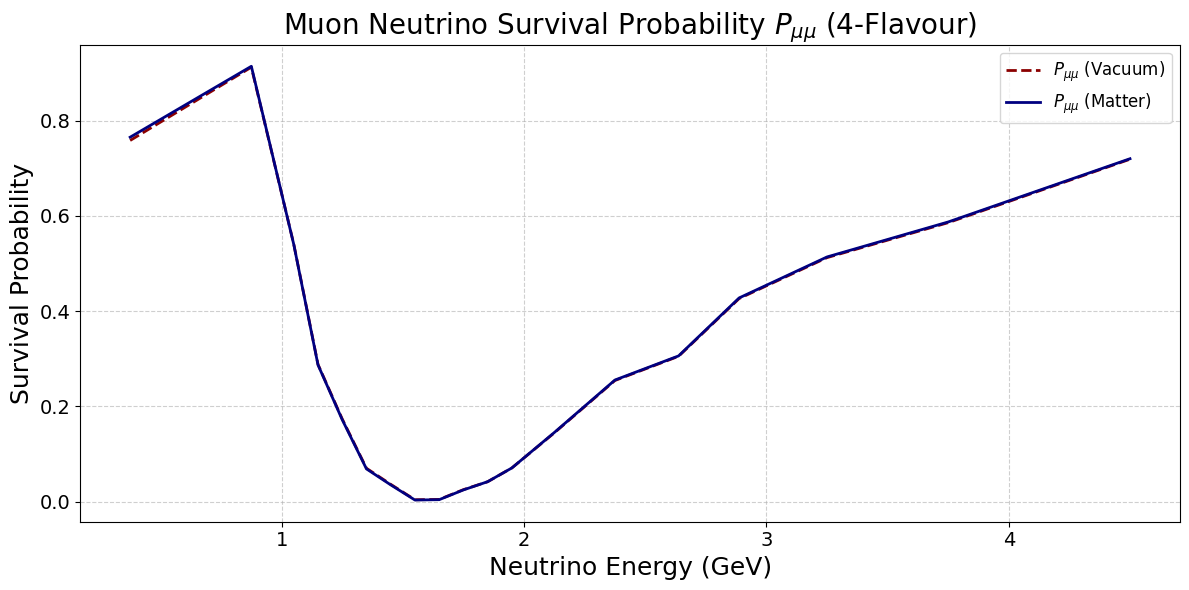

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(bin_centers / 1e9, prob_mm_far_vac, '--', color='darkred', linewidth=2, label=r"$P_{\mu\mu}$ (Vacuum)")
plt.plot(bin_centers / 1e9, prob_mm_far_matter, '-', color='navy', linewidth=2, label=r"$P_{\mu\mu}$ (Matter)")

plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Survival Probability", fontsize=18)
plt.title(r"Muon Neutrino Survival Probability $P_{\mu\mu}$ (4-Flavour)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_pmm_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()


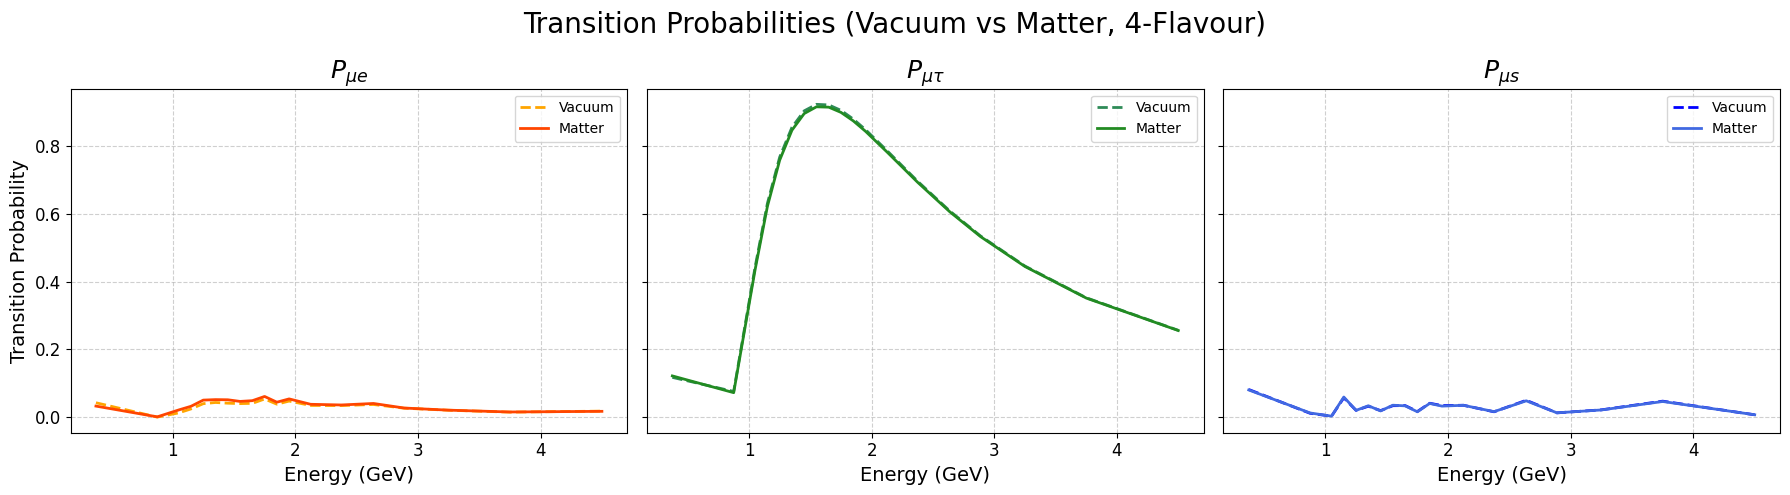

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Pμe
axes[0].plot(bin_centers / 1e9, prob_me_far_vac, '--', color='orange', linewidth=2, label="Vacuum")
axes[0].plot(bin_centers / 1e9, prob_me_far_matter, '-', color='orangered', linewidth=2, label="Matter")
axes[0].set_title(r"$P_{\mu e}$", fontsize=18)
axes[0].set_xlabel("Energy (GeV)", fontsize=14)
axes[0].set_ylabel("Transition Probability", fontsize=14)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Pμτ
axes[1].plot(bin_centers / 1e9, prob_mt_far_vac, '--', color='seagreen', linewidth=2, label="Vacuum")
axes[1].plot(bin_centers / 1e9, prob_mt_far_matter, '-', color='forestgreen', linewidth=2, label="Matter")
axes[1].set_title(r"$P_{\mu\tau}$", fontsize=18)
axes[1].set_xlabel("Energy (GeV)", fontsize=14)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

# Pμs (Sterile)
axes[2].plot(bin_centers / 1e9, prob_ms_far_vac, '--', color='blue', linewidth=2, label="Vacuum")
axes[2].plot(bin_centers / 1e9, prob_ms_far_matter, '-', color='royalblue', linewidth=2, label="Matter")
axes[2].set_title(r"$P_{\mu s}$", fontsize=18)
axes[2].set_xlabel("Energy (GeV)", fontsize=14)
axes[2].tick_params(axis='both', labelsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Transition Probabilities (Vacuum vs Matter, 4-Flavour)", fontsize=20)
plt.tight_layout()
plt.savefig("4flavour_transition_probabilities_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()


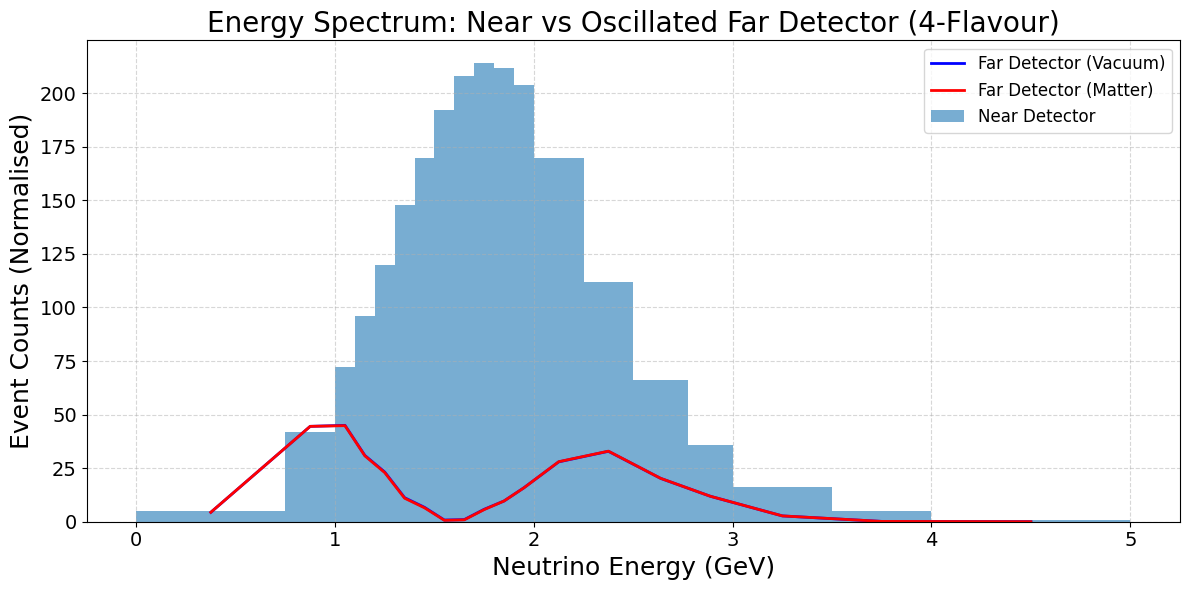

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9,
        align='center', alpha=0.6, label='Near Detector')

plt.plot(bin_centers / 1e9, oscillated_fd_vac, 'b-', linewidth=2, label='Far Detector (Vacuum)')
plt.plot(bin_centers / 1e9, oscillated_fd_matter, 'r-', linewidth=2, label='Far Detector (Matter)')

plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Event Counts (Normalised)", fontsize=18)
plt.title("Energy Spectrum: Near vs Oscillated Far Detector (4-Flavour)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("4flavour_far_detector_spectra.png", dpi=300, bbox_inches='tight')
plt.show()


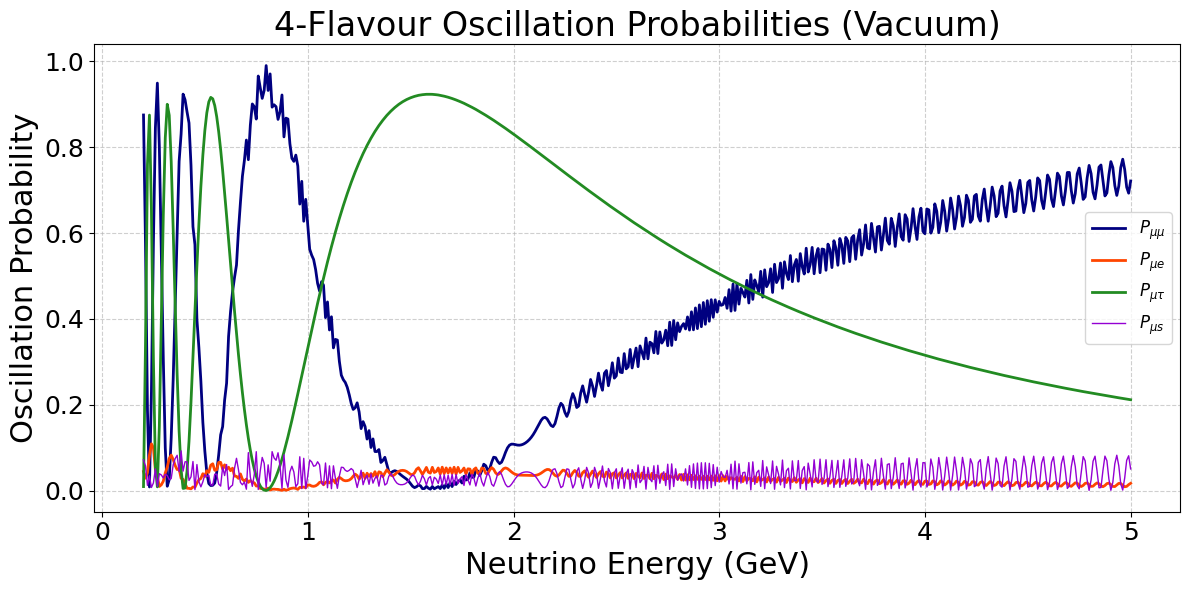

In [ ]:
# Define continuous energy range
energy_range = np.linspace(0.2e9, 5e9, 500)  # in eV

# Compute probabilities over continuous range
prob_mm_vac, prob_me_vac, prob_mt_vac, prob_ms_vac = compute_probabilities(
    baseline=Length_far,
    energy_values=energy_range,
    matter=False
)



# Plotting
plt.figure(figsize=(12, 6))

plt.plot(energy_range / 1e9, prob_mm_vac, '-', linewidth=2, label=r"$P_{\mu\mu}$", color="navy")
plt.plot(energy_range / 1e9, prob_me_vac, '-', linewidth=2, label=r"$P_{\mu e}$", color="orangered")
plt.plot(energy_range / 1e9, prob_mt_vac, '-', linewidth=2, label=r"$P_{\mu \tau}$", color="forestgreen")
plt.plot(energy_range / 1e9, prob_ms_vac, '-', linewidth=1, label=r"$P_{\mu s}$", color="darkviolet")

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Oscillation Probability", fontsize=22)
plt.title("4-Flavour Oscillation Probabilities (Vacuum)", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_oscillation_probabilities_vacuum.png", dpi=300, bbox_inches='tight')
plt.show()


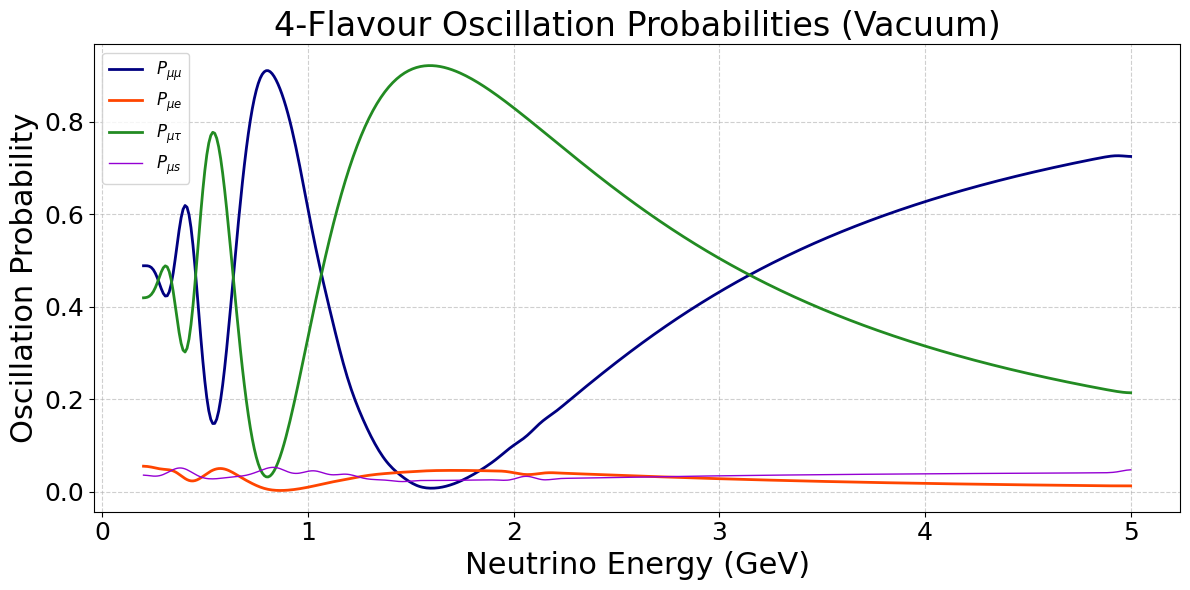

In [ ]:
from scipy.ndimage import gaussian_filter1d

# Apply Gaussian smoothing to simulate energy resolution
sigma_bins = 5  # You can adjust this to match NOvA resolution (~100–200 MeV)
prob_mm_vac_smoothed = gaussian_filter1d(prob_mm_vac, sigma=sigma_bins)
prob_me_vac_smoothed = gaussian_filter1d(prob_me_vac, sigma=sigma_bins)
prob_mt_vac_smoothed = gaussian_filter1d(prob_mt_vac, sigma=sigma_bins)
prob_ms_vac_smoothed = gaussian_filter1d(prob_ms_vac, sigma=sigma_bins)

plt.figure(figsize=(12, 6))

plt.plot(energy_range / 1e9, prob_mm_vac_smoothed, '-', linewidth=2, label=r"$P_{\mu\mu}$", color="navy")
plt.plot(energy_range / 1e9, prob_me_vac_smoothed, '-', linewidth=2, label=r"$P_{\mu e}$", color="orangered")
plt.plot(energy_range / 1e9, prob_mt_vac_smoothed, '-', linewidth=2, label=r"$P_{\mu \tau}$", color="forestgreen")
plt.plot(energy_range / 1e9, prob_ms_vac_smoothed, '-', linewidth=1, label=r"$P_{\mu s}$", color="darkviolet")

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Oscillation Probability", fontsize=22)
plt.title("4-Flavour Oscillation Probabilities (Vacuum)", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_oscillation_probabilities_vacuum.png", dpi=300, bbox_inches='tight')
plt.show()



Using sigma_bins = 7 for ~0.15 GeV resolution


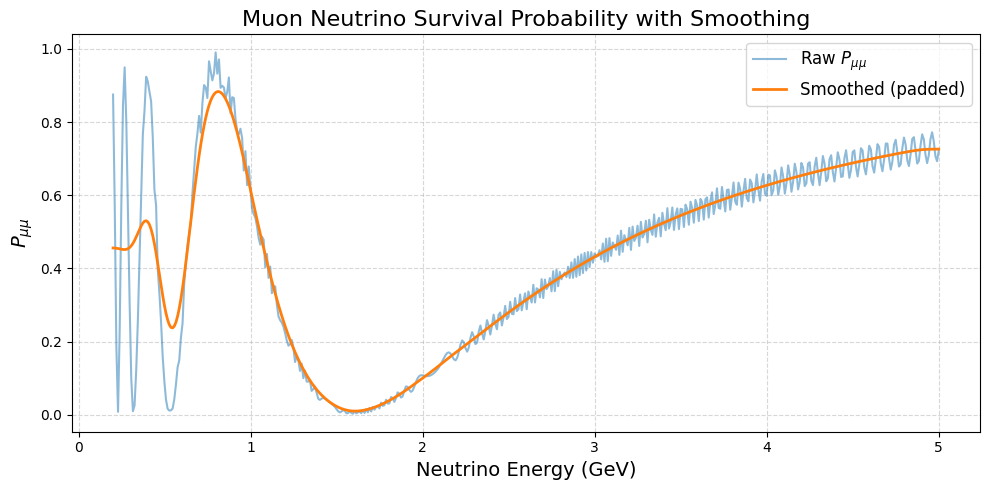

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Define energy range
energy_range = np.linspace(0.2, 5.0, 500)  # GeV

# Detector resolution target
fwhm_target_gev = 0.15  # NOvA ~0.15 GeV resolution
delta_E = energy_range[1] - energy_range[0]  # Bin width in GeV
sigma_gev = fwhm_target_gev / 2.355
sigma_bins = int(np.round(sigma_gev / delta_E))  # Convert to bin units
print(f"Using sigma_bins = {sigma_bins} for ~{fwhm_target_gev:.2f} GeV resolution")

# Smoothing with Padding
def smooth_with_padding(prob_array, sigma_bins):
    pad = 3 * sigma_bins
    padded = np.pad(prob_array, pad_width=pad, mode='reflect')
    smoothed = gaussian_filter1d(padded, sigma=sigma_bins)
    return smoothed[pad:-pad]

# Apply smoothing
prob_mm_smoothed = smooth_with_padding(prob_mm_vac, sigma_bins)

# Plot Comparison
plt.figure(figsize=(10, 5))
plt.plot(energy_range, prob_mm_vac, label="Raw $P_{\mu\mu}$", alpha=0.5)
plt.plot(energy_range, prob_mm_smoothed, label="Smoothed (padded)", linewidth=2)
plt.xlabel("Neutrino Energy (GeV)", fontsize=14)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
plt.title("Muon Neutrino Survival Probability with Smoothing", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


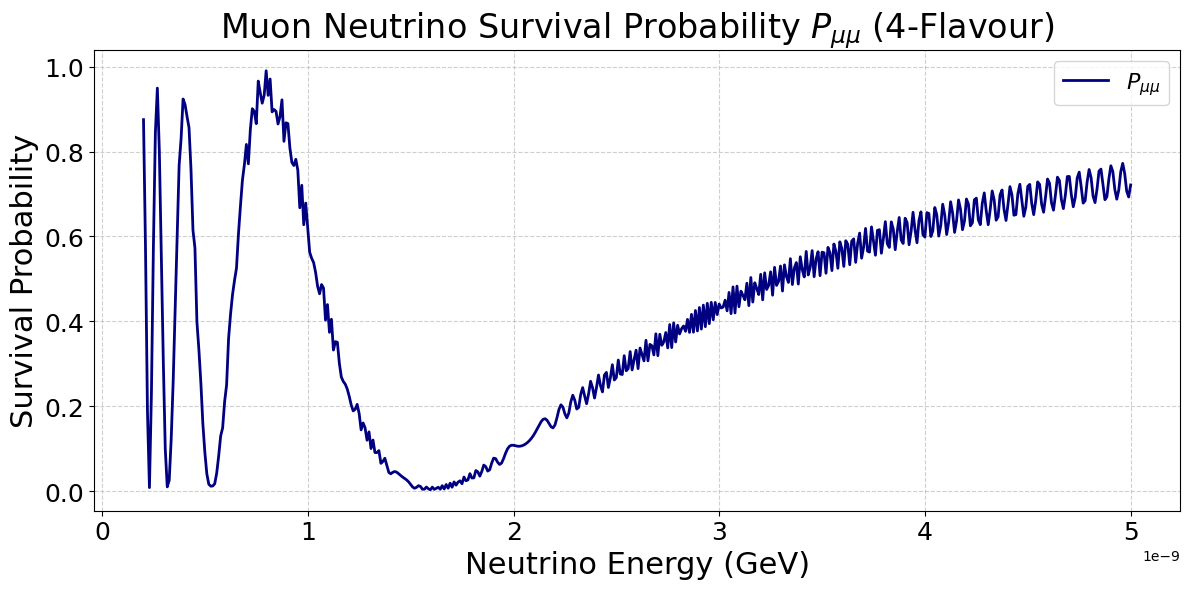

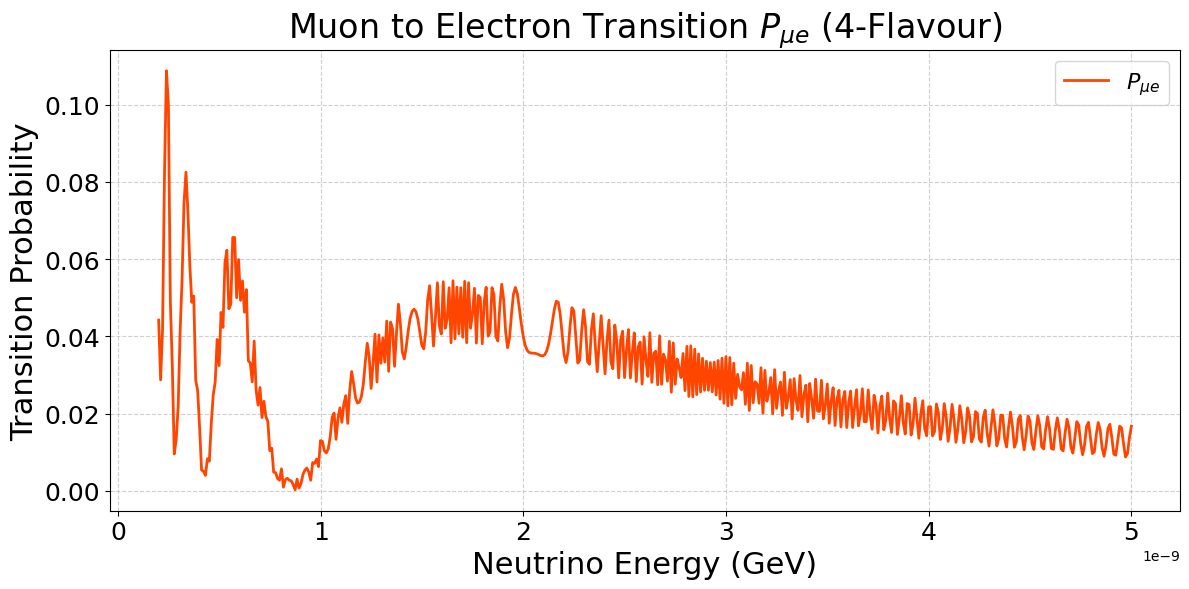

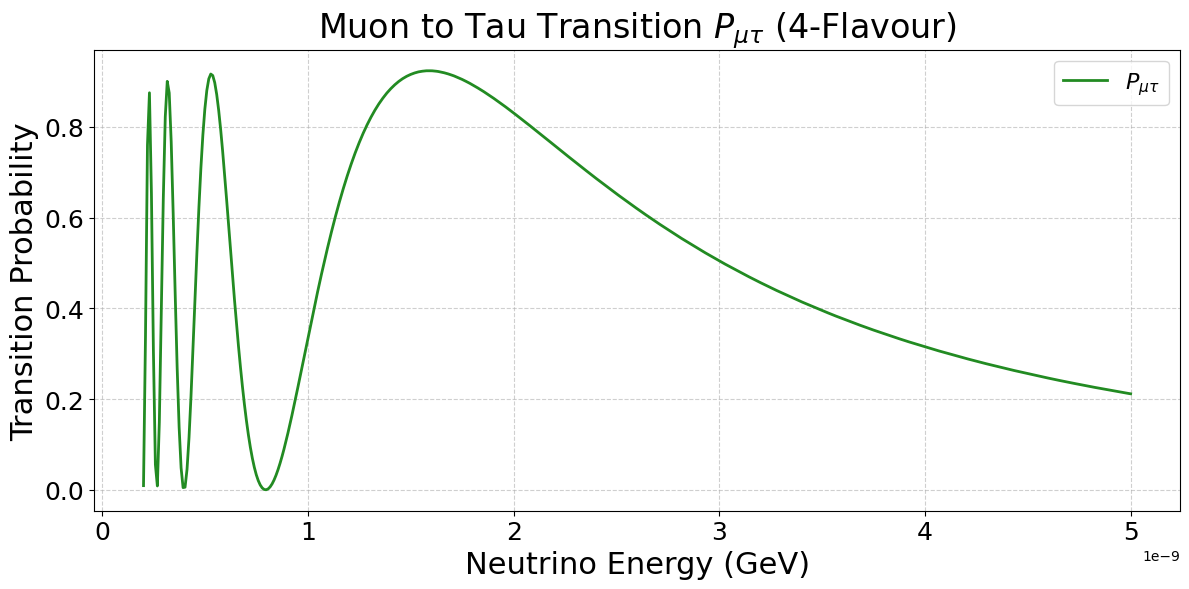

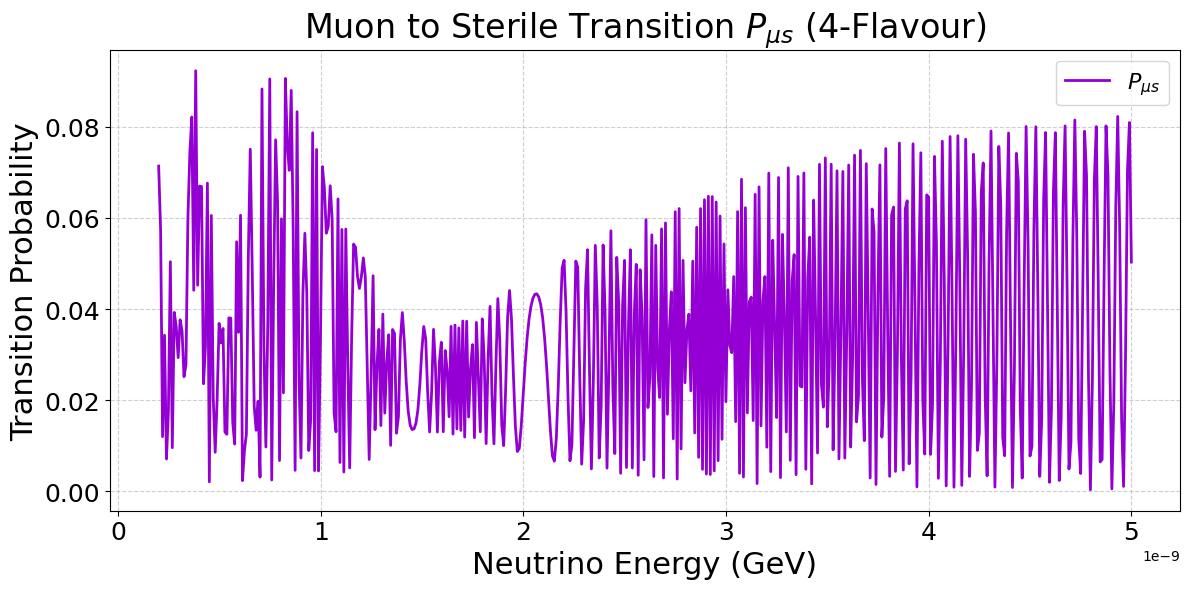

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(energy_range / 1e9, prob_mm_vac, '-', linewidth=2, color="navy", label=r"$P_{\mu\mu}$")

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Survival Probability", fontsize=22)
plt.title(r"Muon Neutrino Survival Probability $P_{\mu\mu}$ (4-Flavour)", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("pmm_4flavour_vacuum.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(energy_range / 1e9, prob_me_vac, '-', linewidth=2, color="orangered", label=r"$P_{\mu e}$")

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Transition Probability", fontsize=22)
plt.title(r"Muon to Electron Transition $P_{\mu e}$ (4-Flavour)", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("pme_4flavour_vacuum.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(energy_range / 1e9, prob_mt_vac, '-', linewidth=2, color="forestgreen", label=r"$P_{\mu \tau}$")

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Transition Probability", fontsize=22)
plt.title(r"Muon to Tau Transition $P_{\mu \tau}$ (4-Flavour)", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("pmt_4flavour_vacuum.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(energy_range / 1e9, prob_ms_vac, '-', linewidth=2, color="darkviolet", label=r"$P_{\mu s}$")

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Transition Probability", fontsize=22)
plt.title(r"Muon to Sterile Transition $P_{\mu s}$ (4-Flavour)", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("pms_4flavour_vacuum.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Continuous energy range
energy_range = np.linspace(0.2e9, 5e9, 500)

# Compute 4-flavour probabilities at Far Detector
prob_mm_vac_cont, prob_me_vac_cont, prob_mt_vac_cont, prob_ms_vac_cont = compute_probabilities(
    baseline=Length_far, energy_values=energy_range, matter=False)

prob_mm_mat_cont, prob_me_mat_cont, prob_mt_mat_cont, prob_ms_mat_cont = compute_probabilities(
    baseline=Length_far, energy_values=energy_range, matter=True)


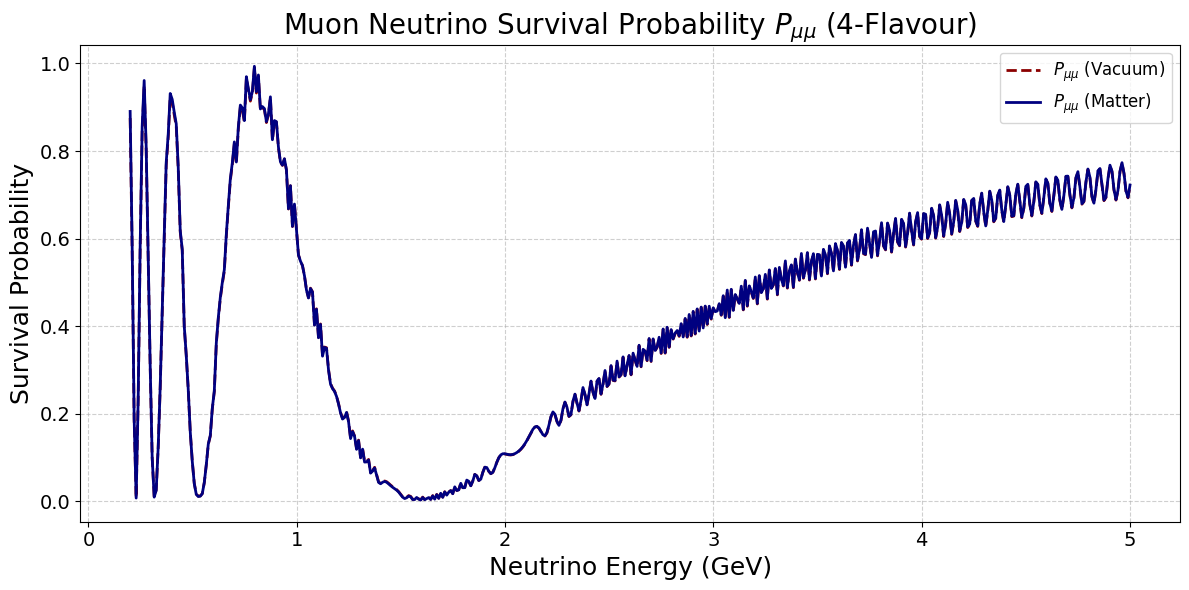

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(energy_range / 1e9, prob_mm_vac_cont, '--', color='darkred', linewidth=2, label=r"$P_{\mu\mu}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mm_mat_cont, '-', color='navy', linewidth=2, label=r"$P_{\mu\mu}$ (Matter)")

plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Survival Probability", fontsize=18)
plt.title(r"Muon Neutrino Survival Probability $P_{\mu\mu}$ (4-Flavour)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_pmm_vacuum_vs_matter_continuous.png", dpi=300, bbox_inches='tight')
plt.show()


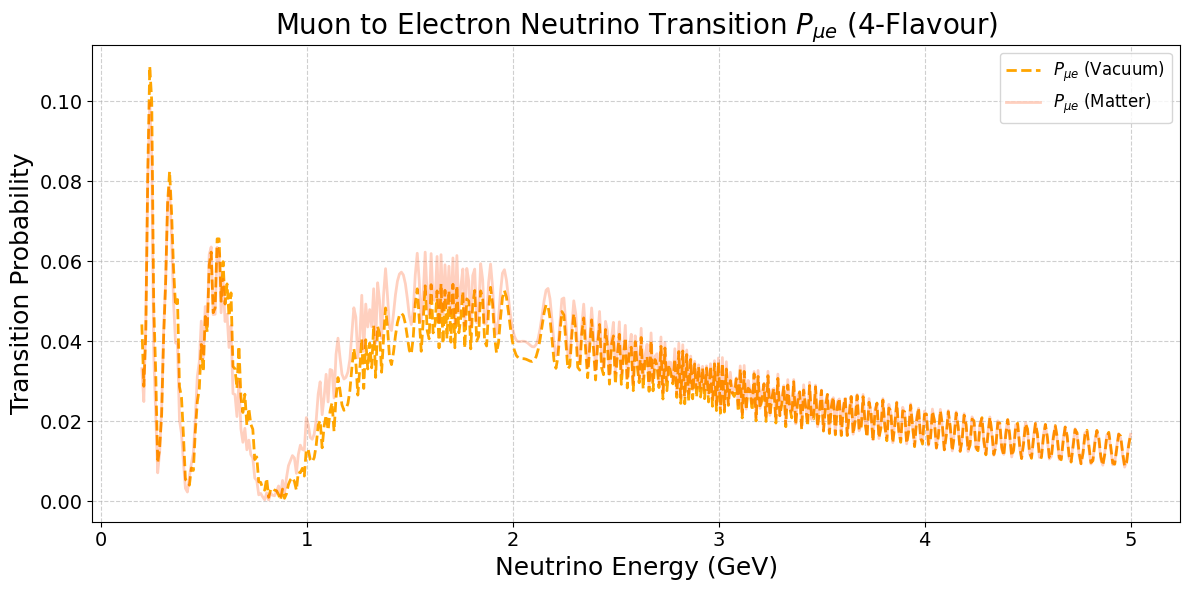

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(energy_range / 1e9, prob_me_vac_cont, '--', color='orange', linewidth=2, label=r"$P_{\mu e}$ (Vacuum)", )
plt.plot(energy_range / 1e9, prob_me_mat_cont, '-', color='orangered', linewidth=2, label=r"$P_{\mu e}$ (Matter)", alpha =0.25)

plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Transition Probability", fontsize=18)
plt.title(r"Muon to Electron Neutrino Transition $P_{\mu e}$ (4-Flavour)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_pme_vacuum_vs_matter_continuous.png", dpi=300, bbox_inches='tight')
plt.show()


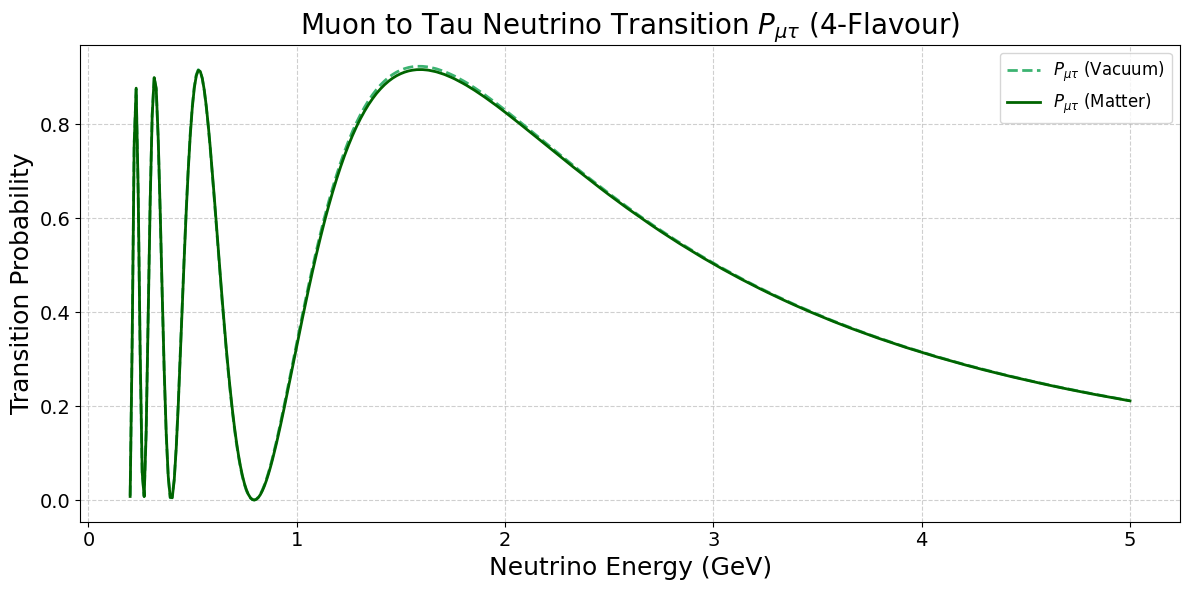

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(energy_range / 1e9, prob_mt_vac_cont, '--', color='mediumseagreen', linewidth=2, label=r"$P_{\mu\tau}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mt_mat_cont, '-', color='darkgreen', linewidth=2, label=r"$P_{\mu\tau}$ (Matter)")

plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Transition Probability", fontsize=18)
plt.title(r"Muon to Tau Neutrino Transition $P_{\mu\tau}$ (4-Flavour)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_pmt_vacuum_vs_matter_continuous.png", dpi=300, bbox_inches='tight')
plt.show()


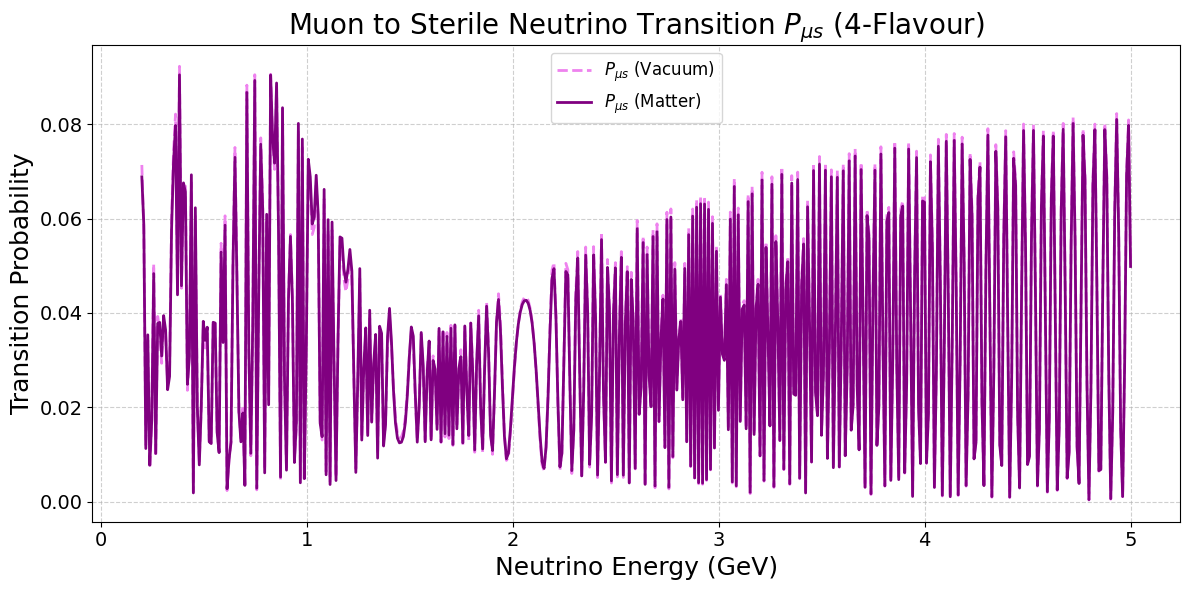

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(energy_range / 1e9, prob_ms_vac_cont, '--', color='violet', linewidth=2, label=r"$P_{\mu s}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_ms_mat_cont, '-', color='purple', linewidth=2, label=r"$P_{\mu s}$ (Matter)")

plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Transition Probability", fontsize=18)
plt.title(r"Muon to Sterile Neutrino Transition $P_{\mu s}$ (4-Flavour)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_pms_vacuum_vs_matter_continuous.png", dpi=300, bbox_inches='tight')
plt.show()


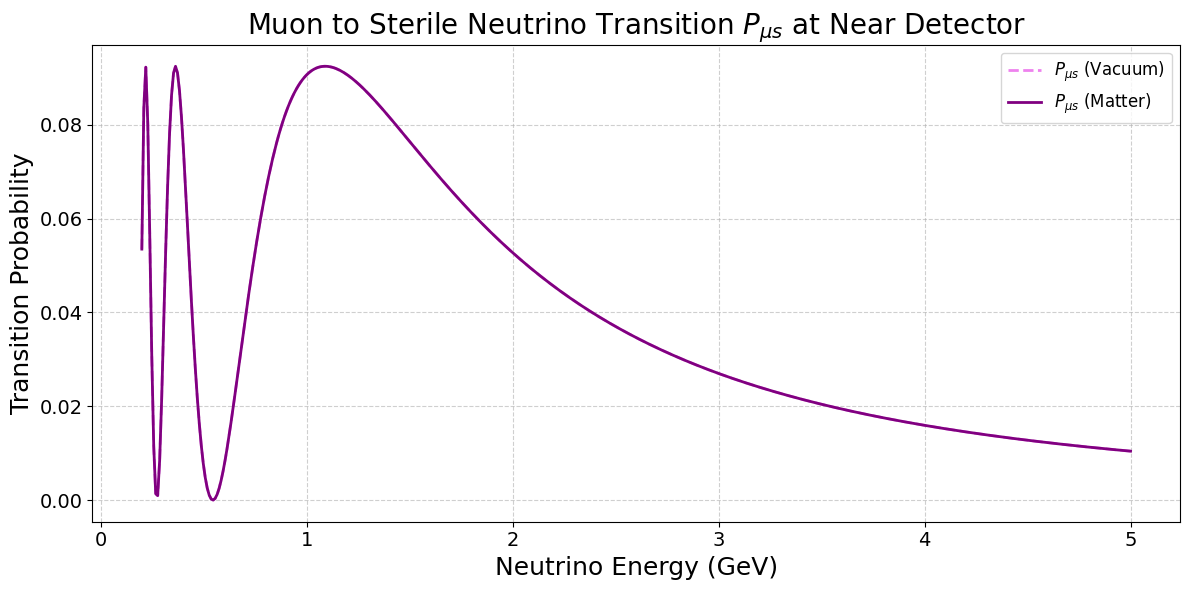

In [ ]:
# Compute probabilities at the Near Detector (L = 1 km)
prob_mm_near_vac, prob_me_near_vac, prob_mt_near_vac, prob_ms_near_vac = compute_probabilities(
    baseline=Length_near, energy_values=energy_range, matter=False)

prob_mm_near_mat, prob_me_near_mat, prob_mt_near_mat, prob_ms_near_mat = compute_probabilities(
    baseline=Length_near, energy_values=energy_range, matter=True)

# Plot the muon to sterile transition probability
plt.figure(figsize=(12, 6))
plt.plot(energy_range / 1e9, prob_ms_near_vac, '--', color='violet', linewidth=2, label=r"$P_{\mu s}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_ms_near_mat, '-', color='purple', linewidth=2, label=r"$P_{\mu s}$ (Matter)")

plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Transition Probability", fontsize=18)
plt.title(r"Muon to Sterile Neutrino Transition $P_{\mu s}$ at Near Detector", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_pms_vacuum_vs_matter_near.png", dpi=300, bbox_inches='tight')
plt.show()


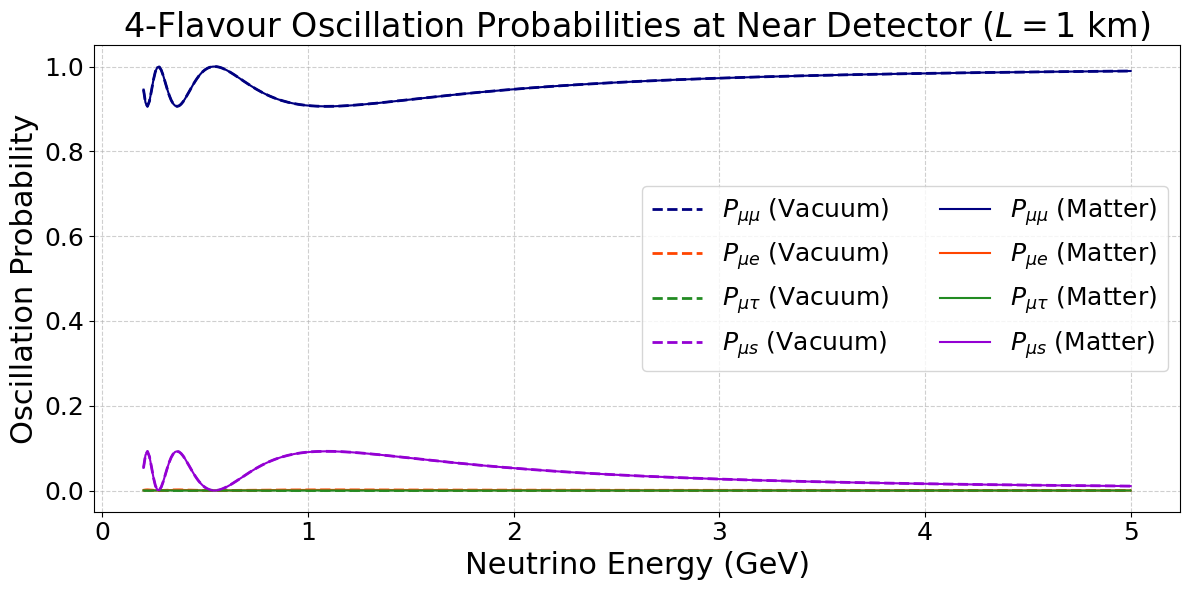

In [ ]:
# Compute 4-flavour oscillation probabilities at the Near Detector
prob_mm_near_vac, prob_me_near_vac, prob_mt_near_vac, prob_ms_near_vac = compute_probabilities(
    baseline=Length_near, energy_values=energy_range, matter=False)

prob_mm_near_mat, prob_me_near_mat, prob_mt_near_mat, prob_ms_near_mat = compute_probabilities(
    baseline=Length_near, energy_values=energy_range, matter=True)

# Plot
plt.figure(figsize=(12, 6))

# Survival and transition probabilities - Vacuum
plt.plot(energy_range / 1e9, prob_mm_near_vac, '--', linewidth=2, color='navy', label=r"$P_{\mu\mu}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_me_near_vac, '--', linewidth=2, color='orangered', label=r"$P_{\mu e}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mt_near_vac, '--', linewidth=2, color='forestgreen', label=r"$P_{\mu \tau}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_ms_near_vac, '--', linewidth=2, color='darkviolet', label=r"$P_{\mu s}$ (Vacuum)")

# Survival and transition probabilities - Matter
plt.plot(energy_range / 1e9, prob_mm_near_mat, '-', linewidth=1.5, color='navy', label=r"$P_{\mu\mu}$ (Matter)")
plt.plot(energy_range / 1e9, prob_me_near_mat, '-', linewidth=1.5, color='orangered', label=r"$P_{\mu e}$ (Matter)")
plt.plot(energy_range / 1e9, prob_mt_near_mat, '-', linewidth=1.5, color='forestgreen', label=r"$P_{\mu \tau}$ (Matter)")
plt.plot(energy_range / 1e9, prob_ms_near_mat, '-', linewidth=1.5, color='darkviolet', label=r"$P_{\mu s}$ (Matter)")

# Formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Oscillation Probability", fontsize=22)
plt.title(r"4-Flavour Oscillation Probabilities at Near Detector ($L=1$ km)", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18, ncol=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_probabilities_near_detector_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
print(np.max(prob_ms_near_mat))
print(np.min(prob_ms_near_mat))

print(np.max(prob_mm_near_mat))
print(np.min(prob_mm_near_mat))

print(np.max(prob_mt_near_mat))
print(np.min(prob_mt_near_mat))

print(np.max(prob_me_near_mat))
print(np.min(prob_me_near_mat))

print(np.average(prob_ms_near_mat))

0.09249767430144905
5.292469850047768e-06
0.9999642580492845
0.9059779183741006
0.00021840484049765404
3.692366702927419e-07
0.0014722093244054408
1.0819656737464434e-06
0.038834362448199405


In [ ]:
from google.colab import files
files.download('4flavour_probabilities_near_detector_vacuum_vs_matter.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

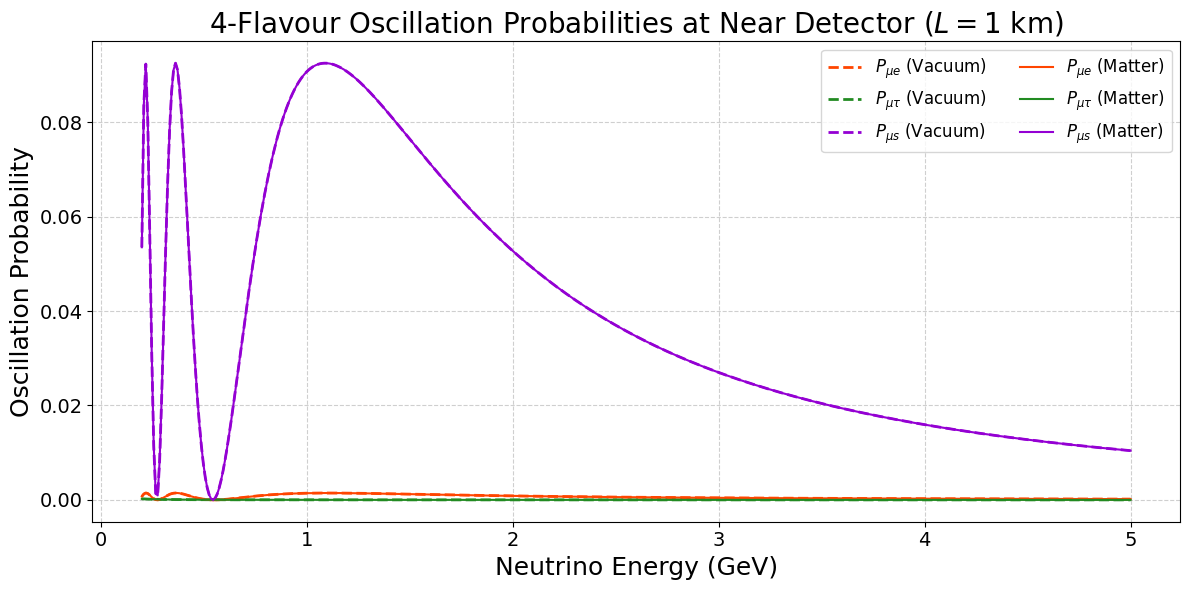

In [ ]:
plt.figure(figsize=(12, 6))

# Survival and transition probabilities - Vacuum

plt.plot(energy_range / 1e9, prob_me_near_vac, '--', linewidth=2, color='orangered', label=r"$P_{\mu e}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mt_near_vac, '--', linewidth=2, color='forestgreen', label=r"$P_{\mu \tau}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_ms_near_vac, '--', linewidth=2, color='darkviolet', label=r"$P_{\mu s}$ (Vacuum)")

# Survival and transition probabilities - Matter

plt.plot(energy_range / 1e9, prob_me_near_mat, '-', linewidth=1.5, color='orangered', label=r"$P_{\mu e}$ (Matter)")
plt.plot(energy_range / 1e9, prob_mt_near_mat, '-', linewidth=1.5, color='forestgreen', label=r"$P_{\mu \tau}$ (Matter)")
plt.plot(energy_range / 1e9, prob_ms_near_mat, '-', linewidth=1.5, color='darkviolet', label=r"$P_{\mu s}$ (Matter)")

# Formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Oscillation Probability", fontsize=18)
plt.title(r"4-Flavour Oscillation Probabilities at Near Detector ($L=1$ km)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12, ncol=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_probabilities_near_detector_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()

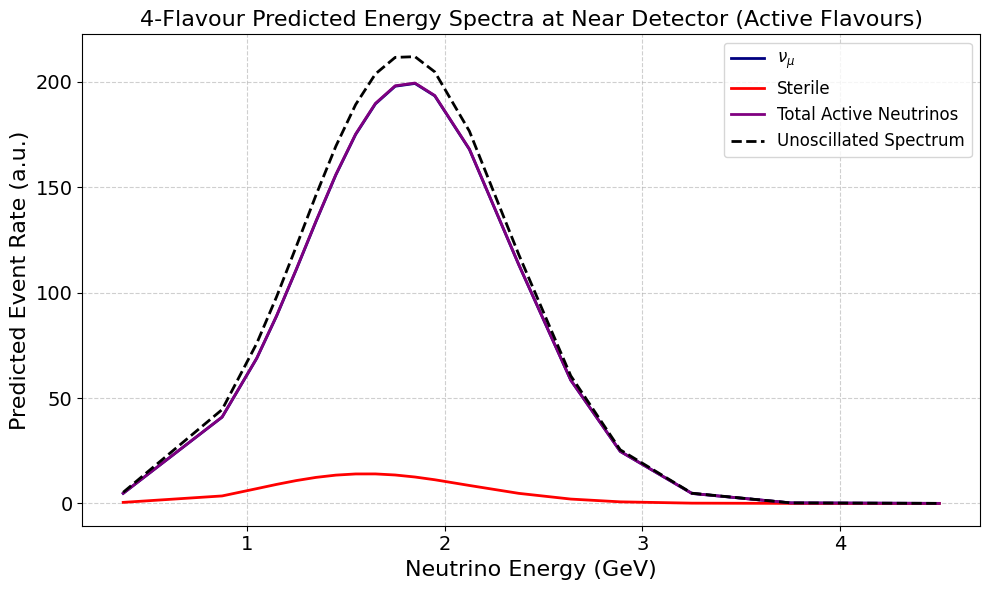

In [ ]:
from scipy.interpolate import interp1d

# Interpolate 4-flavour vacuum probabilities at bin_centers
interp_mm = interp1d(energy_range, prob_mm_near_vac, kind='linear')
interp_me = interp1d(energy_range, prob_me_near_vac, kind='linear')
interp_mt = interp1d(energy_range, prob_mt_near_vac, kind='linear')
interp_ms = interp1d(energy_range, prob_ms_near_vac, kind='linear')

#Evaluate interpolated probabilities at bin centers
prob_mm_bins = interp_mm(bin_centers)
prob_me_bins = interp_me(bin_centers)
prob_mt_bins = interp_mt(bin_centers)
prob_ms_bins = interp_ms(bin_centers)



#Get unoscillated input spectrum
gaussian_flux = gaussian(bin_centers, *popt_nd)

# Compute predicted spectra for each active flavour
spectrum_mu = gaussian_flux * prob_mm_bins
spectrum_e  = gaussian_flux * prob_me_bins
spectrum_tau = gaussian_flux * prob_mt_bins
spectrum_ms = gaussian_flux * prob_ms_bins
spectrum_all = spectrum_mu + spectrum_e + spectrum_tau

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(bin_centers / 1e9, spectrum_mu, color='navy', label=r"$\nu_\mu$", linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_ms, color='red', label=r"Sterile", linewidth=2)
#plt.plot(bin_centers / 1e9, spectrum_e, color='orangered', label=r"$\nu_e$", linewidth=2)
#plt.plot(bin_centers / 1e9, spectrum_tau, color='forestgreen', label=r"$\nu_\tau$", linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_all, color='purple', linestyle='-', linewidth=2, label='Total Active Neutrinos')
plt.plot(bin_centers / 1e9, gaussian_flux, 'k--', linewidth=2, label='Unoscillated Spectrum')

plt.xlabel("Neutrino Energy (GeV)", fontsize=16)
plt.ylabel("Predicted Event Rate (a.u.)", fontsize=16)
plt.title("4-Flavour Predicted Energy Spectra at Near Detector (Active Flavours)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("4flavour_near_detector_energy_spectra.png", dpi=300, bbox_inches='tight')
plt.show()


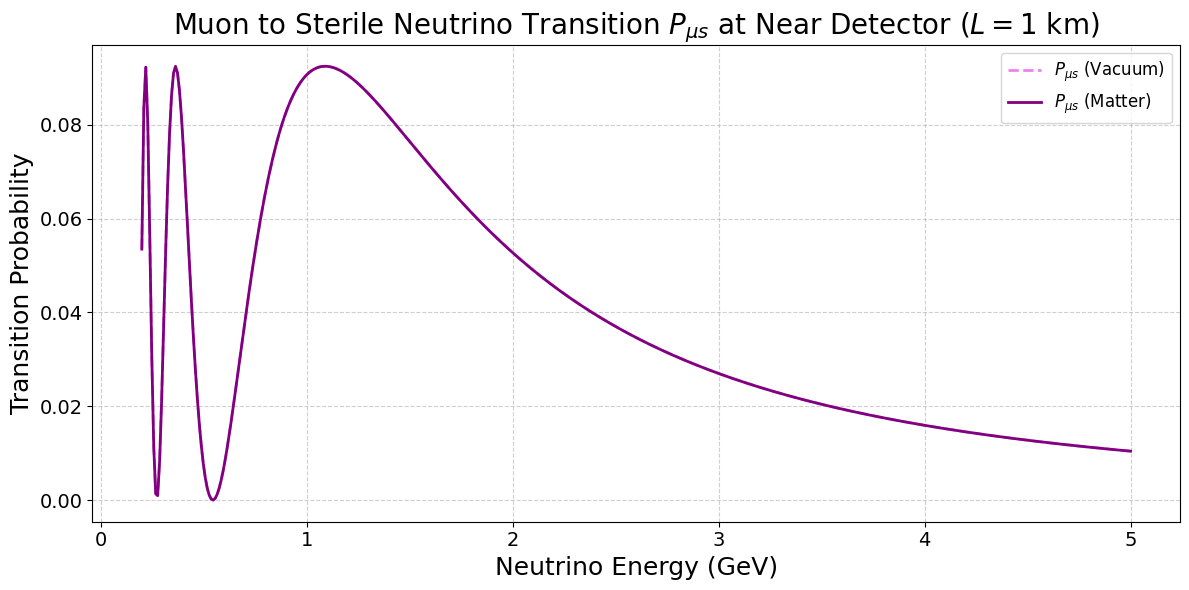

In [ ]:
# Compute P_{μs} at Near Detector for vacuum and matter
_, _, _, prob_ms_near_vac = compute_probabilities(Length_near, energy_range, matter=False)
_, _, _, prob_ms_near_mat = compute_probabilities(Length_near, energy_range, matter=True)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(energy_range / 1e9, prob_ms_near_vac, '--', color='violet', linewidth=2, label=r"$P_{\mu s}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_ms_near_mat, '-', color='purple', linewidth=2, label=r"$P_{\mu s}$ (Matter)")

# Formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Transition Probability", fontsize=18)
plt.title(r"Muon to Sterile Neutrino Transition $P_{\mu s}$ at Near Detector ($L = 1$ km)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("pms_near_detector_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()


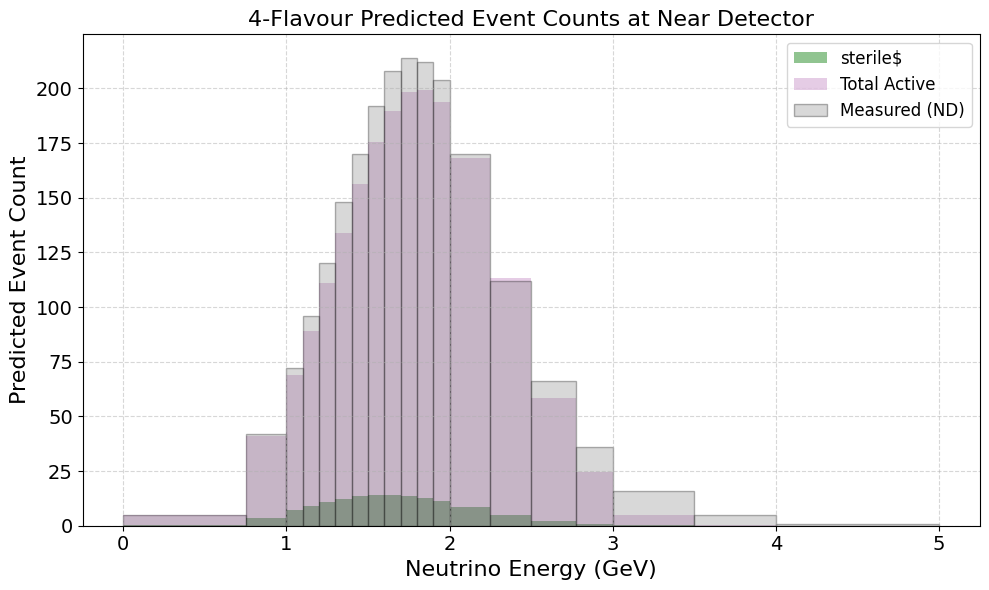

In [ ]:

pred_counts_mu = gaussian_flux * prob_mm_bins
pred_counts_e  = gaussian_flux * prob_me_bins
pred_counts_tau = gaussian_flux * prob_mt_bins
pred_counts_tau = gaussian_flux * prob_mt_bins
pred_counts_s = gaussian_flux * prob_ms_bins
pred_counts_total = pred_counts_mu + pred_counts_e + pred_counts_tau

plt.figure(figsize=(10, 6))

#plt.bar(bin_centers / 1e9, pred_counts_mu, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='navy', label=r"$\nu_\mu$")
#plt.bar(bin_centers / 1e9, pred_counts_e, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='orangered', label=r"$\nu_e$")
#plt.bar(bin_centers / 1e9, pred_counts_tau, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"$\nu_\tau$")
plt.bar(bin_centers / 1e9, pred_counts_s, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"sterile$")
plt.bar(bin_centers / 1e9, pred_counts_total, width=np.diff(bin_edges) / 1e9, alpha=0.2, color='purple', label='Total Active')
plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, alpha=0.3, color='gray', label='Measured (ND)', edgecolor='black')

plt.xlabel("Neutrino Energy (GeV)", fontsize=16)
plt.ylabel("Predicted Event Count", fontsize=16)
plt.title("4-Flavour Predicted Event Counts at Near Detector", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("4flavour_near_detector_predicted_histograms.png", dpi=300, bbox_inches='tight')
plt.show()


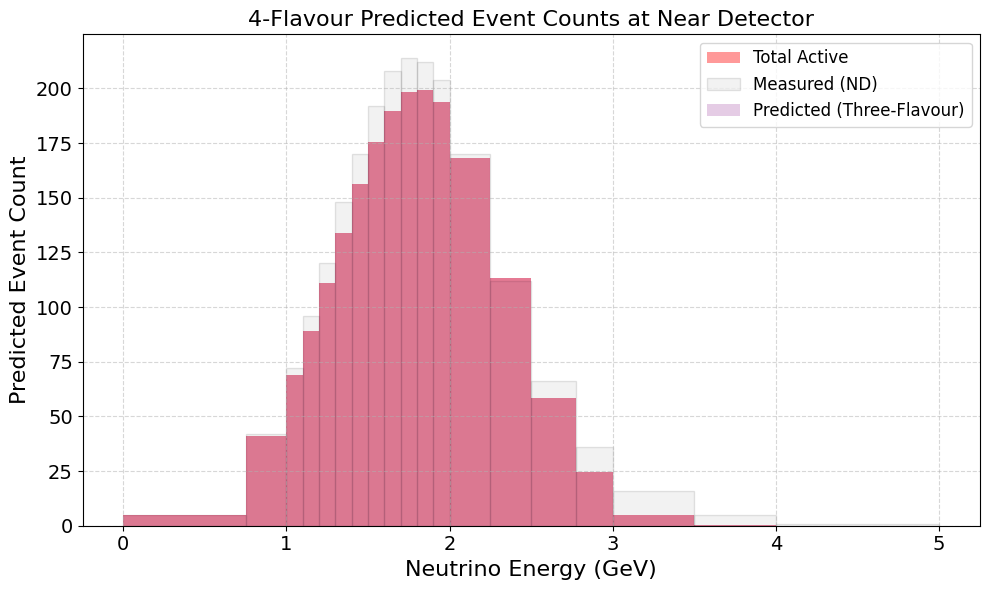

In [ ]:

plt.figure(figsize=(10, 6))

#plt.bar(bin_centers / 1e9, pred_counts_mu, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='navy', label=r"$\nu_\mu$")
#plt.bar(bin_centers / 1e9, pred_counts_e, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='orangered', label=r"$\nu_e$")
#plt.bar(bin_centers / 1e9, pred_counts_tau, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"$\nu_\tau$")
plt.bar(bin_centers / 1e9, pred_counts_total, width=np.diff(bin_edges) / 1e9, alpha=0.4, color='red', label='Total Active')
plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, alpha=0.1, color='gray', label='Measured (ND)', edgecolor='black')
# Predicted (3-flavour) total active
plt.bar(bin_centers / 1e9, spectrum_all, width=np.diff(bin_edges) / 1e9, alpha=0.2, color='purple', label='Predicted (Three-Flavour)'
)

plt.xlabel("Neutrino Energy (GeV)", fontsize=16)
plt.ylabel("Predicted Event Count", fontsize=16)
plt.title("4-Flavour Predicted Event Counts at Near Detector", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("4flavour_near_detector_predicted_histograms.png", dpi=300, bbox_inches='tight')
plt.show()

<BarContainer object of 19 artists>

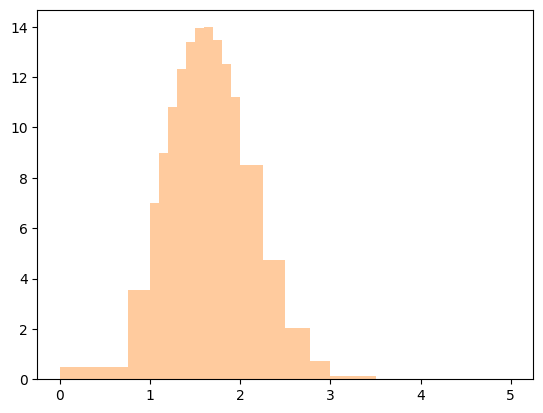

In [ ]:
residual =  pred_counts_total - spectrum_all
plt.bar(bin_centers / 1e9, residual,width=np.diff(bin_edges) / 1e9, alpha=0.8, label='Measured - Active Prediction')
plt.bar(bin_centers / 1e9, pred_counts_s,width=np.diff(bin_edges) / 1e9, alpha=0.4, label='Sterile Prediction')


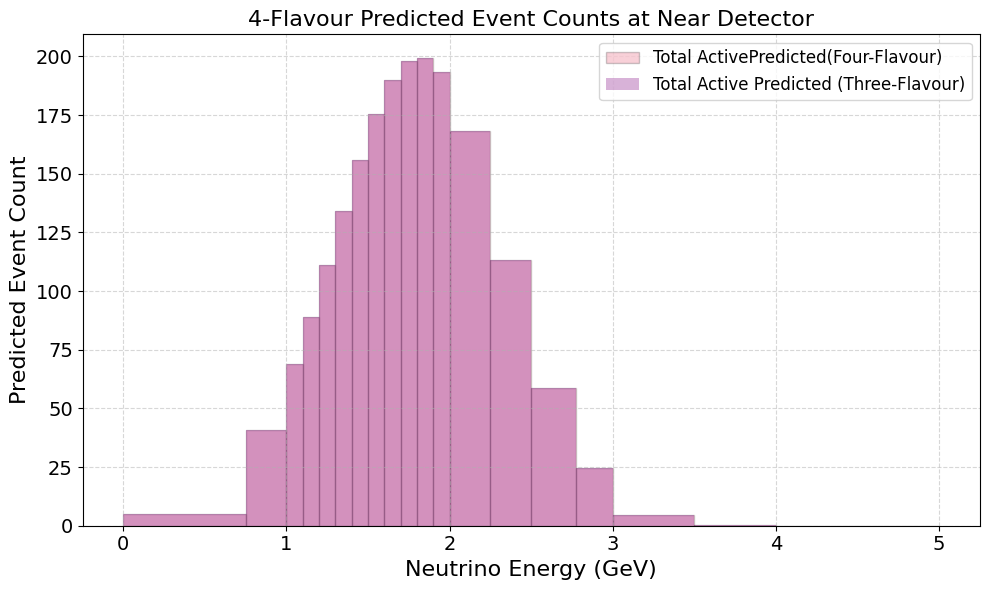

In [ ]:

plt.figure(figsize=(10, 6))

#plt.bar(bin_centers / 1e9, pred_counts_mu, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='navy', label=r"$\nu_\mu$")
#plt.bar(bin_centers / 1e9, pred_counts_e, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='orangered', label=r"$\nu_e$")
#plt.bar(bin_centers / 1e9, pred_counts_tau, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"$\nu_\tau$")
plt.bar(bin_centers / 1e9, pred_counts_total, width=np.diff(bin_edges) / 1e9, alpha=0.2, color='crimson', label='Total ActivePredicted(Four-Flavour)', edgecolor='black')
#plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, alpha=0.1, color='gray', label='Measured (ND)', edgecolor='black')
# Predicted (3-flavour) total active
plt.bar(bin_centers / 1e9, spectrum_all, width=np.diff(bin_edges) / 1e9, alpha=0.3, color='purple', label='Total Active Predicted (Three-Flavour)'
)

plt.xlabel("Neutrino Energy (GeV)", fontsize=16)
plt.ylabel("Predicted Event Count", fontsize=16)
plt.title("4-Flavour Predicted Event Counts at Near Detector", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("4flavour_near_detector_predicted_histograms.png", dpi=300, bbox_inches='tight')
plt.show()

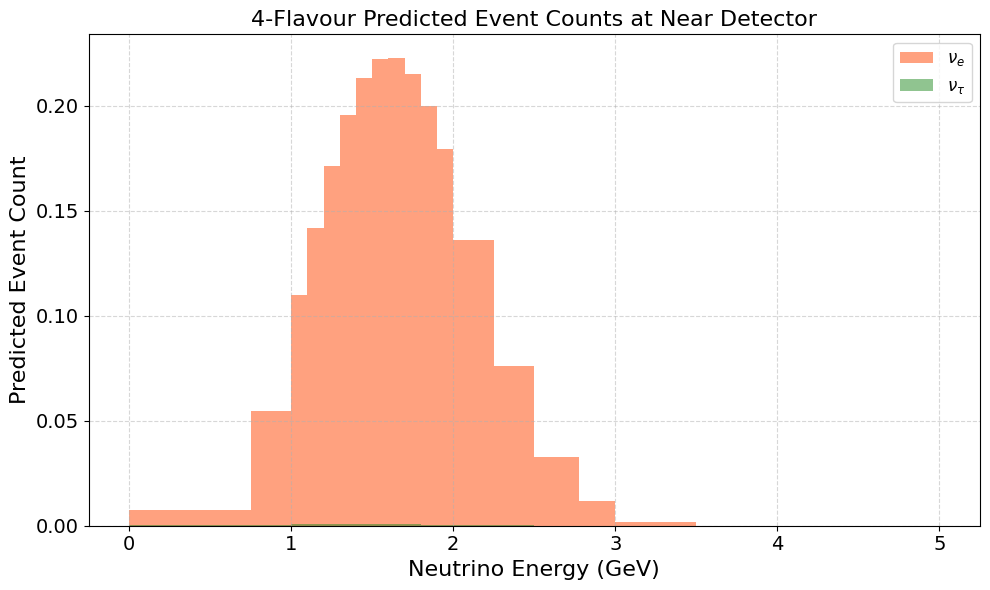

In [ ]:

pred_counts_mu = gaussian_flux * prob_mm_bins
pred_counts_e  = gaussian_flux * prob_me_bins
pred_counts_tau = gaussian_flux * prob_mt_bins
pred_counts_total = pred_counts_mu + pred_counts_e + pred_counts_tau

plt.figure(figsize=(10, 6))

#plt.bar(bin_centers / 1e9, pred_counts_mu, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='navy', label=r"$\nu_\mu$")
plt.bar(bin_centers / 1e9, pred_counts_e, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='orangered', label=r"$\nu_e$")
plt.bar(bin_centers / 1e9, pred_counts_tau, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"$\nu_\tau$")
plt.bar(bin_centers / 1e9, pred_counts_tau, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='blue', label=r"$\nu_\s$")
#plt.bar(bin_centers / 1e9, pred_counts_total, width=np.diff(bin_edges) / 1e9, alpha=0.2, color='purple', label='Total Active')
#plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, alpha=0.3, color='gray', label='Measured (ND)', edgecolor='black')

plt.xlabel("Neutrino Energy (GeV)", fontsize=16)
plt.ylabel("Predicted Event Count", fontsize=16)
plt.title("4-Flavour Predicted Event Counts at Near Detector", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("4flavour_near_detector_predicted_histograms.png", dpi=300, bbox_inches='tight')
plt.show()


Parameter set Comparison

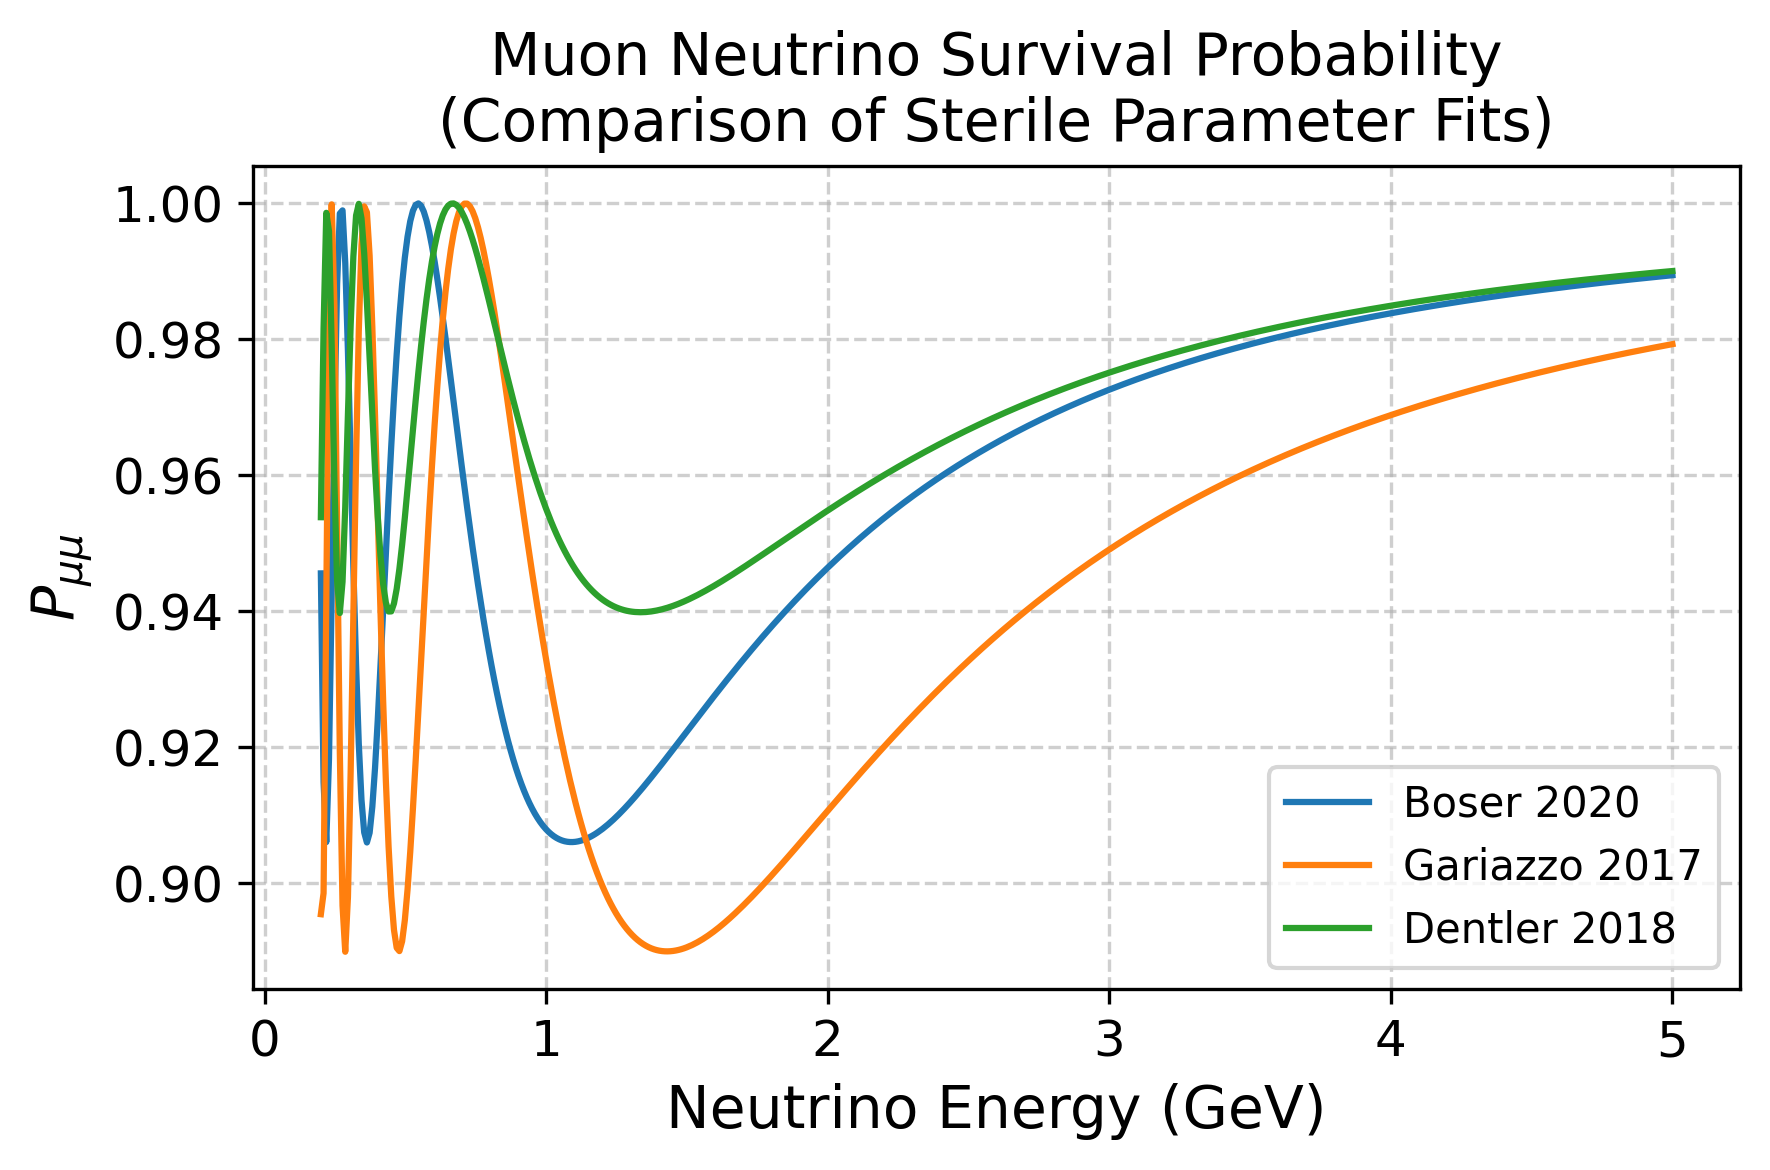

In [ ]:
# Re-import necessary libraries after kernel reset
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Constants
CONV_KM_TO_INV_EV = 5.067731e9  # Conversion factor from km to inverse eV
VCC_EARTH_CRUST = 7.6e-14  # Matter potential in eV
Length_near = 1  # Near detector baseline in km
energy_values = np.linspace(0.2e9, 5e9, 500)  # Neutrino energies from 0.2 to 5 GeV in eV

# Define mixing matrix for 4-neutrino model
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12 * c13 * c14, s12 * c13 * c14, s13 * c14 * np.exp(-1j * delta13), s14 * np.exp(-1j * delta14)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta13),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta13),
         c13 * s23,
         s24 * c13],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta13),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta13),
         c13 * c23,
         c24 * s34],
        [0, 0, 0, c34]
    ])
    return U

# Define Hamiltonian
def hamiltonian_4nu(theta_set, delta13, delta14, mass_sq):
    theta12, theta13, theta23, theta14, theta24, theta34 = np.radians(theta_set)
    D21, D31, D41 = mass_sq
    m2_diag = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, np.radians(delta13), np.radians(delta14))
    return lambda E: U @ m2_diag @ np.conj(U.T) / (2 * E)

# Compute muon survival probability
def compute_Pmm(theta_set, delta13, delta14, mass_sq):
    H_func = hamiltonian_4nu(theta_set, delta13, delta14, mass_sq)
    Pmm = []
    for E in energy_values:
        H = H_func(E)
        S = expm(-1j * H * Length_near * CONV_KM_TO_INV_EV)
        Pmm.append(np.abs(S[1, 1])**2)
    return np.array(Pmm)

# Parameter sets from different global fits
param_sets = {
    "Boser 2020": ([33.82, 8.61, 48.3, 7.2, 9.2, 0.0], 0, 0, [7.39e-5, 2.525e-3, 1.3]),
    "Gariazzo 2017": ([33.82, 8.61, 48.3, 6.7, 10.0, 0.0], 0, 0, [7.39e-5, 2.525e-3, 1.7]),
    "Dentler 2018": ([33.82, 8.61, 48.3, 8.1, 7.3, 0.0], 0, 0, [7.39e-5, 2.525e-3, 1.6])
}

# Plotting
plt.figure(figsize=(6, 4), dpi=300)
for label, (theta_set, delta13, delta14, mass_sq) in param_sets.items():
    Pmm = compute_Pmm(theta_set, delta13, delta14, mass_sq)
    plt.plot(energy_values / 1e9, Pmm, label=label)

plt.xlabel("Neutrino Energy (GeV)", fontsize=14)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
plt.title("Muon Neutrino Survival Probability\n(Comparison of Sterile Parameter Fits)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

plt.savefig("sterile_param_comparison_pmm.png", bbox_inches='tight')
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

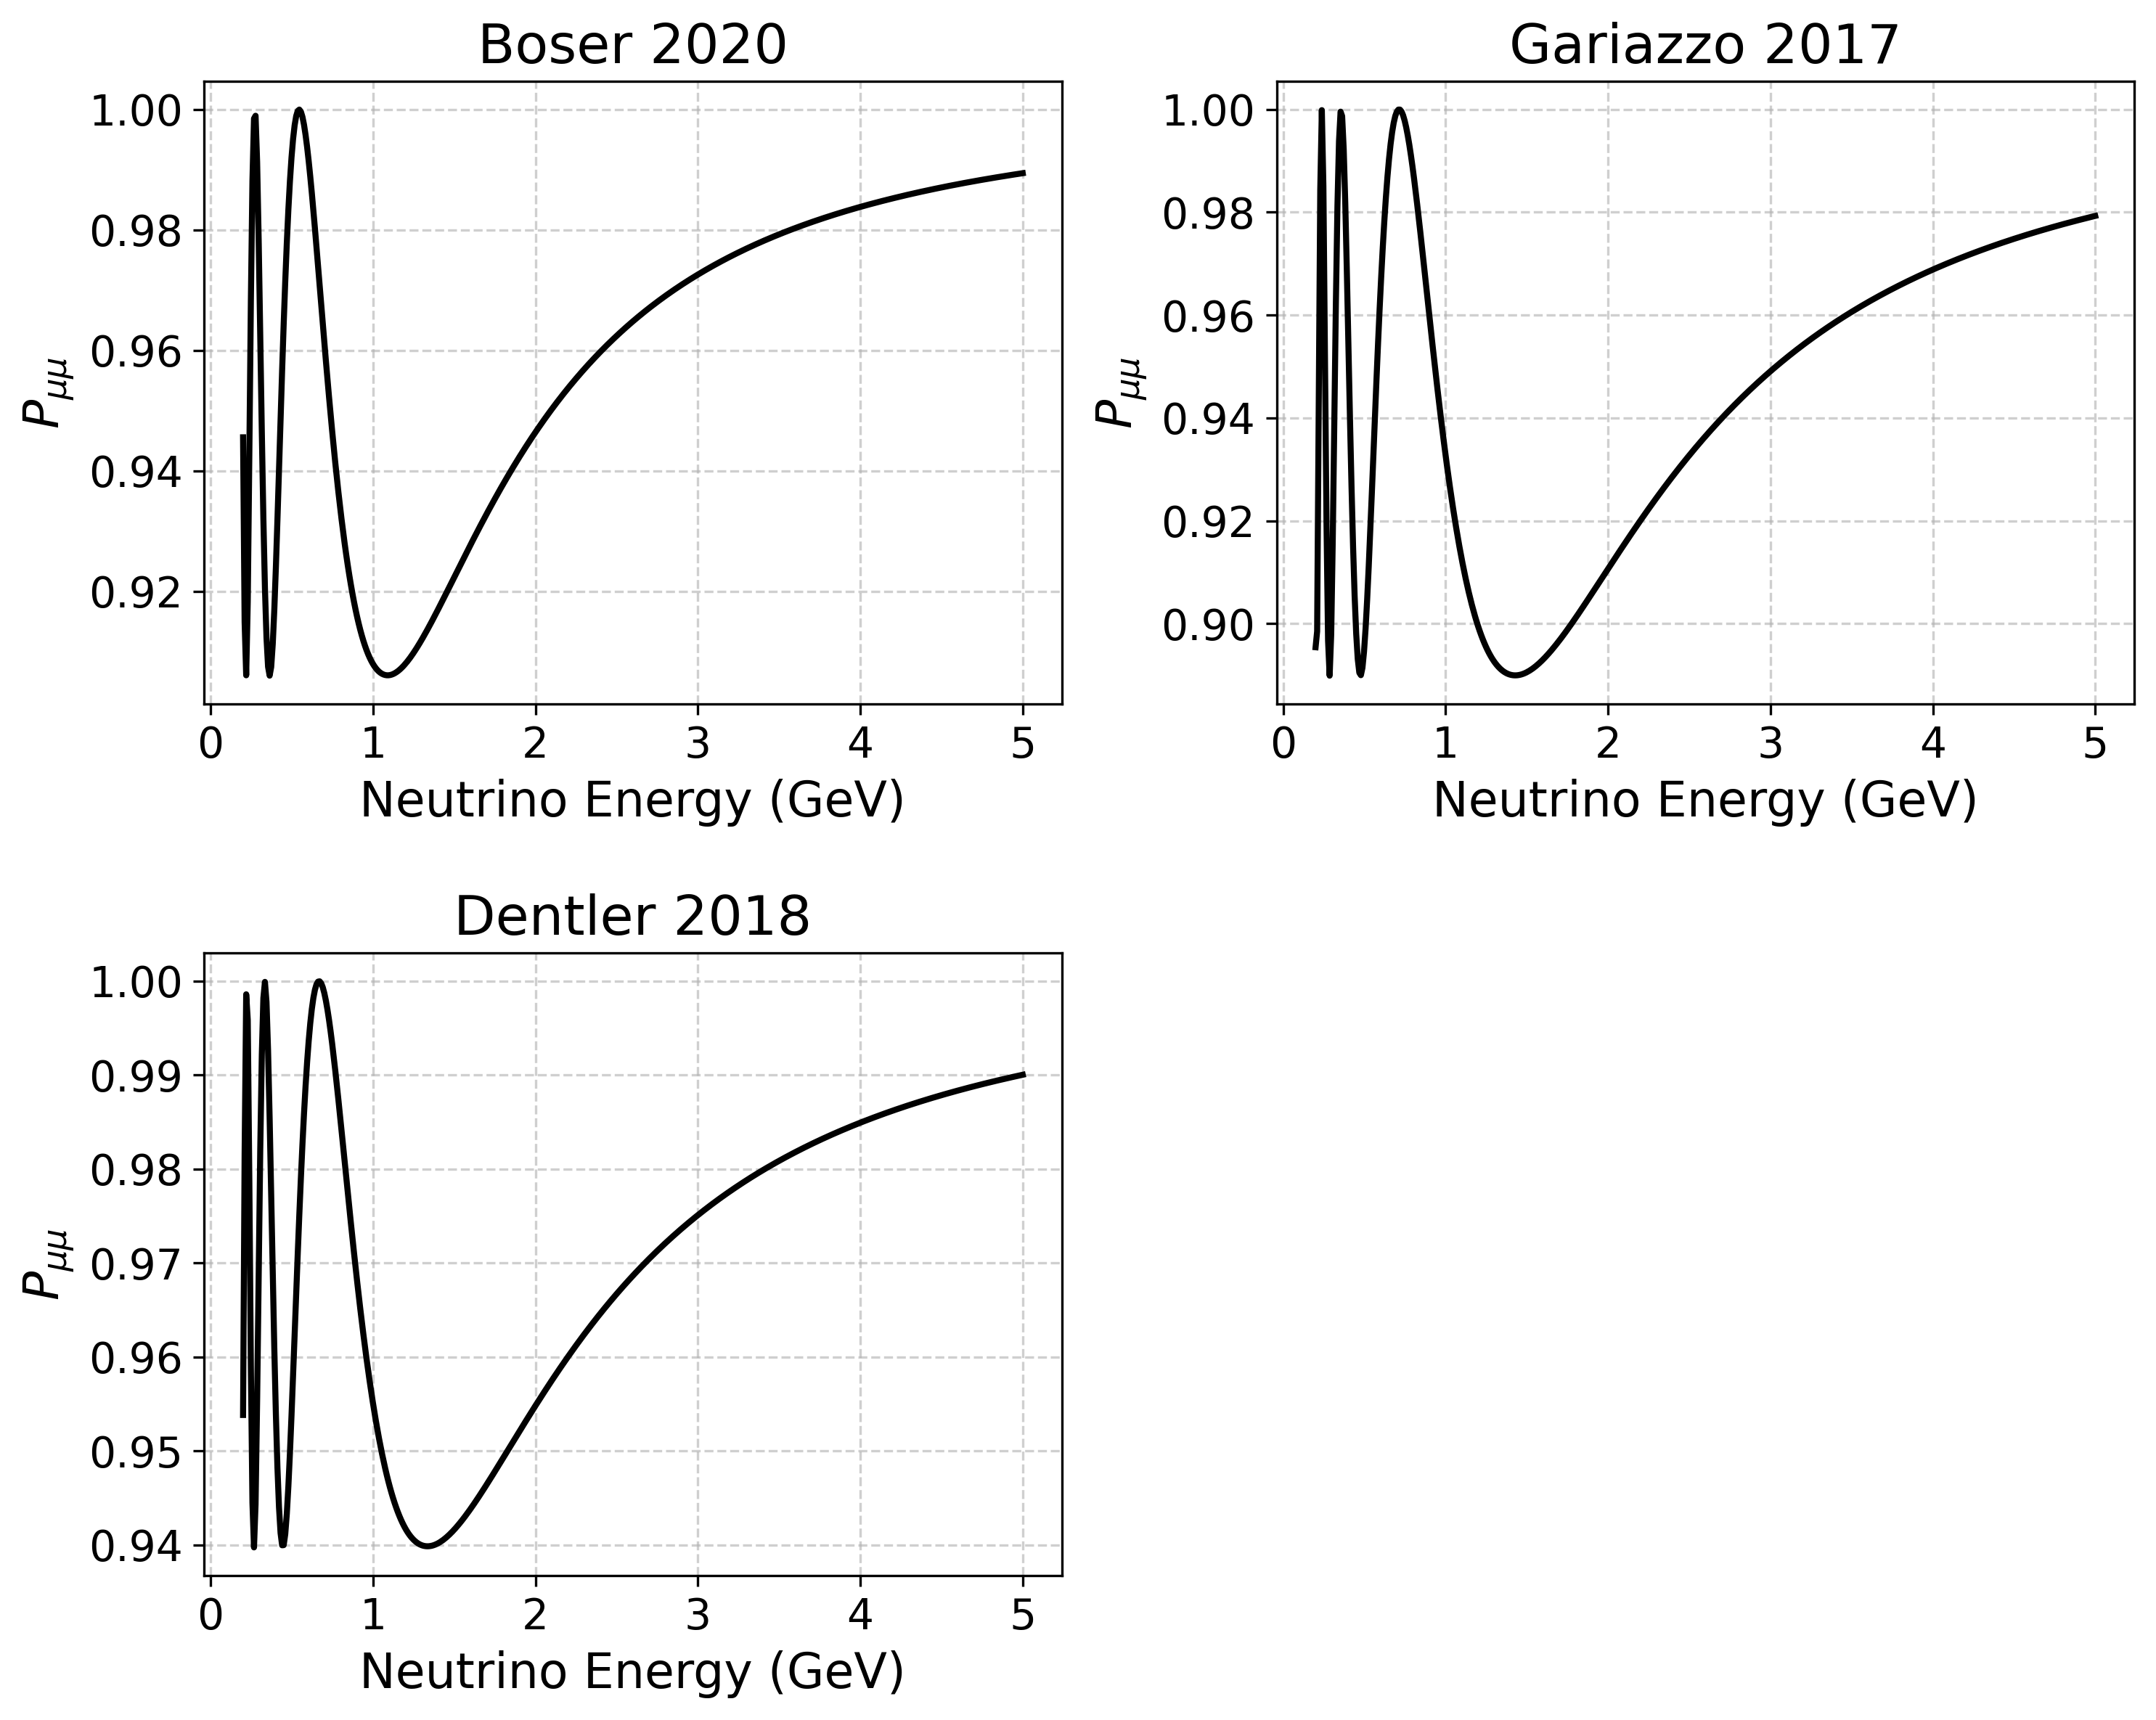

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# Updated layout style
plot_kwargs = {
    "figsize": (10, 8),  # Taller layout for 2x1
    "dpi": 300
}

font_kwargs = {
    "xlabel": "Neutrino Energy (GeV)",
    "ylabel": r"$P_{\mu\mu}$",
    "xlabel_fontsize": 16,
    "ylabel_fontsize": 16,
    "title_fontsize": 18,
    "tick_fontsize": 14,
    "legend_fontsize": 14
}

# Create 2x2 grid, but hide last subplot (bottom right)
fig, axs = plt.subplots(2, 2, **plot_kwargs)
axs = axs.flatten()

param_labels = list(param_sets.keys())

for i, label in enumerate(param_labels):
    theta_set, delta13, delta14, mass_sq = param_sets[label]
    Pmm = compute_Pmm(theta_set, delta13, delta14, mass_sq)

    axs[i].plot(energy_values / 1e9, Pmm, linewidth=2, color='black')
    axs[i].set_title(f"{label}", fontsize=font_kwargs["title_fontsize"])
    axs[i].set_xlabel(font_kwargs["xlabel"], fontsize=font_kwargs["xlabel_fontsize"])
    axs[i].set_ylabel(font_kwargs["ylabel"], fontsize=font_kwargs["ylabel_fontsize"])
    axs[i].tick_params(axis='both', labelsize=font_kwargs["tick_fontsize"])
    axs[i].grid(True, linestyle='--', alpha=0.6)

# Hide unused subplot (bottom right)
axs[3].axis("off")

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)

# Save and download
filename = "pmm_2x1_subplot_comparison.png"
plt.savefig(filename, bbox_inches='tight')
files.download(filename)
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

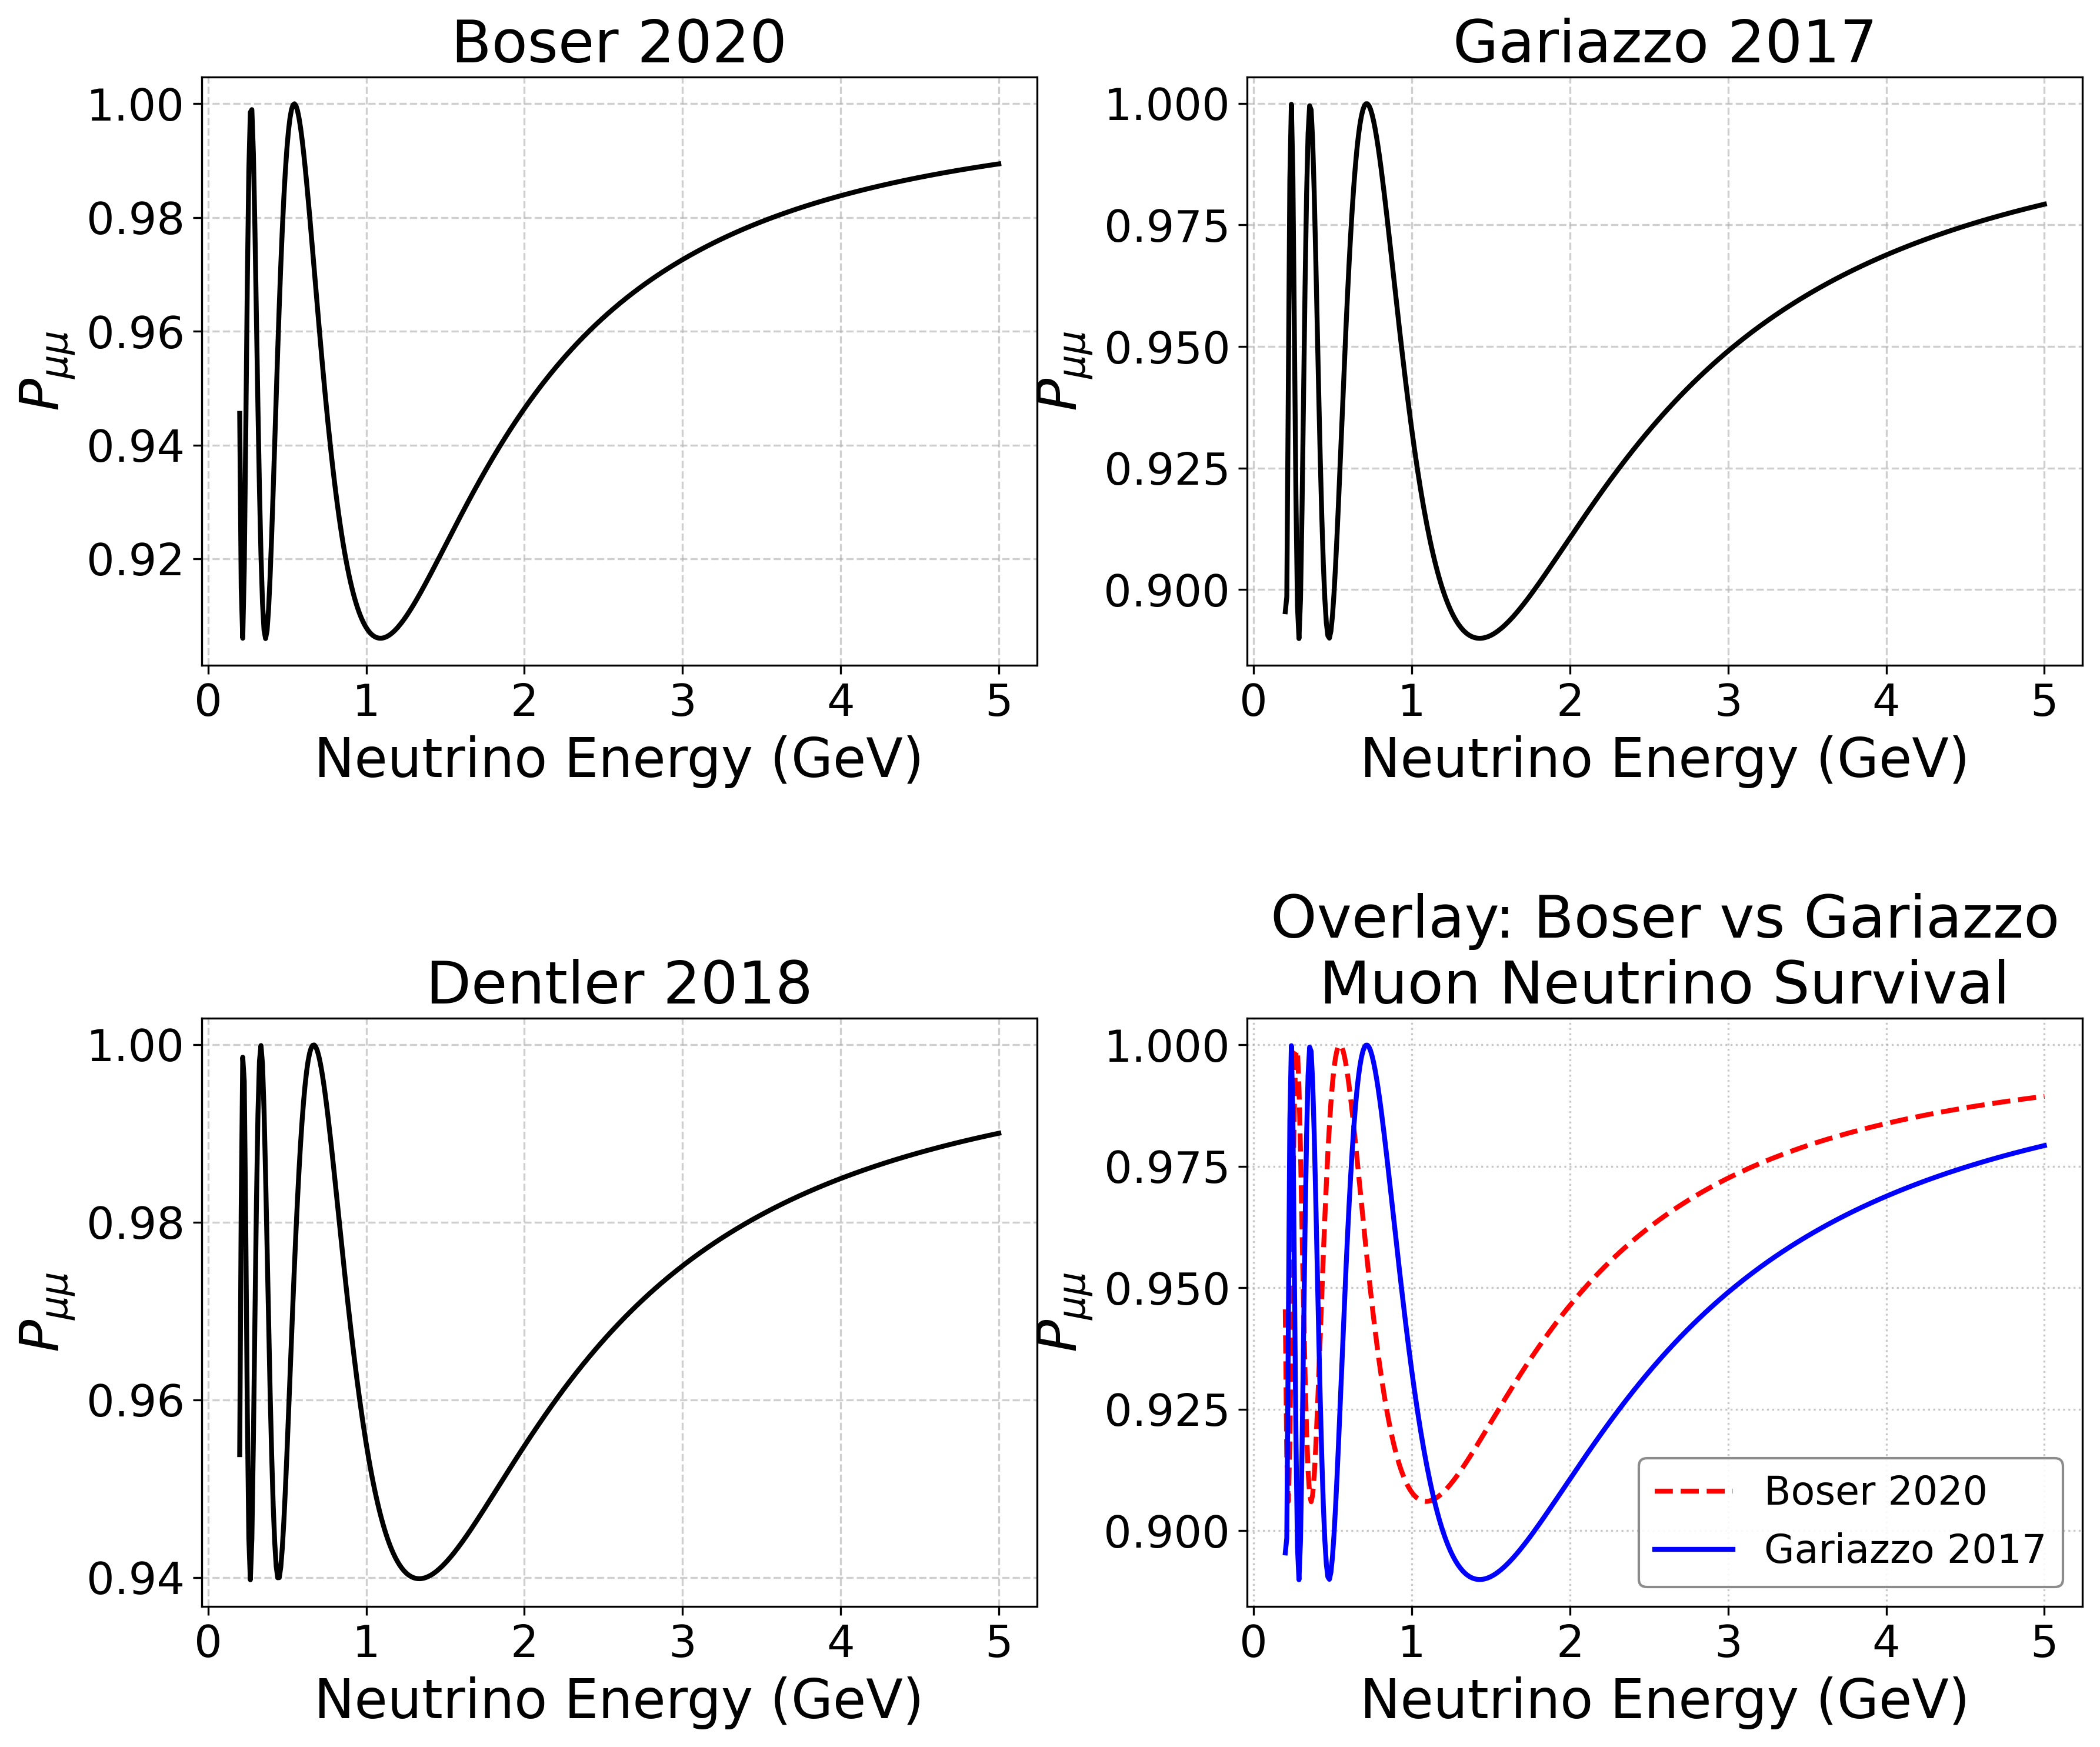

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# Plot styling
plot_kwargs = {
    "figsize": (12, 10),
    "dpi": 300
}

font_kwargs = {
    "xlabel": "Neutrino Energy (GeV)",
    "ylabel": r"$P_{\mu\mu}$",
    "xlabel_fontsize": 22,
    "ylabel_fontsize": 22,
    "title_fontsize": 24,
    "tick_fontsize": 18,
    "legend_fontsize": 16
}

# Create 2×2 subplot grid
fig, axs = plt.subplots(2, 2, **plot_kwargs)
axs = axs.flatten()

# Parameter sets
param_labels = list(param_sets.keys())

# First three plots
for i, label in enumerate(param_labels):
    theta_set, delta13, delta14, mass_sq = param_sets[label]
    Pmm = compute_Pmm(theta_set, delta13, delta14, mass_sq)

    axs[i].plot(energy_values / 1e9, Pmm, linewidth=2, color='black')
    axs[i].set_title(f"{label}", fontsize=font_kwargs["title_fontsize"])
    axs[i].set_xlabel(font_kwargs["xlabel"], fontsize=font_kwargs["xlabel_fontsize"])
    axs[i].set_ylabel(font_kwargs["ylabel"], fontsize=font_kwargs["ylabel_fontsize"])
    axs[i].tick_params(axis='both', labelsize=font_kwargs["tick_fontsize"])
    axs[i].grid(True, linestyle='--', alpha=0.6)

# Fourth subplot: Overlay Boser and Gariazzo
theta_boser, d13_b, d14_b, mass_boser = param_sets["Boser 2020"]
theta_gariazzo, d13_g, d14_g, mass_gariazzo = param_sets["Gariazzo 2017"]
Pmm_boser = compute_Pmm(theta_boser, d13_b, d14_b, mass_boser)
Pmm_gariazzo = compute_Pmm(theta_gariazzo, d13_g, d14_g, mass_gariazzo)

# Fourth subplot: Overlay Boser and Gariazzo (with improved visuals)
axs[3].plot(energy_values / 1e9, Pmm_boser, label="Boser 2020", color='red', linestyle='--', linewidth=2)
axs[3].plot(energy_values / 1e9, Pmm_gariazzo, label="Gariazzo 2017", color='blue', linestyle='-', linewidth=2)

axs[3].set_title("Overlay: Boser vs Gariazzo\nMuon Neutrino Survival", fontsize=font_kwargs["title_fontsize"])
axs[3].set_xlabel(font_kwargs["xlabel"], fontsize=font_kwargs["xlabel_fontsize"])
axs[3].set_ylabel(font_kwargs["ylabel"], fontsize=font_kwargs["ylabel_fontsize"])
axs[3].tick_params(axis='both', labelsize=font_kwargs["tick_fontsize"])
axs[3].grid(True, linestyle=':', alpha=0.7)

axs[3].legend(
    fontsize=font_kwargs["legend_fontsize"],
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    edgecolor='gray'
)



# Final layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
filename = "pmm_comparison_2x2_with_overlay.png"
plt.savefig(filename, bbox_inches='tight')
files.download(filename)
plt.show()


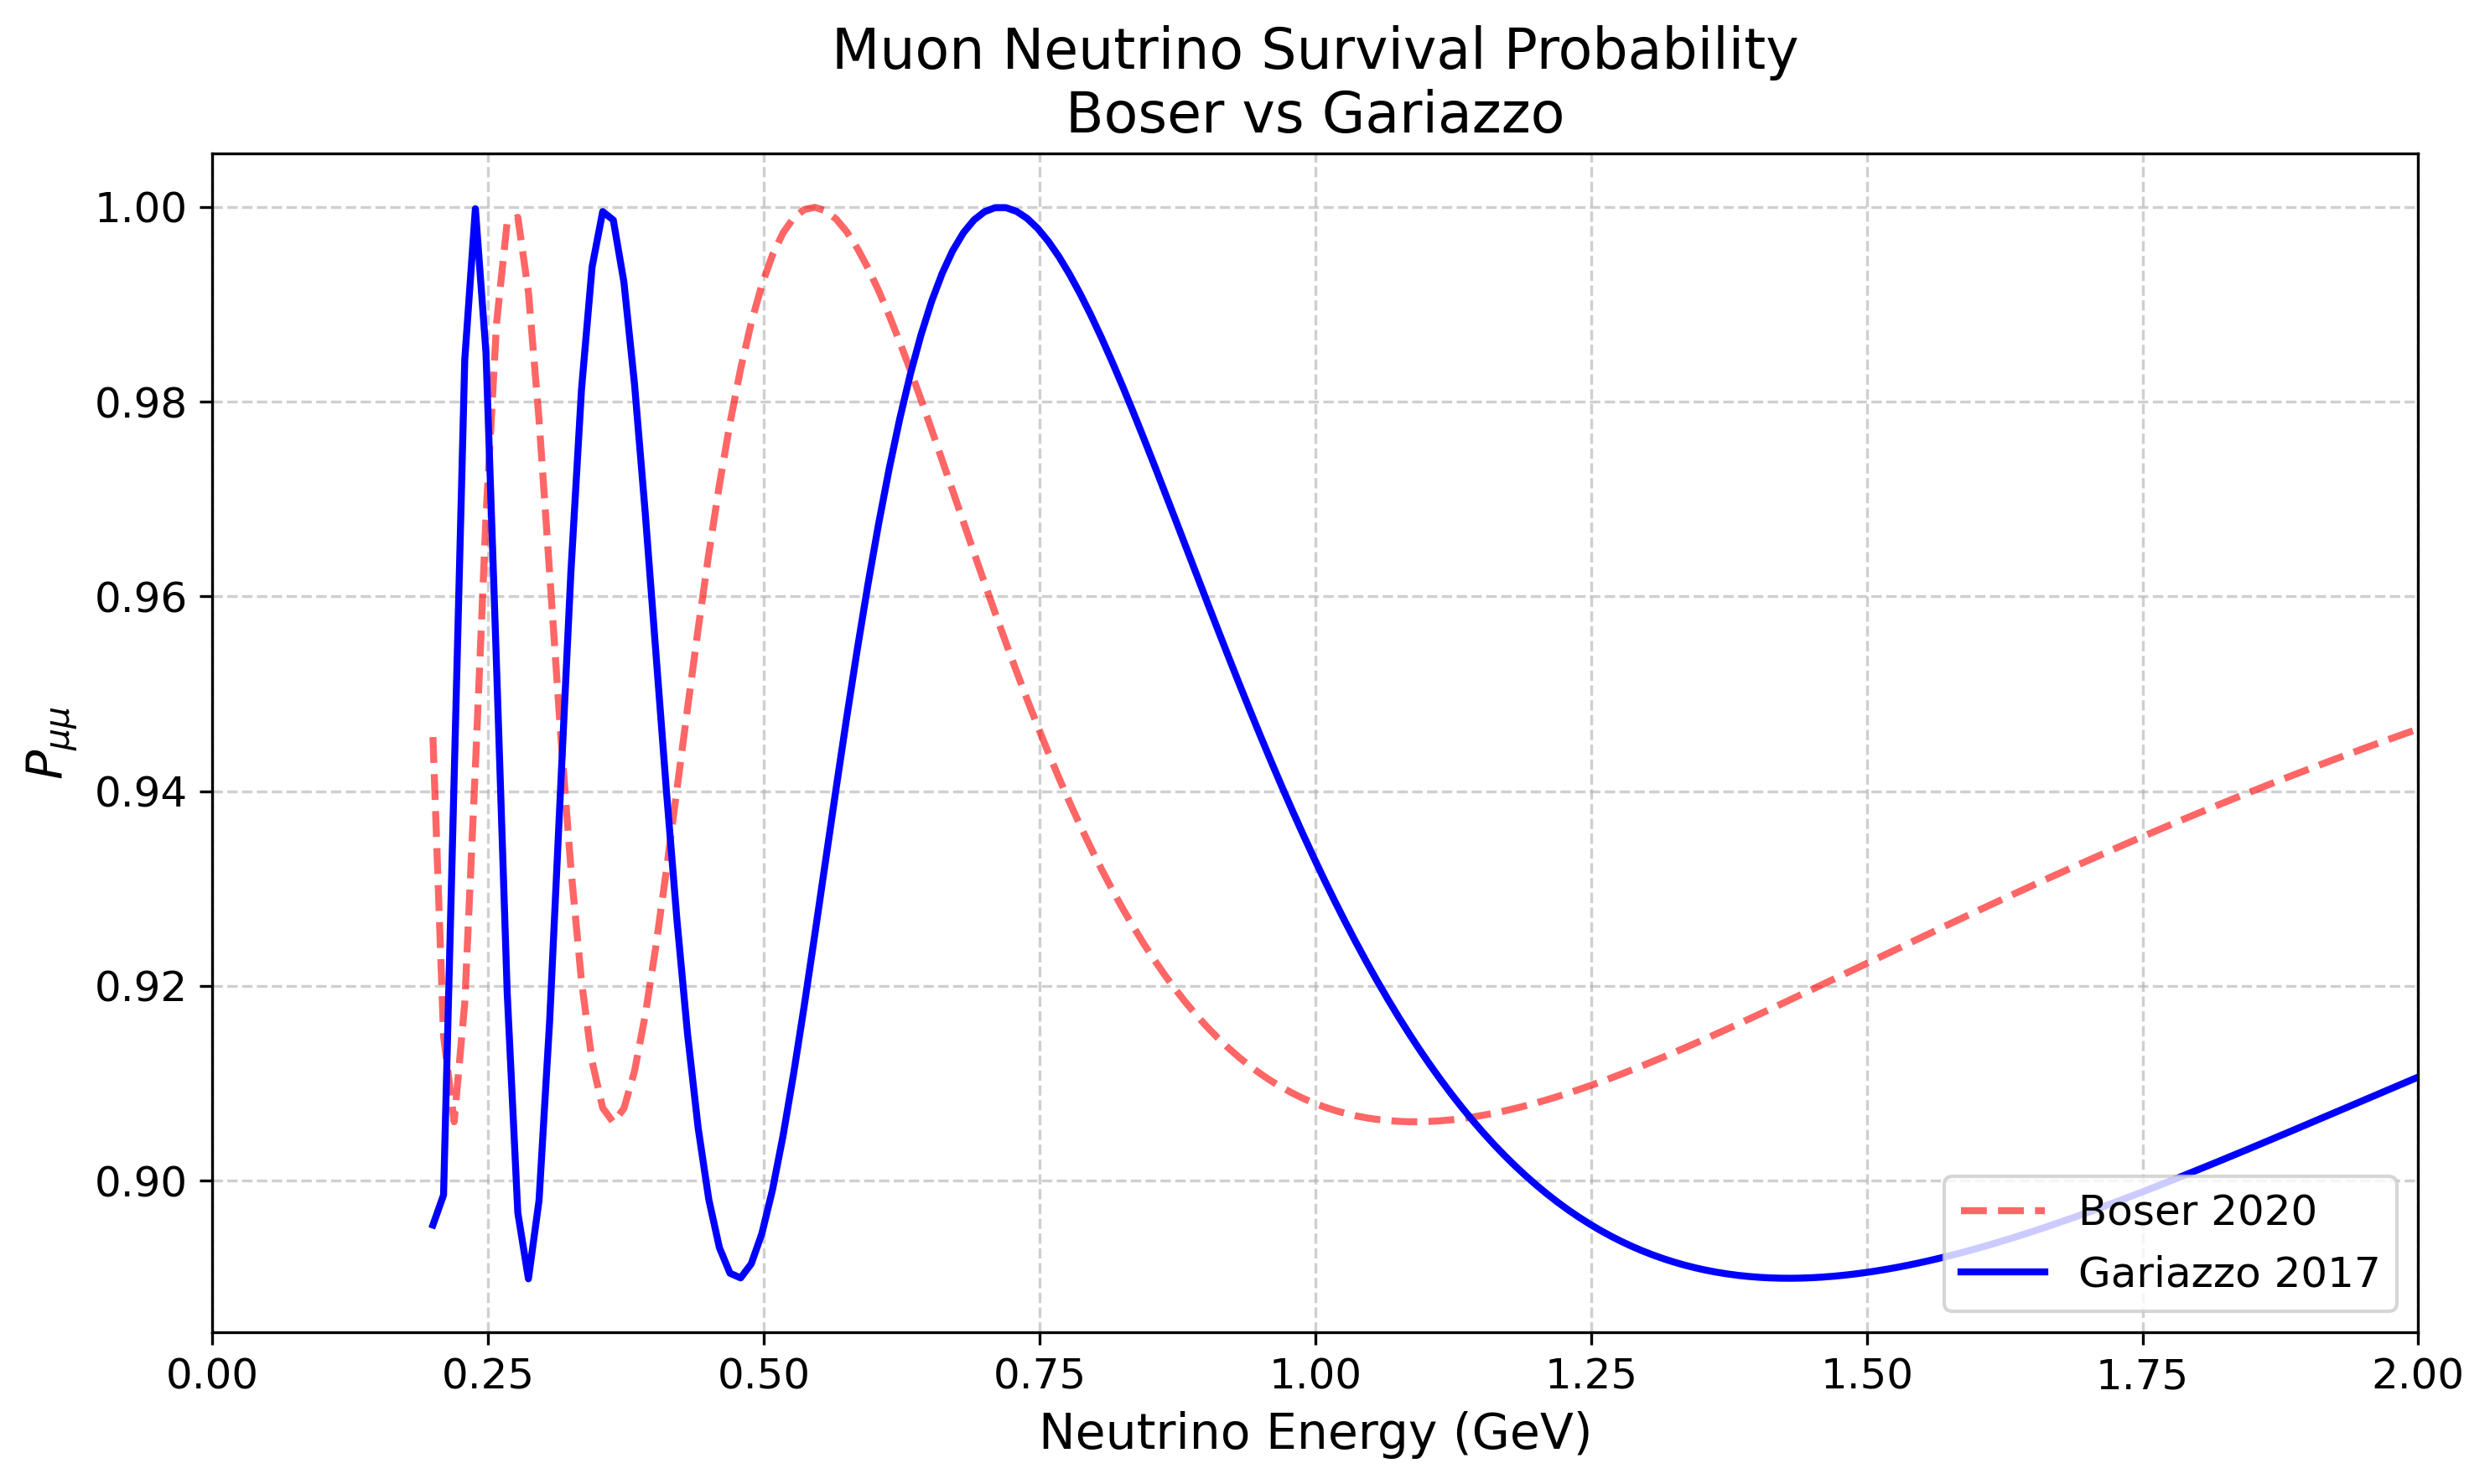

In [ ]:
# Plot
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(energy_values / 1e9, Pmm_boser, label="Boser 2020", color='red', linestyle='--', linewidth=2, alpha=0.6)
plt.plot(energy_values / 1e9, Pmm_gariazzo, label="Gariazzo 2017", color='blue', linewidth=2, alpha=1.0)

plt.xlabel("Neutrino Energy (GeV)", fontsize=14)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
plt.title("Muon Neutrino Survival Probability\nBoser vs Gariazzo", fontsize=16)
plt.legend(fontsize=12, loc='lower right')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(0,2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("zoom_in_overlay_pmm_boser_vs_gariazzo.png", bbox_inches='tight')
plt.show()


In [ ]:
files.download('zoom_in_overlay_pmm_boser_vs_gariazzo.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

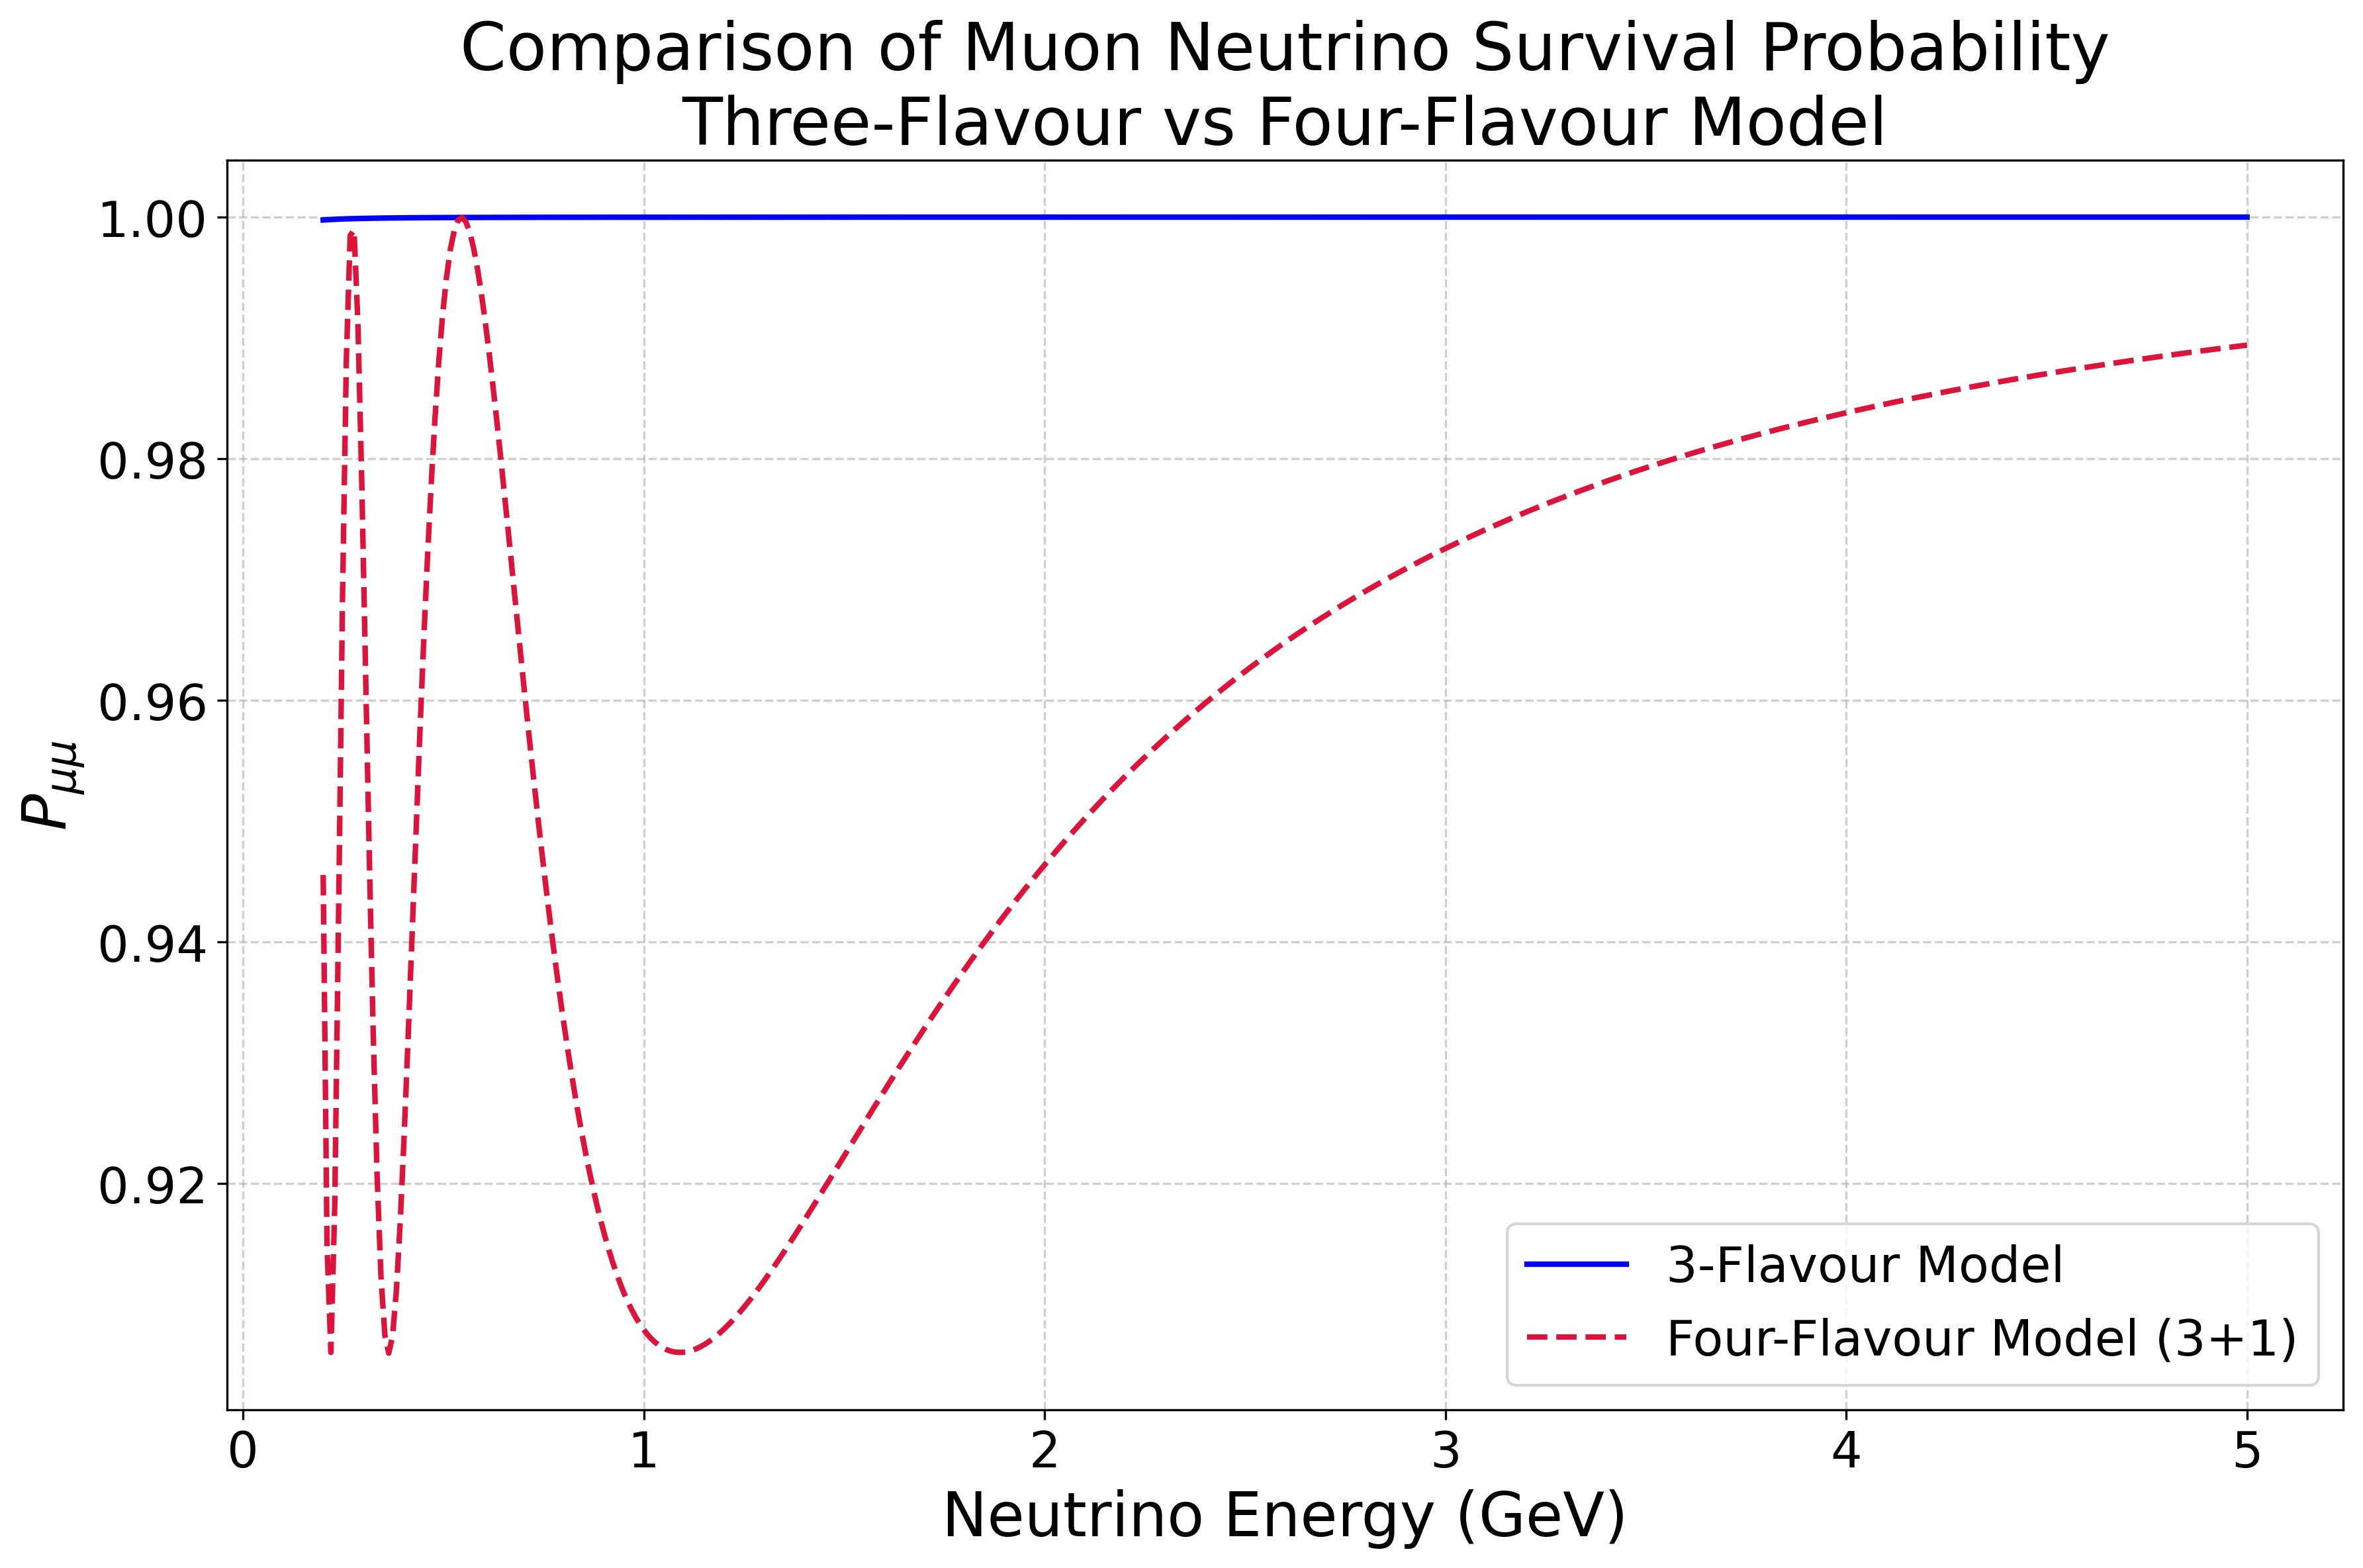

In [ ]:


# Crop to match energy range if needed:
energy_values = np.linspace(0.2e9, 5e9, 500)
energy_range = energy_values  # Ensure consistency with previous code

plt.figure(figsize=(12, 8), dpi=300)
plt.plot(energy_range / 1e9, prob_mm_vac, color='blue', linewidth=2, label=r"3-Flavour Model")
plt.plot(energy_range / 1e9, Pmm_4f, label="Four-Flavour Model (3+1)", color='crimson', linestyle='--', linewidth=2)

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=22)
plt.title("Comparison of Muon Neutrino Survival Probability\nThree-Flavour vs Four-Flavour Model", fontsize=24)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.savefig("pmm_3flavour_vs_4flavour.png", bbox_inches='tight')
plt.show()


In [ ]:
from google.colab import files
files.download('pmm_3flavour_vs_4flavour.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# original Oscillation Parameters
theta12, theta13, theta23 = np.radians([33.82, 8.61, 48.3])  # Standard angles
theta14, theta24, theta34 = np.radians([10.0, 5.0, 2.0])  # Sterile neutrino angles
delta13, delta14 = np.radians([0, 0])  # CP violation phases
D21, D31, D41 = [7.39e-5, 2.525e-3, 1.0]  # Mass squared differences in eV^2